# Statistics for Michel electron candidate

### Created by Shu, 202508---

<br />
<br />
<br />
<br />
<br />
<br />

## WVF Coincidence Explore:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


import os

# ------------------------------------------------------------
# 1️⃣ Define which dates to include
# ------------------------------------------------------------
dates = ["20251053"]  # ✅ modify as needed

coinNum = []     # waveform coincidence numbers
coinTrueE = []   # candidate energies
coinPDG = []     # candidate PDG codes


# ------------------------------------------------------------
# 2️⃣ Read waveform coincidence counts
# ------------------------------------------------------------
for d in dates:
    fname = f"./statResult_pds/print_wvfCoin_count{d}.txt"
    if not os.path.exists(fname):
        print(f"[WARN] File not found: {fname}")
        continue

    with open(fname, "r") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            parts = line.split(":")
            if len(parts) >= 2:
                try:
                    number = int(parts[1].strip())
                    coinNum.append(number)
                except ValueError:
                    print(f"[WARN] Could not convert '{parts[1].strip()}' in {fname} to an integer.")


# ------------------------------------------------------------
# 3️⃣ Read candidate energies
# ------------------------------------------------------------
for d in dates:
    fname = f"./statResult_pds/print_trueE{d}.txt"
    if not os.path.exists(fname):
        print(f"[WARN] File not found: {fname}")
        continue

    with open(fname, "r") as file:
        for line in file:
            value = line.strip()
            if value:
                try:
                    coinTrueE.append(float(value))
                except ValueError:
                    print(f"[WARN] Could not convert '{value}' in {fname} to float.")


# ------------------------------------------------------------
# 4️⃣ Read candidate PDG codes
# ------------------------------------------------------------
for d in dates:
    fname = f"./statResult_pds/print_truePDG{d}.txt"
    if not os.path.exists(fname):
        print(f"[WARN] File not found: {fname}")
        continue

    with open(fname, "r") as file:
        for line in file:
            value = line.strip()
            if value:
                try:
                    coinPDG.append(int(value))
                except ValueError:
                    print(f"[WARN] Could not convert '{value}' in {fname} to int.")


# ------------------------------------------------------------
# ✅ Summary
# ------------------------------------------------------------


print("Track candidates (TPC cut)  : 4431 (4431)")
print("Track candidates with NO wvf: 794 (794)")
print("Number of track candidates  :", len(coinNum))

#coinNum.extend([0] * (88+95))



print("\nLength of track coinTrueE: ", len(coinTrueE))
print("Length of track coinPDG  : ", len(coinPDG))


Track candidates (TPC cut)  : 4431 (4431)
Track candidates with NO wvf: 794 (794)
Number of track candidates  : 754

Length of track coinTrueE:  754
Length of track coinPDG  :  754


Purity of coinNum:  584 / 754 (77.45%)
Michel e:  85 / 584 (14.55%)
Michel p:  499 / 584 (85.45%)

Candidates with #opWvf>=4:  638 / 754 (84.62%)
Purity:  487 / 638 (76.33%)


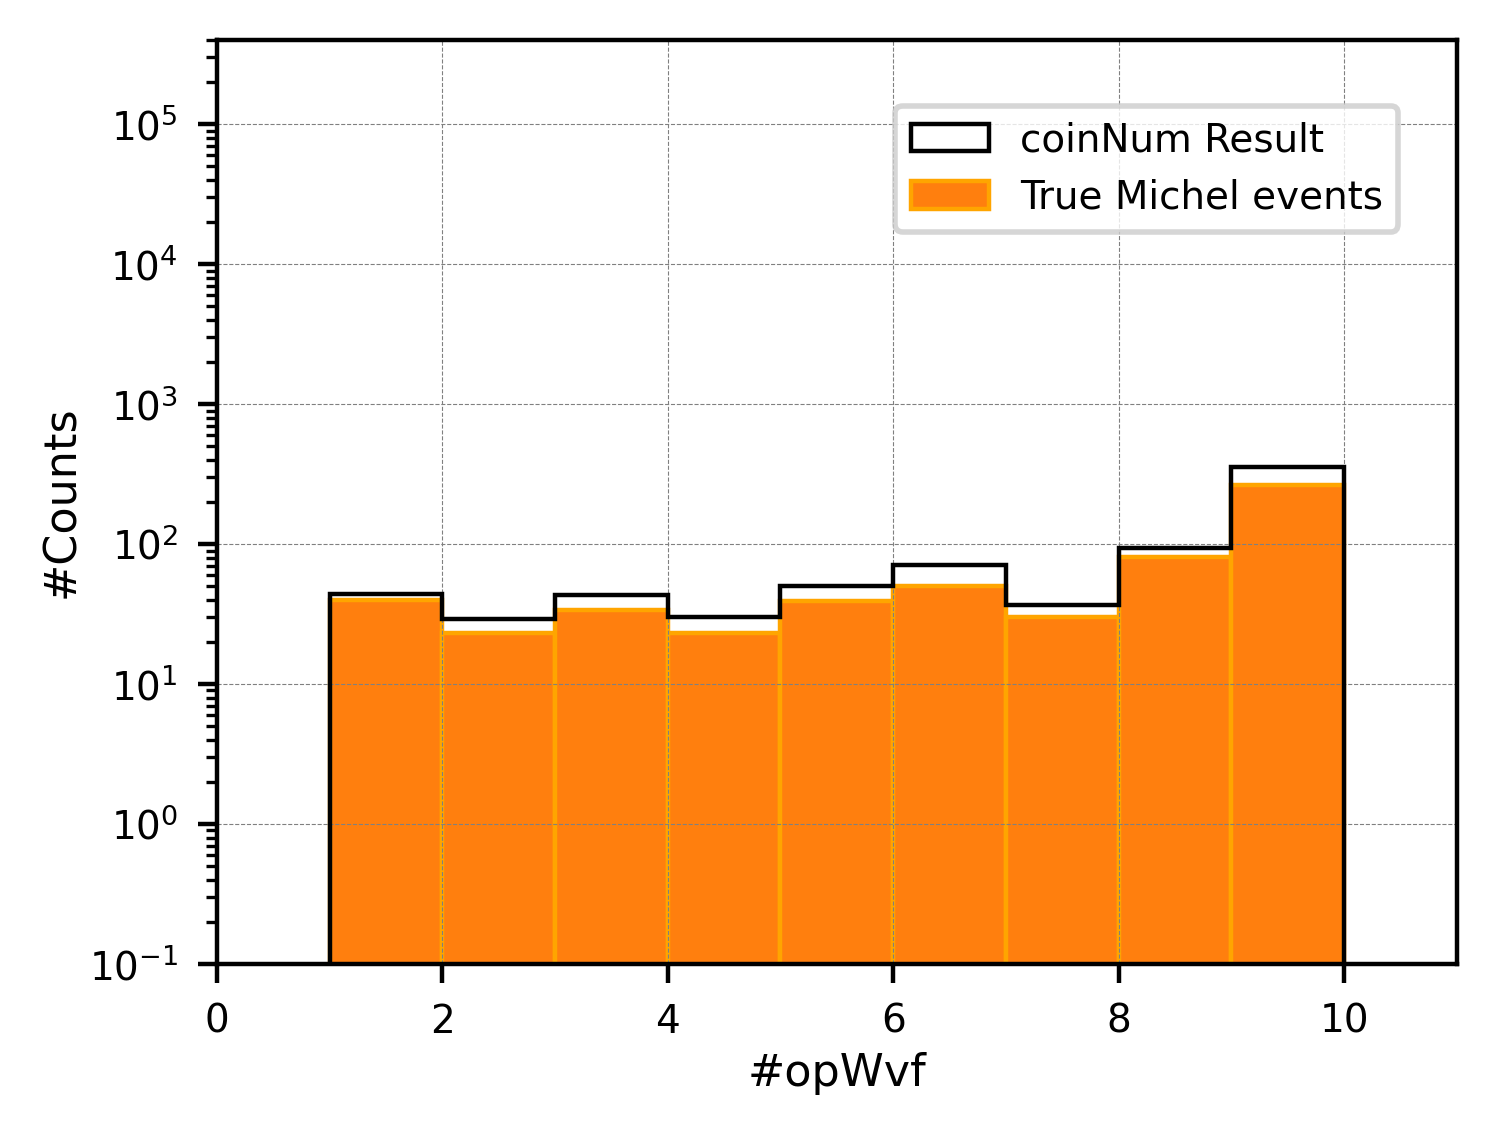

<Figure size 1600x1200 with 0 Axes>

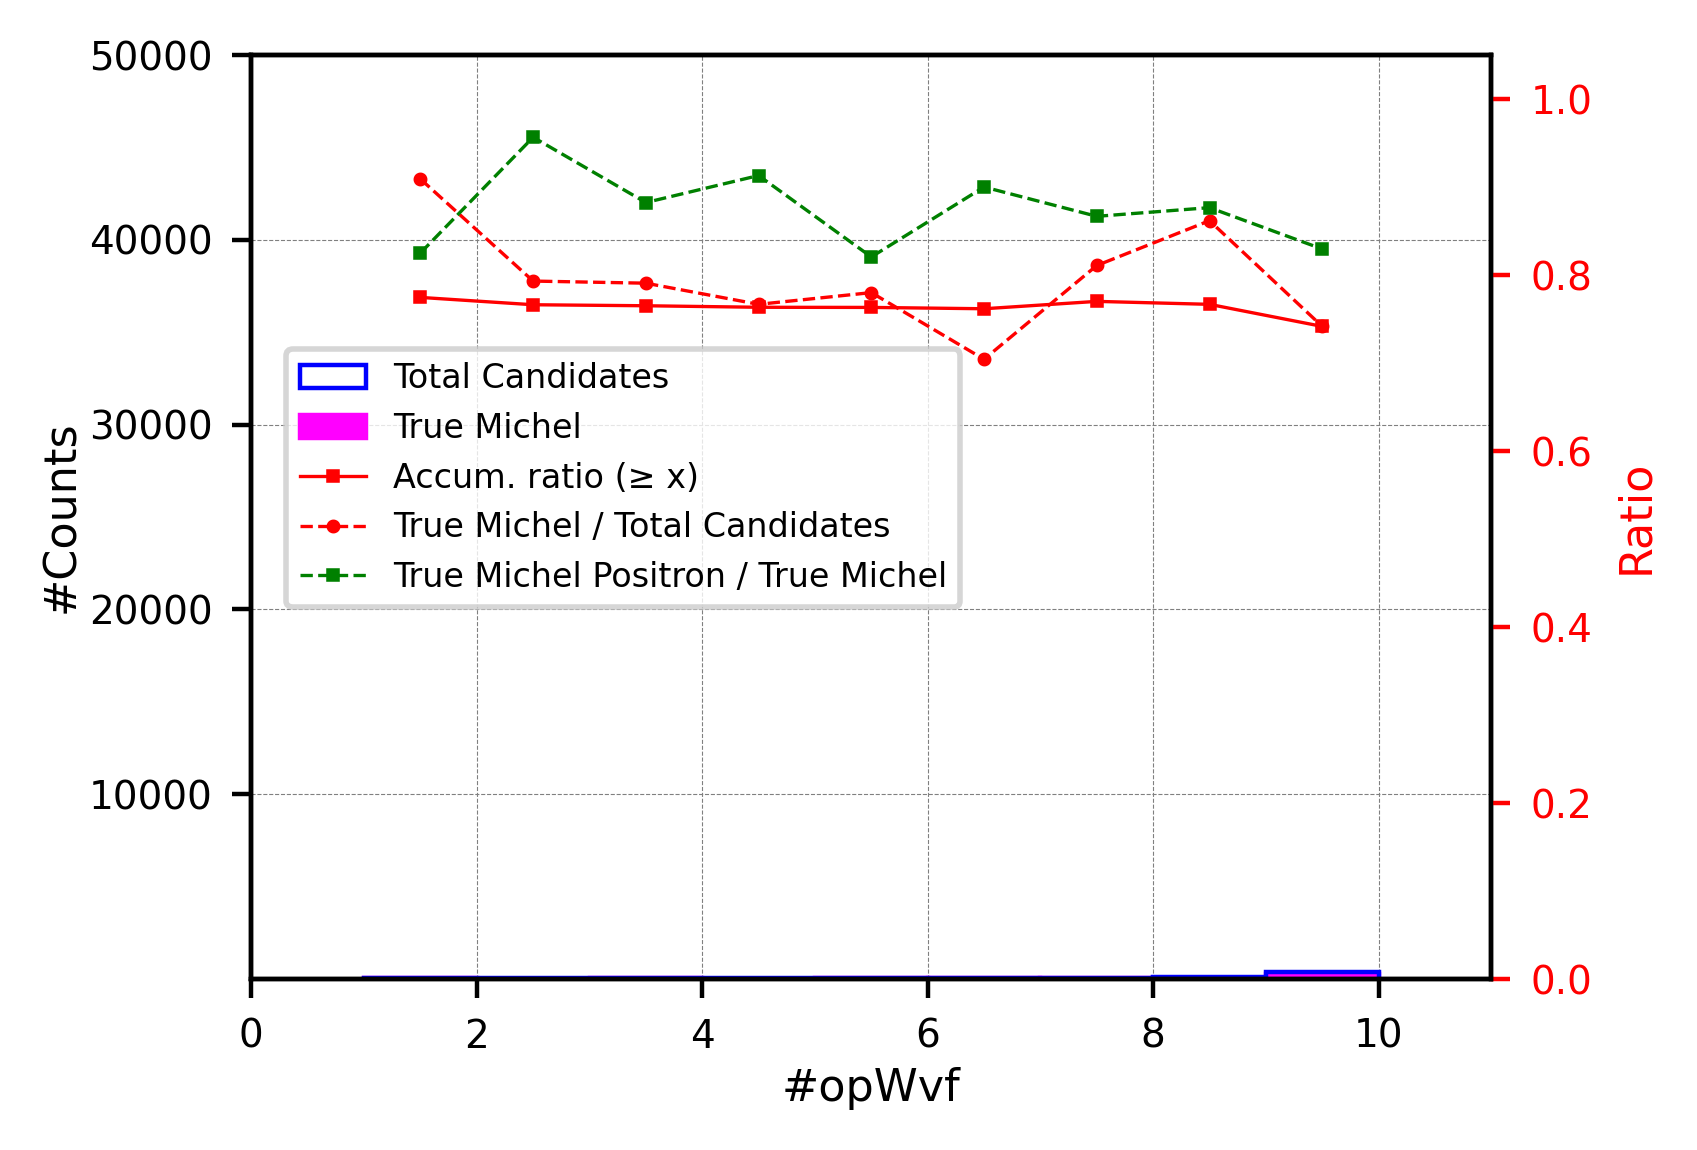

In [2]:

#Extract coinNum with trueE:===========================
coinNum_trueE = []
coinNum_trueE_e = [] #Michel electron
coinNum_trueE_p = [] #Michel positron
for i in range(0, len(coinTrueE)):
    count = coinNum[i]
    e = coinTrueE[i]
    pdg = coinPDG[i]

    if e > 0:
        coinNum_trueE.append(count)
        if pdg == 11:
            coinNum_trueE_e.append(count)
        if pdg == -11:
            coinNum_trueE_p.append(count)

print("Purity of coinNum: ", len(coinNum_trueE), "/", len(coinNum), "({:.2f}%)".format(len(coinNum_trueE)/len(coinNum)*100))
print("Michel e: ", len(coinNum_trueE_e), "/", len(coinNum_trueE), "({:.2f}%)".format(len(coinNum_trueE_e)/len(coinNum_trueE)*100))
print("Michel p: ", len(coinNum_trueE_p), "/", len(coinNum_trueE), "({:.2f}%)".format(len(coinNum_trueE_p)/len(coinNum_trueE)*100))





#Apply preliminary cut #opWvf >=4:=====================
coinNum_cut5 = []
coinNum_trueE_cut5 = []
for i in range(0, len(coinNum)):
    coin = coinNum[i]
    trueE = coinTrueE[i]

    if coin >=4:
        coinNum_cut5.append(coin)
    
        if trueE > 0:
            coinNum_trueE_cut5.append(trueE)

print("\nCandidates with #opWvf>=4: ", len(coinNum_cut5), "/", len(coinNum), "({:.2f}%)".format(len(coinNum_cut5)/len(coinNum)*100))
print("Purity: ", len(coinNum_trueE_cut5), "/", len(coinNum_cut5), "({:.2f}%)".format(len(coinNum_trueE_cut5)/len(coinNum_cut5)*100))




# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 11
bins = np.arange(range_min, range_max + bin_width, bin_width)

#plt.plot([5, 5], [0, 1200], color="black", linewidth=1.5, linestyle='--')

plt.hist(coinNum, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label='coinNum Result')
plt.hist(coinNum_trueE, bins=bins, range=(range_min, range_max), edgecolor='orange', 
         histtype='bar', linewidth=0.8, label="True Michel events")



plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.xlim(0, 11)
#plt.ylim(0, 50)
plt.xlabel('#opWvf', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 400000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 








#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 1
range_max = 10
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(coinNum, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(coinNum_trueE, bins=bins, range=(range_min, range_max))
hist_trueP, _ = np.histogram(coinNum_trueE_p, bins=bins, range=(range_min, range_max))#True positron

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', color='magenta', histtype='bar', 
         linewidth=0.8, label="True Michel")
#ax1.hist(bin_centers, bins=bins, weights=hist_trueP, edgecolor='green', color='green', histtype='bar', 
#         linewidth=0.8, label="True Michel Positron")


#ax1.plot([4, 4], [0, 1400], color="blue", linewidth=0.8, linestyle='-')


ax1.set_xlim(0, 11)
ax1.set_xlabel('#opWvf', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.set_ylim(0.1, 50000)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero

ratio2 = np.divide(hist_trueP, hist_true, out=np.zeros_like(hist_trueP, dtype=float), where=hist_total!=0)  # Avoid division by zero

# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')


ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', 
         linewidth=0.6, label="True Michel / Total Candidates")

ax2.plot(bin_centers, ratio2, color='green', marker='s', markersize=1.5, linestyle='--', 
         linewidth=0.6, label="True Michel Positron / True Michel")



ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.set_ylim(0.0, 1.05)

ax2.tick_params(axis='y', labelsize=7, colors='red')



# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.3, 0.7),
           fontsize=9, ncol=1, prop={'size': 6})



plt.show()



<br />
<br />
<br />
<br />
<br />
<br />

## Process WVF:
### After TPC cuts & (#opWvf >= 4) (This can be taken as "PDS Cut 1")

In [4]:
from dataclasses import dataclass
from typing import Optional
import matplotlib.pyplot as plt
import numpy as np
import re
from mpl_toolkits.mplot3d import Axes3D



# ------------------- Dataclass -------------------
@dataclass
class PdsEvent:
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    third_time: Optional[int] = None             # NEW
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    third_intensity: Optional[float] = None      # NEW
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    energy: Optional[float] = None
    lifetime: Optional[float] = None
    pdg: Optional[int] = None
    eventID: Optional[int] = None
    trackID: Optional[int] = None
    date: Optional[int] = None
    # muon
    mu_leftTurn: Optional[int] = None
    mu_rightTurn: Optional[int] = None
    mu_leftHeight: Optional[float] = None
    mu_rightHeight: Optional[float] = None
    # michel
    mi_leftTurn: Optional[int] = None
    mi_rightTurn: Optional[int] = None
    mi_leftHeight: Optional[float] = None
    mi_rightHeight: Optional[float] = None
    # third peak
    th_leftTurn: Optional[int] = None            # NEW
    th_rightTurn: Optional[int] = None           # NEW
    th_leftHeight: Optional[float] = None        # NEW
    th_rightHeight: Optional[float] = None       # NEW
    # Michel-level attributes
    michel_score: Optional[float] = None         # ✅ NEW
    michel_hits: Optional[int] = None            # ✅ NEW



# ------------------- Helpers -------------------
def parse_event_track(path_str: str):
    """Extract eventID and trackID from a file path string."""
    m = re.search(r"event(\d+)_trackID(\d+)", path_str)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None



def read_total_files(files, dates, kind="muon"):
    """
    Read *_total_xxx.txt files.
    Each line: path: t, I, leftTurn, leftHeight, rightTurn, rightHeight
    """
    records = []
    for fname, date in zip(files, dates):
        try:
            with open(fname, "r") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split(":")
                    if len(parts) < 2:
                        continue

                    path_part = parts[0].strip()
                    values = [v.strip() for v in parts[1].split(",")]
                    if len(values) < 6:
                        print(f"[WARN] Malformed line in {fname}: {line}")
                        continue

                    try:
                        time_val = int(values[0])
                        inten_val = float(values[1])
                        left_turn = int(values[2])
                        left_h = float(values[3])
                        right_turn = int(values[4])
                        right_h = float(values[5])
                    except ValueError:
                        print(f"[WARN] Could not parse numbers in {line}")
                        continue

                    evID, trID = parse_event_track(path_part)
                    rec = {"eventID": evID, "trackID": trID, "date": int(date)}

                    if kind == "muon":
                        rec.update({
                            "muon_time": time_val,
                            "muon_intensity": inten_val,
                            "mu_leftTurn": left_turn,
                            "mu_leftHeight": left_h,
                            "mu_rightTurn": right_turn,
                            "mu_rightHeight": right_h
                        })
                    elif kind == "michel":
                        rec.update({
                            "michel_time": time_val,
                            "michel_intensity": inten_val,
                            "mi_leftTurn": left_turn,
                            "mi_leftHeight": left_h,
                            "mi_rightTurn": right_turn,
                            "mi_rightHeight": right_h
                        })
                    elif kind == "third":
                        rec.update({
                            "third_time": time_val,
                            "third_intensity": inten_val,
                            "th_leftTurn": left_turn,
                            "th_leftHeight": left_h,
                            "th_rightTurn": right_turn,
                            "th_rightHeight": right_h
                        })

                    records.append(rec)
        except FileNotFoundError:
            print(f"File not found: {fname}")
    return records




def read_plain_files(files, cast_type=float):
    """Read one or more plain text files with one number per line and return concatenated values."""
    values = []
    for fname in files:
        try:
            with open(fname, "r") as file:
                for line in file:
                    value = line.strip()
                    if value:
                        try:
                            values.append(cast_type(value))
                        except ValueError:
                            print(f"Could not convert {value} in {fname}")
        except FileNotFoundError:
            print(f"File not found: {fname}")
    return values



# ------------------- Load data -------------------
dates = ["20251053"]

muon_files   = [f"./statResult_pds/muon_total_{d}.txt" for d in dates]
michel_files = [f"./statResult_pds/michel_total_{d}.txt" for d in dates]
third_files  = [f"./statResult_pds/third_total_{d}.txt" for d in dates]

muon_records   = read_total_files(muon_files, dates, kind="muon")
michel_records = read_total_files(michel_files, dates, kind="michel")
third_records  = read_total_files(third_files, dates, kind="third")

# --- plain text attributes ---
posX     = read_plain_files([f"./statResult_pds/posX_extract_{d}.txt" for d in dates])
posY     = read_plain_files([f"./statResult_pds/posY_extract_{d}.txt" for d in dates])
posZ     = read_plain_files([f"./statResult_pds/posZ_extract_{d}.txt" for d in dates])
energy   = read_plain_files([f"./statResult_pds/energy_extract_{d}.txt" for d in dates])
lifetime = read_plain_files([f"./statResult_pds/lifetime_extract_{d}.txt" for d in dates])
pdg      = read_plain_files([f"./statResult_pds/pdg_extract_{d}.txt" for d in dates], cast_type=int)
miScore  = read_plain_files([f"./statResult_pds/michelScore_extract_{d}.txt" for d in dates])
miHits   = read_plain_files([f"./statResult_pds/michelHits_extract_{d}.txt" for d in dates], cast_type=int)



# ------------------- Build dataset -------------------
events_veryInitial = []
n_events = min(
    len(muon_records), len(michel_records), len(third_records),
    len(posX), len(posY), len(posZ),
    len(energy), len(lifetime), len(pdg),
    len(miScore), len(miHits)
)

for i in range(n_events):
    rec_mu = muon_records[i]
    rec_mi = michel_records[i]
    rec_th = third_records[i]

    ev = PdsEvent(
        eventID=rec_mu.get("eventID", rec_mi.get("eventID", rec_th.get("eventID"))),
        trackID=rec_mu.get("trackID", rec_mi.get("trackID", rec_th.get("trackID"))),
        date=rec_mu.get("date", rec_mi.get("date", rec_th.get("date"))),

        # muon
        muon_time=rec_mu.get("muon_time"),
        muon_intensity=rec_mu.get("muon_intensity"),
        mu_leftTurn=rec_mu.get("mu_leftTurn"),
        mu_leftHeight=rec_mu.get("mu_leftHeight"),
        mu_rightTurn=rec_mu.get("mu_rightTurn"),
        mu_rightHeight=rec_mu.get("mu_rightHeight"),

        # michel
        michel_time=rec_mi.get("michel_time"),
        michel_intensity=rec_mi.get("michel_intensity"),
        mi_leftTurn=rec_mi.get("mi_leftTurn"),
        mi_leftHeight=rec_mi.get("mi_leftHeight"),
        mi_rightTurn=rec_mi.get("mi_rightTurn"),
        mi_rightHeight=rec_mi.get("mi_rightHeight"),
        michel_score=miScore[i],
        michel_hits=miHits[i],

        # third
        third_time=rec_th.get("third_time"),
        third_intensity=rec_th.get("third_intensity"),
        th_leftTurn=rec_th.get("th_leftTurn"),
        th_leftHeight=rec_th.get("th_leftHeight"),
        th_rightTurn=rec_th.get("th_rightTurn"),
        th_rightHeight=rec_th.get("th_rightHeight"),

        # physical properties
        posX=posX[i], posY=posY[i], posZ=posZ[i],
        energy=energy[i], lifetime=lifetime[i], pdg=pdg[i]
    )
    events_veryInitial.append(ev)

print("Very initial dataset:", len(events_veryInitial))

example = events_veryInitial[0]
print("\nExample Event (index 0):")
for field, value in vars(example).items():
    print(f"  {field:20s}: {value}")









#Apply cuts on peak intensities-----------------------------
events_reco_initial = []
events_true_initial = []

for ev in events_veryInitial:
    muIntensity = ev.muon_intensity
    miIntensity = ev.michel_intensity
    e = ev.energy

    if muIntensity > 0.3  and miIntensity > -0.1:#mu & mi are cuts in following block already!
        events_reco_initial.append(ev)

        if e > 0:
            events_true_initial.append(ev)

print("\nDataset after initial intensity-cut----------------------")
print("Michel initial dataset   : ", len(events_reco_initial))
print("Michel purity (true/reco): ", len(events_true_initial), "/ ", len(events_reco_initial), 
      "({:.2f}%)".format(len(events_true_initial)/len(events_reco_initial)*100)) 







Very initial dataset: 638

Example Event (index 0):
  muon_time           : 128
  michel_time         : 201
  third_time          : 323
  muon_intensity      : 21.8107
  michel_intensity    : 0.925979
  third_intensity     : 0.630727
  posX                : 93.523
  posY                : 36.9965
  posZ                : 288.803
  energy              : -1.0
  lifetime            : -1.0
  pdg                 : 0
  eventID             : 1003
  trackID             : 4
  date                : 20251053
  mu_leftTurn         : 103
  mu_rightTurn        : 153
  mu_leftHeight       : 29.8363
  mu_rightHeight      : 21.8107
  mi_leftTurn         : 190
  mi_rightTurn        : 230
  mi_leftHeight       : 0.925979
  mi_rightHeight      : 1.83275
  th_leftTurn         : 300
  th_rightTurn        : 343
  th_leftHeight       : 0.886592
  th_rightHeight      : 0.630727
  michel_score        : 0.570054
  michel_hits         : 27

Dataset after initial intensity-cut----------------------
Michel initial da

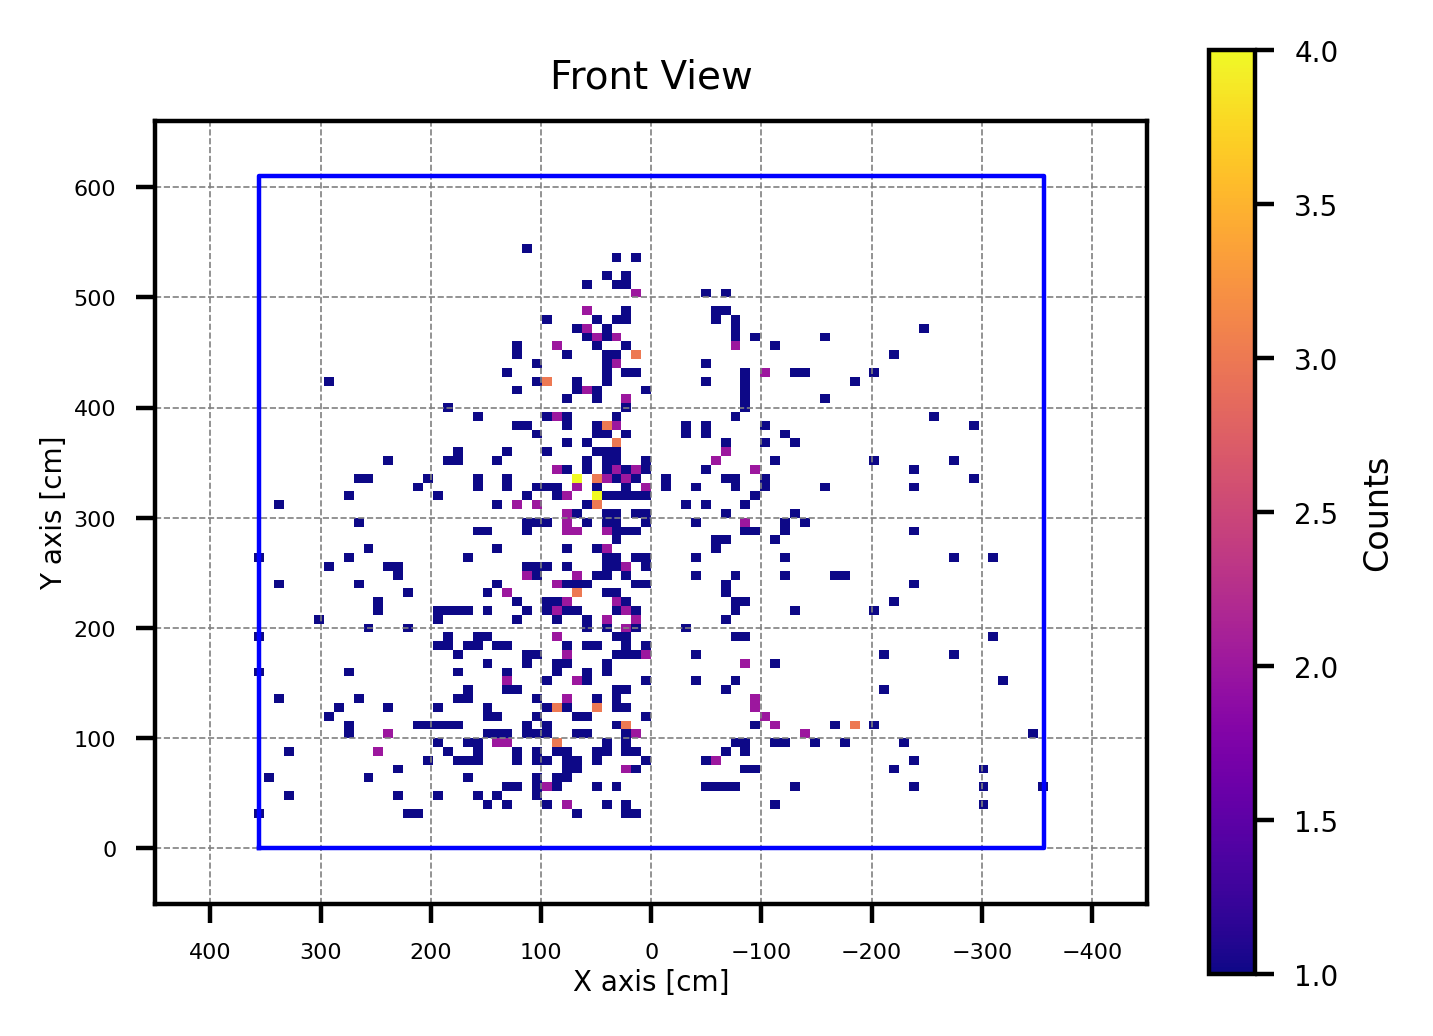

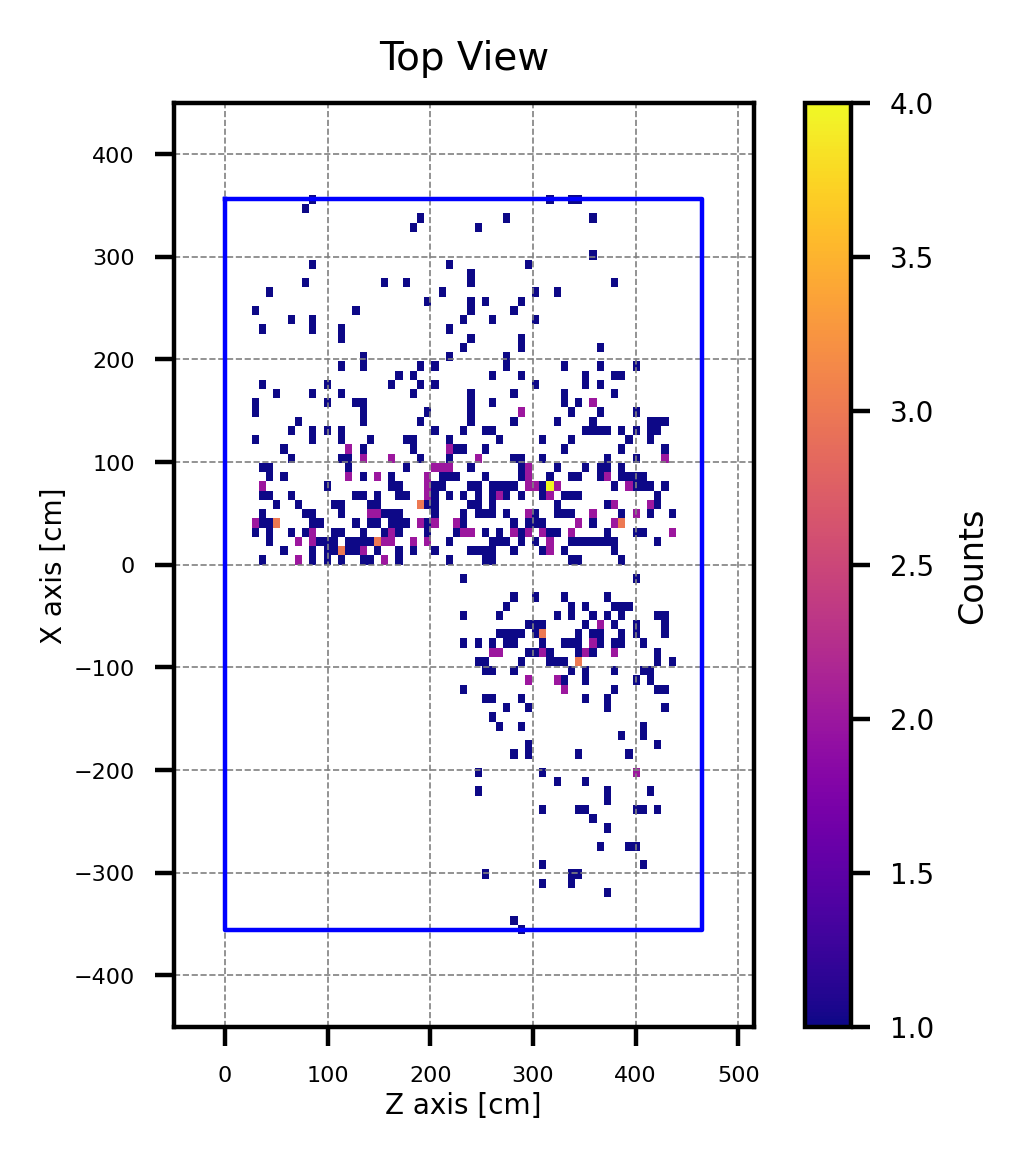


Decay points distribution (TPC & #opWvf cuts): 
# of X < 0 :  160 (25.08%)
# of X >= 0:  478 (74.92%)

Michel purity:  487 /  638 (76.33%)

Bin Center | Final / Initial Ratio
-------------------------------
   -355.0 | 0.000
   -345.0 | 0.000
   -335.0 |   NaN
   -325.0 | 1.000
   -315.0 | 1.000
   -305.0 | 0.750
   -295.0 | 0.500
   -285.0 |   NaN
   -275.0 | 0.667
   -265.0 |   NaN
   -255.0 | 0.000
   -245.0 | 0.500
   -235.0 | 0.800
   -225.0 | 0.500
   -215.0 | 0.500
   -205.0 | 1.000
   -195.0 | 1.000
   -185.0 | 0.500
   -175.0 | 0.000
   -165.0 | 0.000
   -155.0 | 1.000
   -145.0 | 1.000
   -135.0 | 0.375
   -125.0 | 0.833
   -115.0 | 0.667
   -105.0 | 0.750
    -95.0 | 1.000
    -85.0 | 0.667
    -75.0 | 0.938
    -65.0 | 0.750
    -55.0 | 0.500
    -45.0 | 0.750
    -35.0 | 1.000
    -25.0 | 1.000
    -15.0 | 0.500
     -5.0 |   NaN
      5.0 | 0.850
     15.0 | 0.833
     25.0 | 0.814
     35.0 | 0.805
     45.0 | 0.842
     55.0 | 0.840
     65.0 | 0.828
     75.0 | 0.706


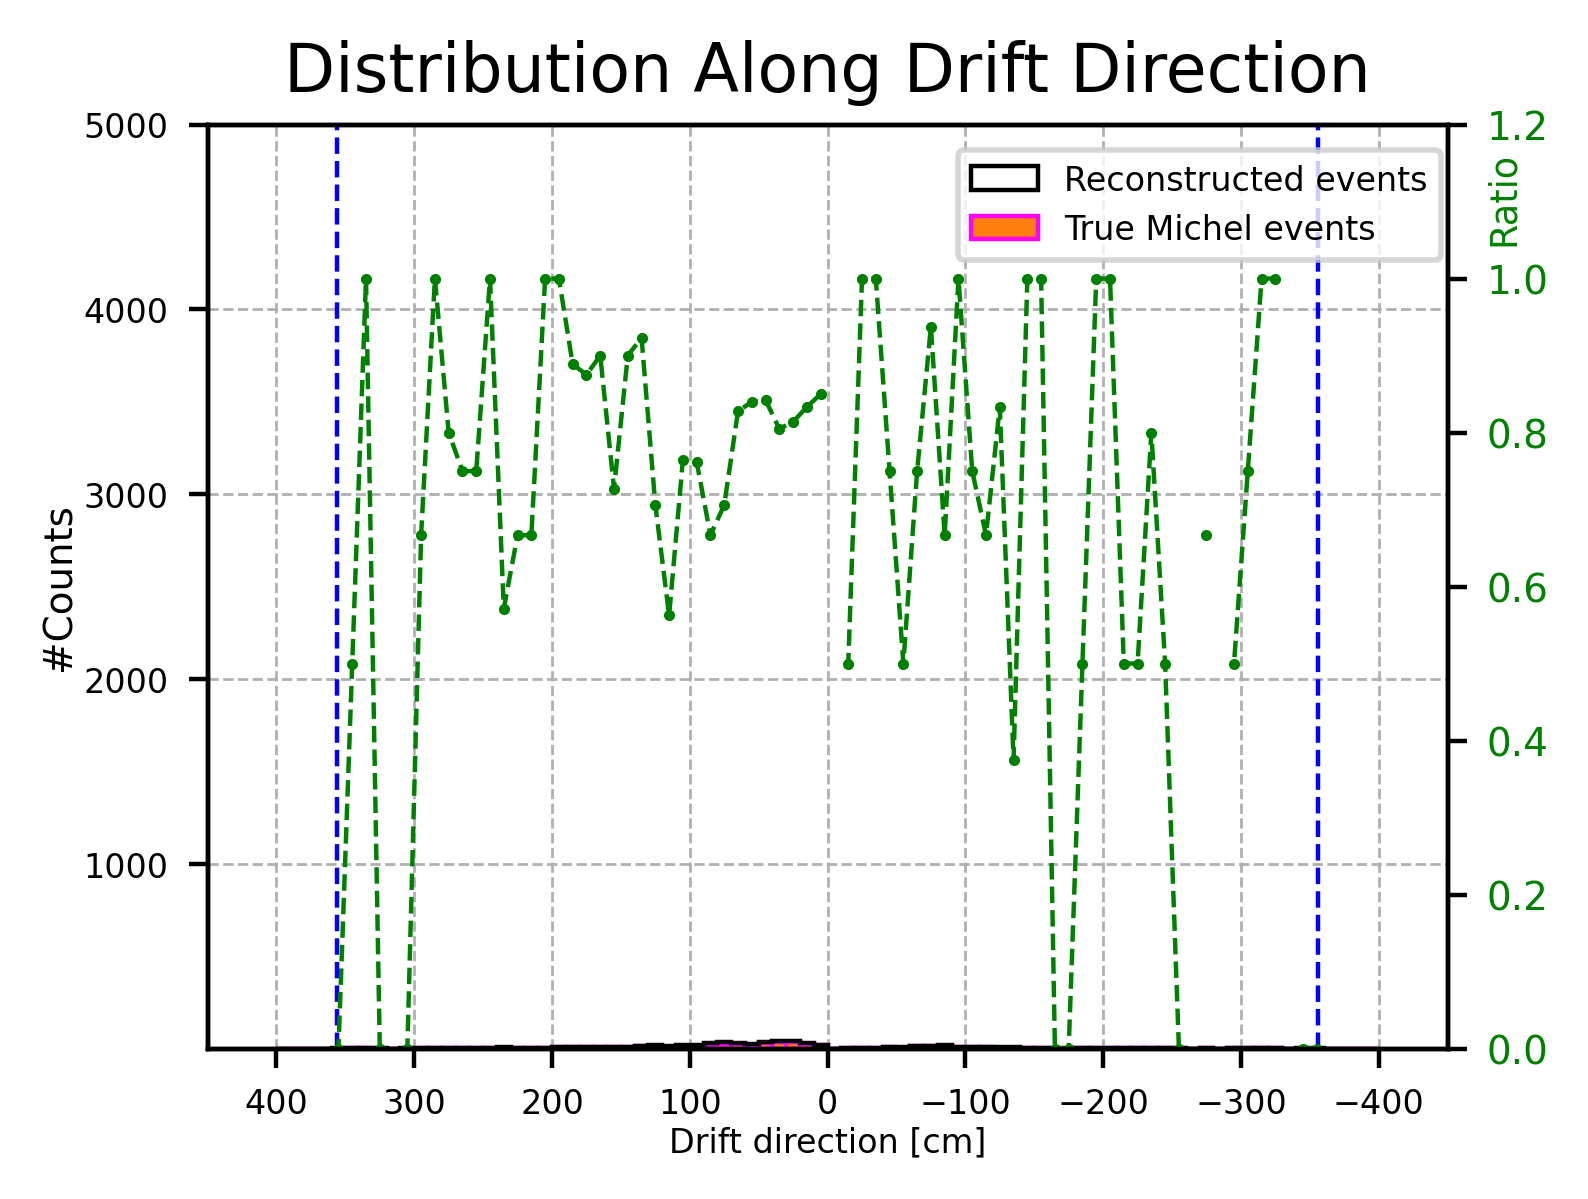

In [5]:
posX = [ev.posX for ev in events_reco_initial]
posY = [ev.posY for ev in events_reco_initial]
posZ = [ev.posZ for ev in events_reco_initial]

posX_true = [ev.posX for ev in events_true_initial]




#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465


#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posX, posY, bins=(100, 100), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posZ, posX, bins=(100, 100), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()








#Decay points distribution:==================================================================
print("\nDecay points distribution (TPC & #opWvf cuts): ")

posX = np.array(posX)
neg_X = np.sum(posX < 0)
pos_X = np.sum(posX >= 0)
print("# of X < 0 : ", neg_X, "({:.2f}%)".format(neg_X/len(posX)*100))
print("# of X >= 0: ", pos_X, "({:.2f}%)".format(pos_X/len(posX)*100))

print("\nMichel purity: ", len(events_true_initial), "/ ", len(events_reco_initial), 
      "({:.2f}%)".format(len(events_true_initial)/len(events_reco_initial)*100))         



# Plotting the histogram (X distribution)---------------
fig, ax1 = plt.subplots(figsize=(4, 3), dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# --- Histogram counts ---
n_initial, _ = np.histogram(posX, bins=bins)
n_final, _ = np.histogram(posX_true, bins=bins)

# --- Ratio Calculation (only for [-360, 360]) ---
ratio = []
ratio_centers = []

print("\nBin Center | Final / Initial Ratio")
print("-------------------------------")
for center, ni, nf in zip(bin_centers, n_initial, n_final):
    if -360 <= center <= 360:
        r = nf / ni if ni > 0 else np.nan
        ratio.append(r)
        ratio_centers.append(center)
        if ni > 0:
            print(f"{center:9.1f} | {r:.3f}")
        else:
            print(f"{center:9.1f} |   NaN")


# Filter out NaN values for min/max calculation
valid_ratios = [r for r in ratio if not np.isnan(r)]

if valid_ratios:
    print("\nMaximum ratio: {:.3f}".format(np.max(valid_ratios)))
    print("Minimum ratio: {:.3f}".format(np.min(valid_ratios)))
else:
    print("\nNo valid ratios to compute min/max.")

#APA planes---
plt.plot([-356, -356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')

# Plot histograms
ax1.hist(bins[:-1], bins=bins, weights=n_initial, edgecolor='black',
         histtype='step', linewidth=0.8, label='Reconstructed events')
ax1.hist(bins[:-1], bins=bins, weights=n_final, edgecolor='magenta',
         histtype='bar', linewidth=0.8, label='True Michel events')

ax1.set_ylabel('Counts')
ax1.grid(True, linestyle='--', linewidth=0.5)
ax1.legend(loc='upper center', bbox_to_anchor=(0.8, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})
ax1.set_xlim(-450, 450)
ax1.set_ylim(0.1, 5000)
ax1.set_xlabel('Drift direction [cm]', labelpad=1, fontsize=6)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=7)
ax1.invert_xaxis()
#ax1.set_yscale('log')
ax1.tick_params(labelsize=6)

# Secondary y-axis for ratio
ax2 = ax1.twinx()

ax2.plot(ratio_centers, ratio, 'o--', color='green', markersize=1, linewidth=0.8, label='Final / Initial Ratio')

ax2.set_ylabel('Ratio', labelpad=1, fontsize=6.6, color='green', rotation=90)
ax2.yaxis.set_label_position("right")
ax2.yaxis.set_label_coords(1.03, 0.92)  # (x, y) in axis coordinates

ax2.tick_params(labelsize=7, axis='y', labelcolor='green')
ax2.set_ylim(0, np.nanmax(ratio) * 1.2)

# Final layout
#plt.tight_layout()

plt.title('Distribution Along Drift Direction', fontsize=12)

plt.show()



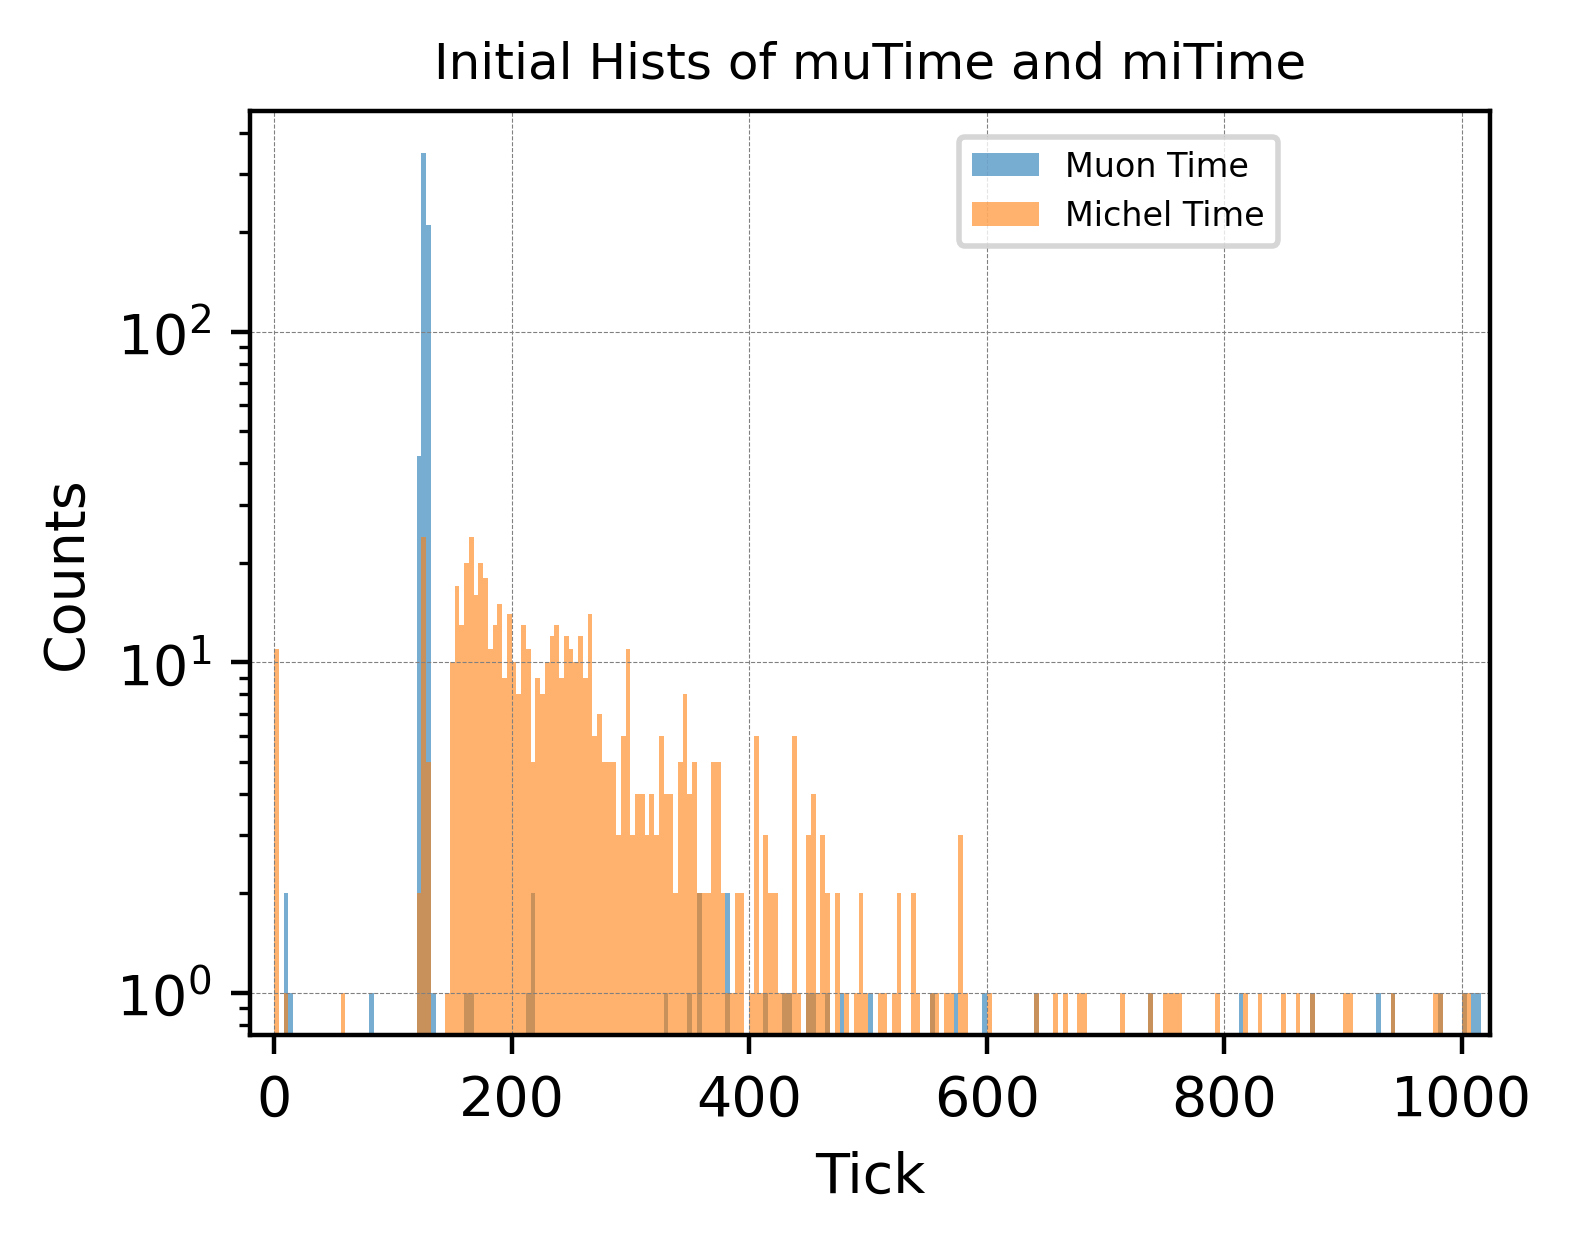

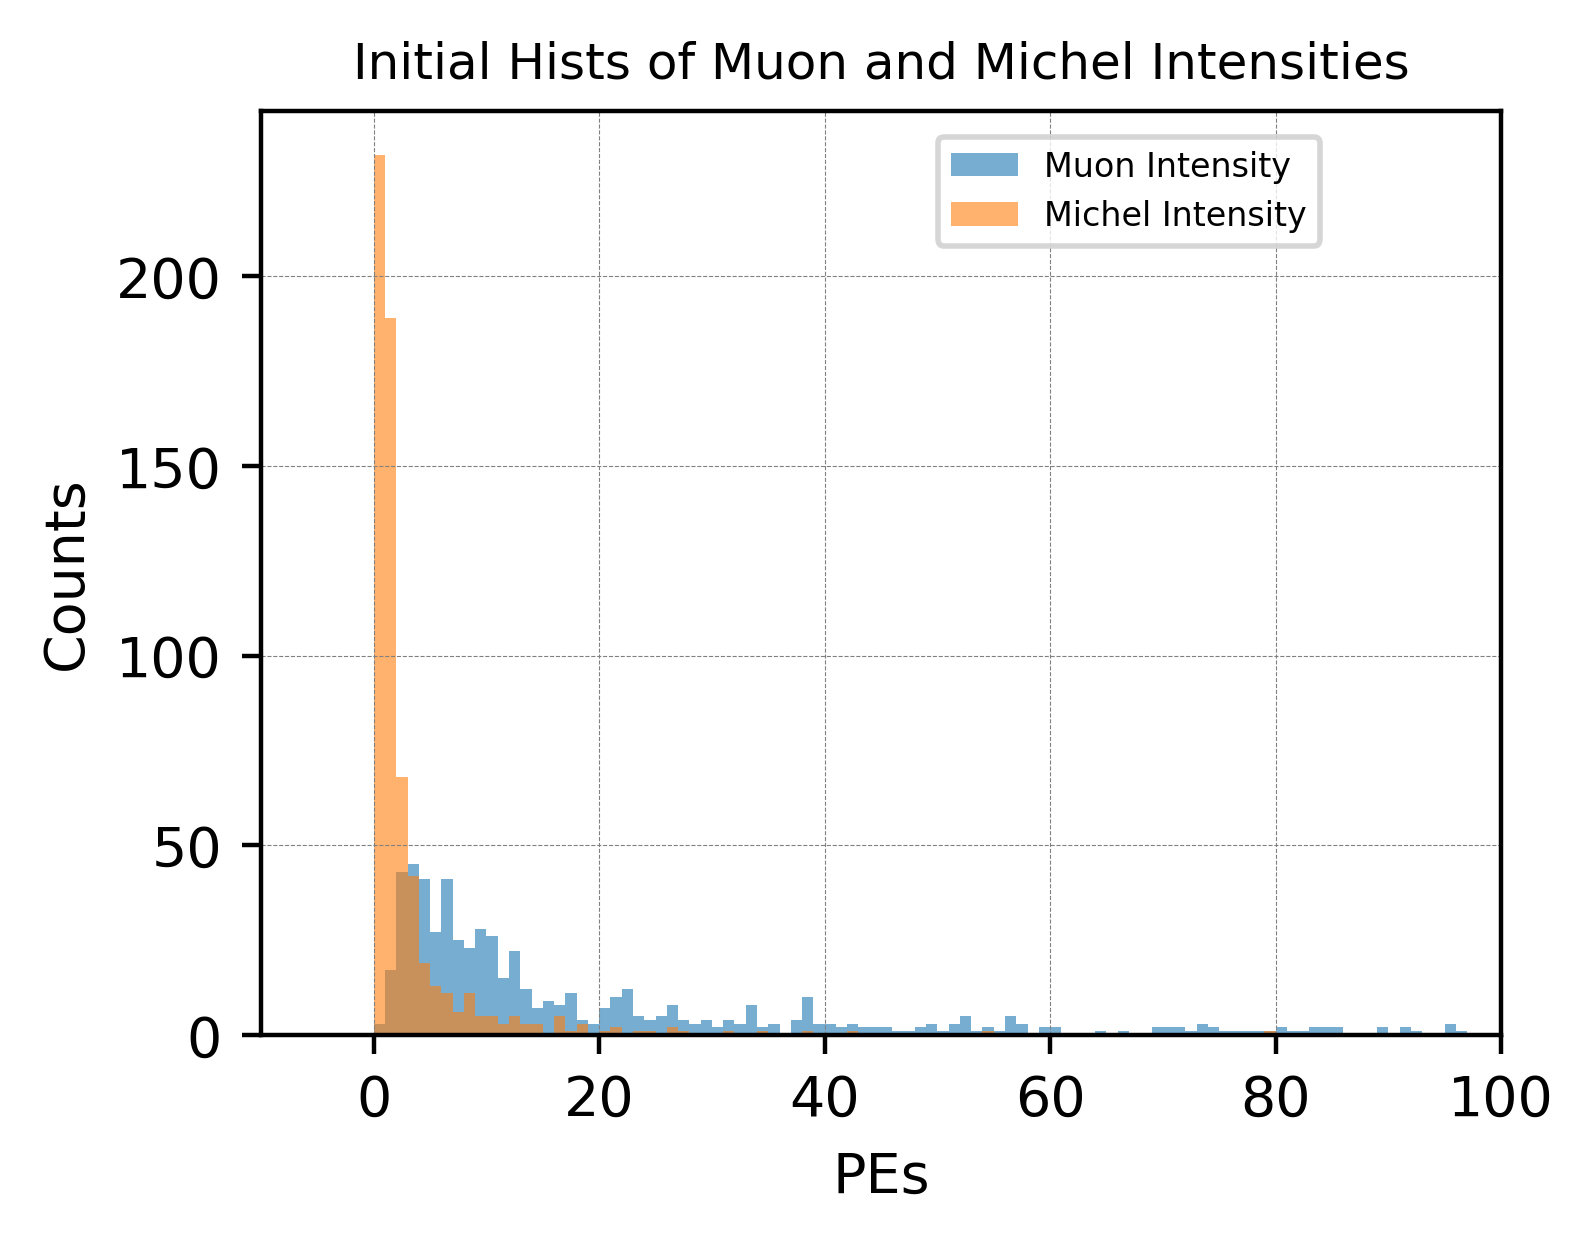

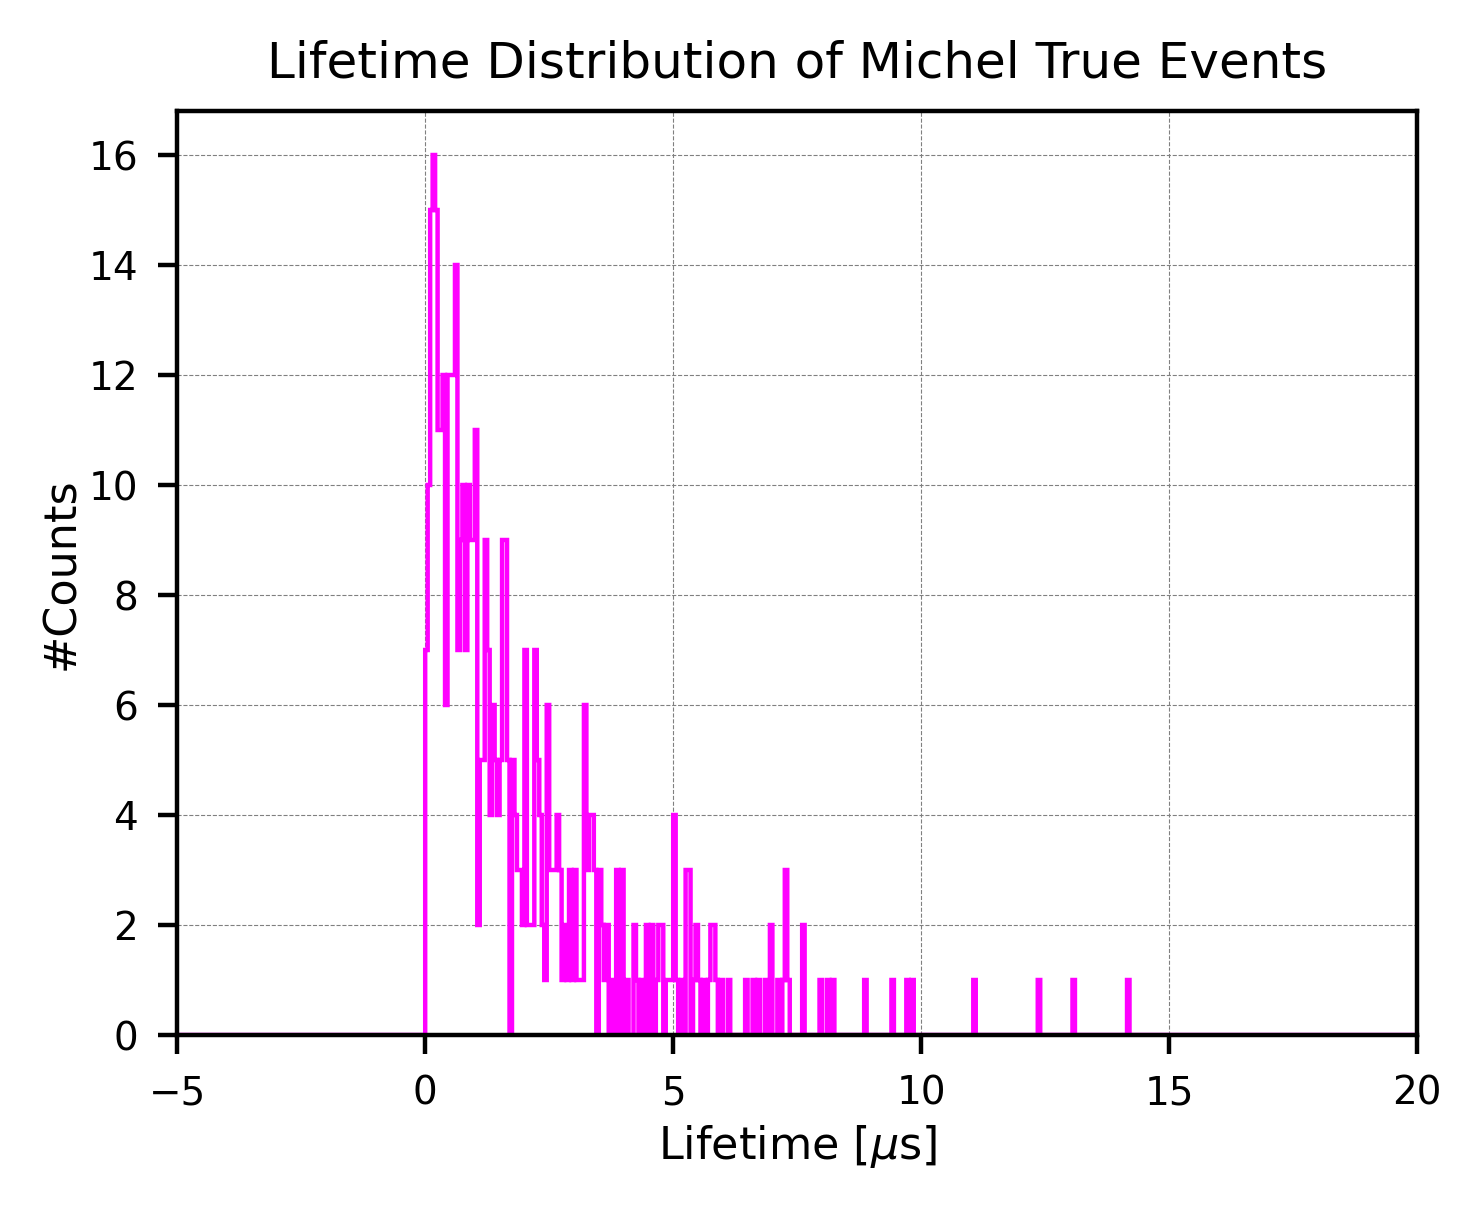

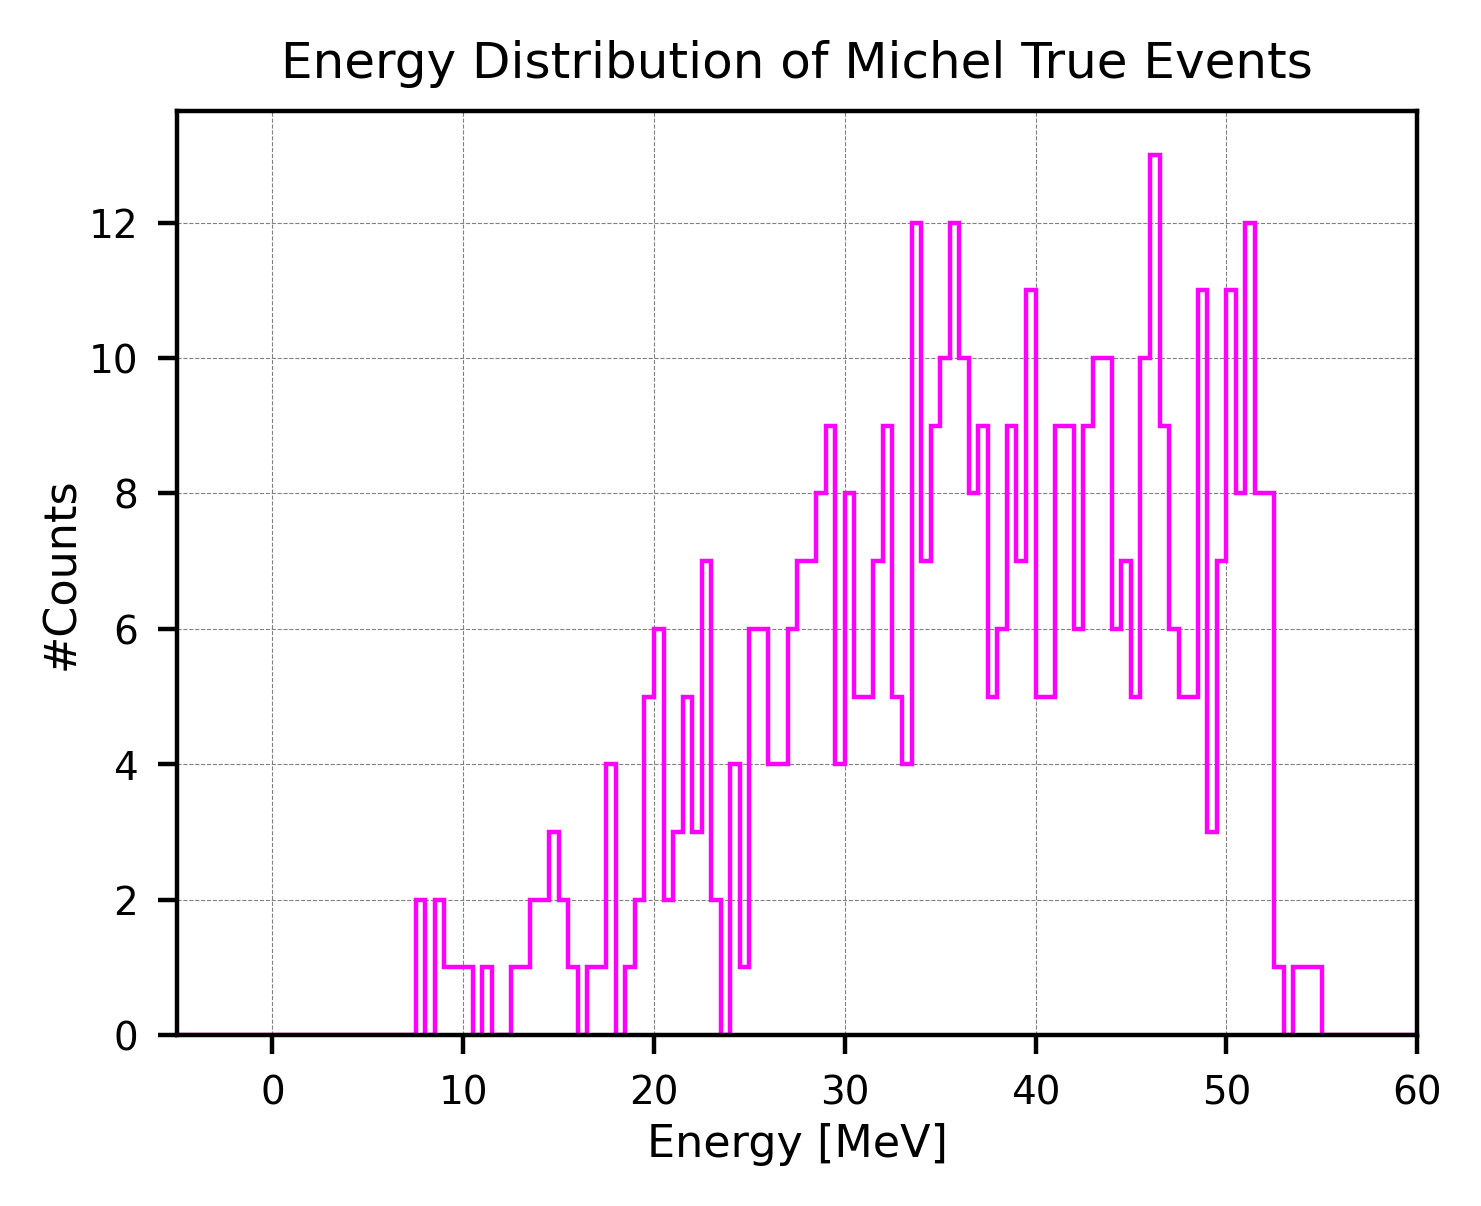

In [6]:
muon_time = [ev.muon_time for ev in events_reco_initial]
michel_time = [ev.michel_time for ev in events_reco_initial]

muon_intensity = [ev.muon_intensity for ev in events_reco_initial]
michel_intensity = [ev.michel_intensity for ev in events_reco_initial]

lifetime = [ev.lifetime for ev in events_true_initial] #true lifetime---
energy = [ev.energy for ev in events_true_initial] 


#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_time, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(michel_time, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()




#Initial Mu and Michel intensity distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 100
bin_width_initial = 1  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_intensity, bins=bins, alpha=0.6, label='Muon Intensity')
plt.hist(michel_intensity, bins=bins, alpha=0.6, label='Michel Intensity')

plt.xlabel('PEs')
plt.ylabel('Counts')
#plt.yscale('log')
plt.xlim(-10, 100)
plt.title('Initial Hists of Muon and Michel Intensities', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()







#True Lifetime distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(lifetime, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 20)
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 300)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.show()  





#True Energy distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.5
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(energy, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 500)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Energy Distribution of Michel True Events', fontsize=9)
plt.show()  





<br />
<br />
<br />
<br />


### Purification / cut 2: remove abnormal muon signals (constrain muTime to [120, 130])

Muon events selection (mu peak constrained to [120, 130]):
Updated Muon events:  601 (94.20%)
Length of time_difference (Updated):  601

Michel purity:  459 /  601 (76.37%)


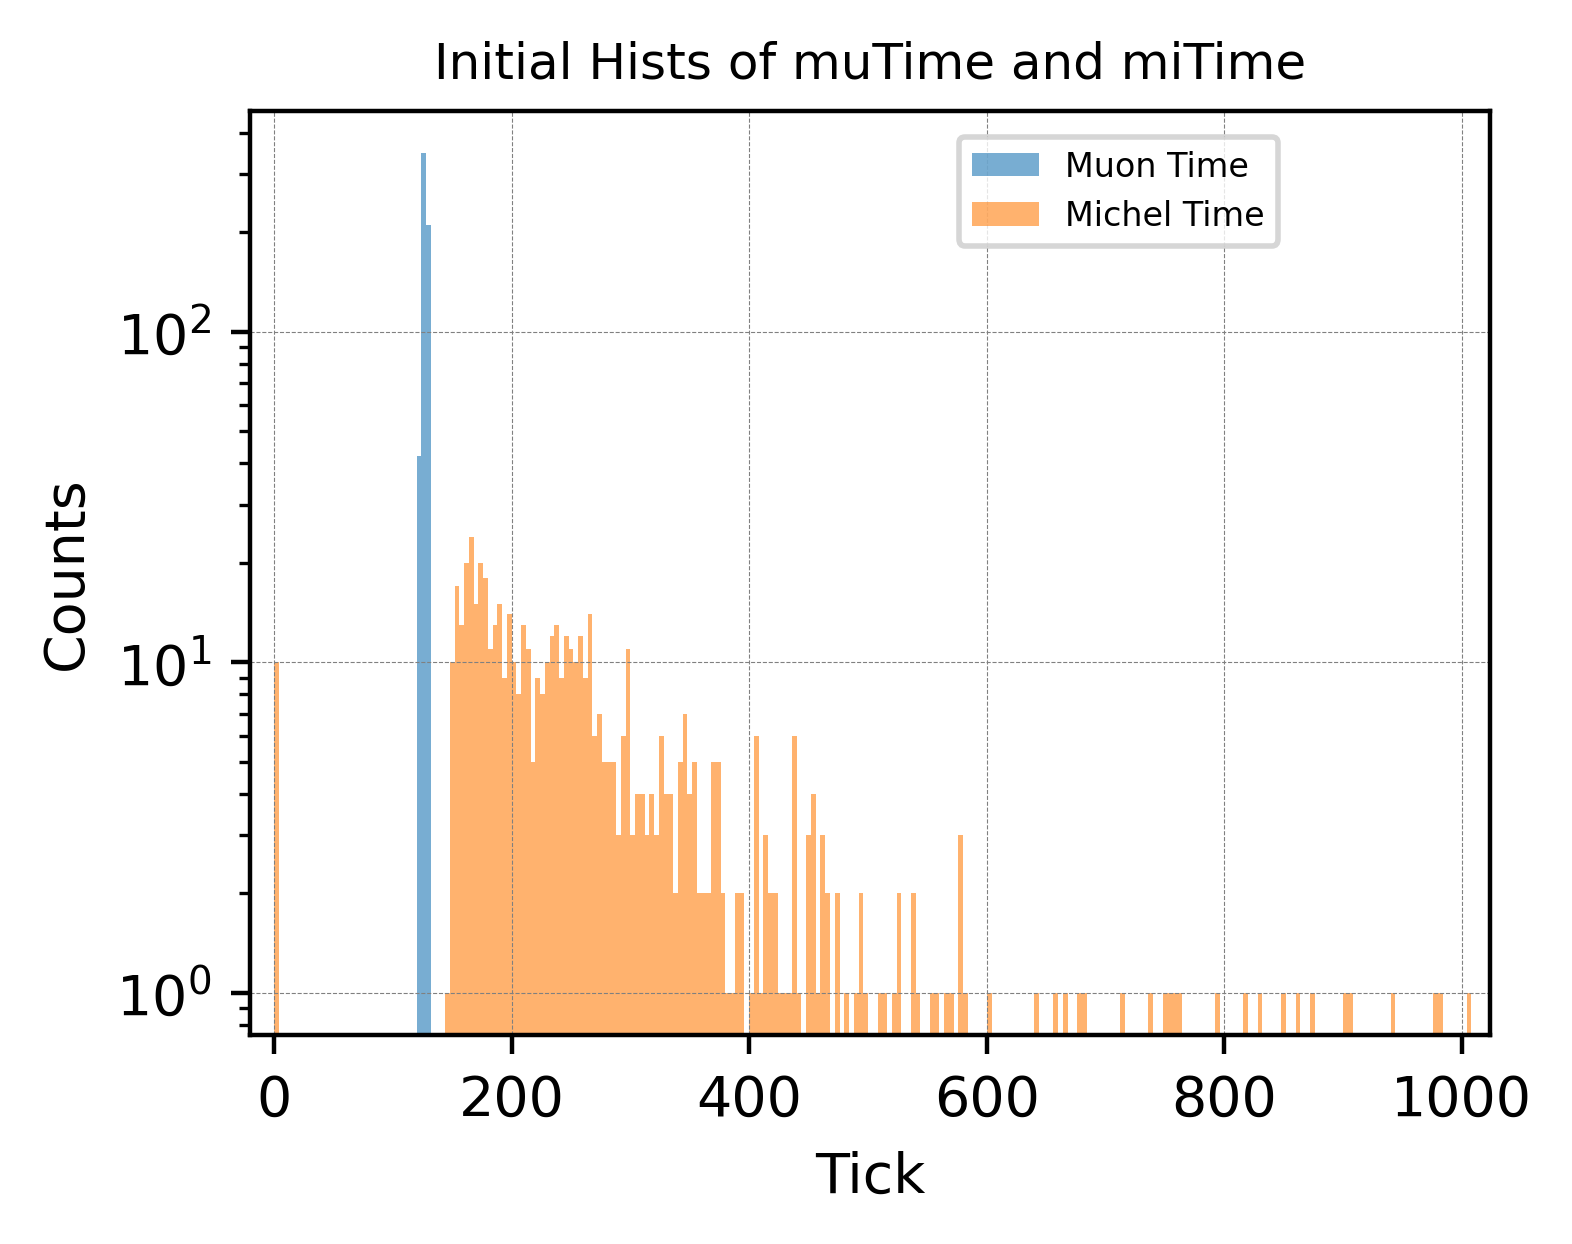




Lifetime distribution (Updated):
# Initial Candidates [-16000, 16000]:  601


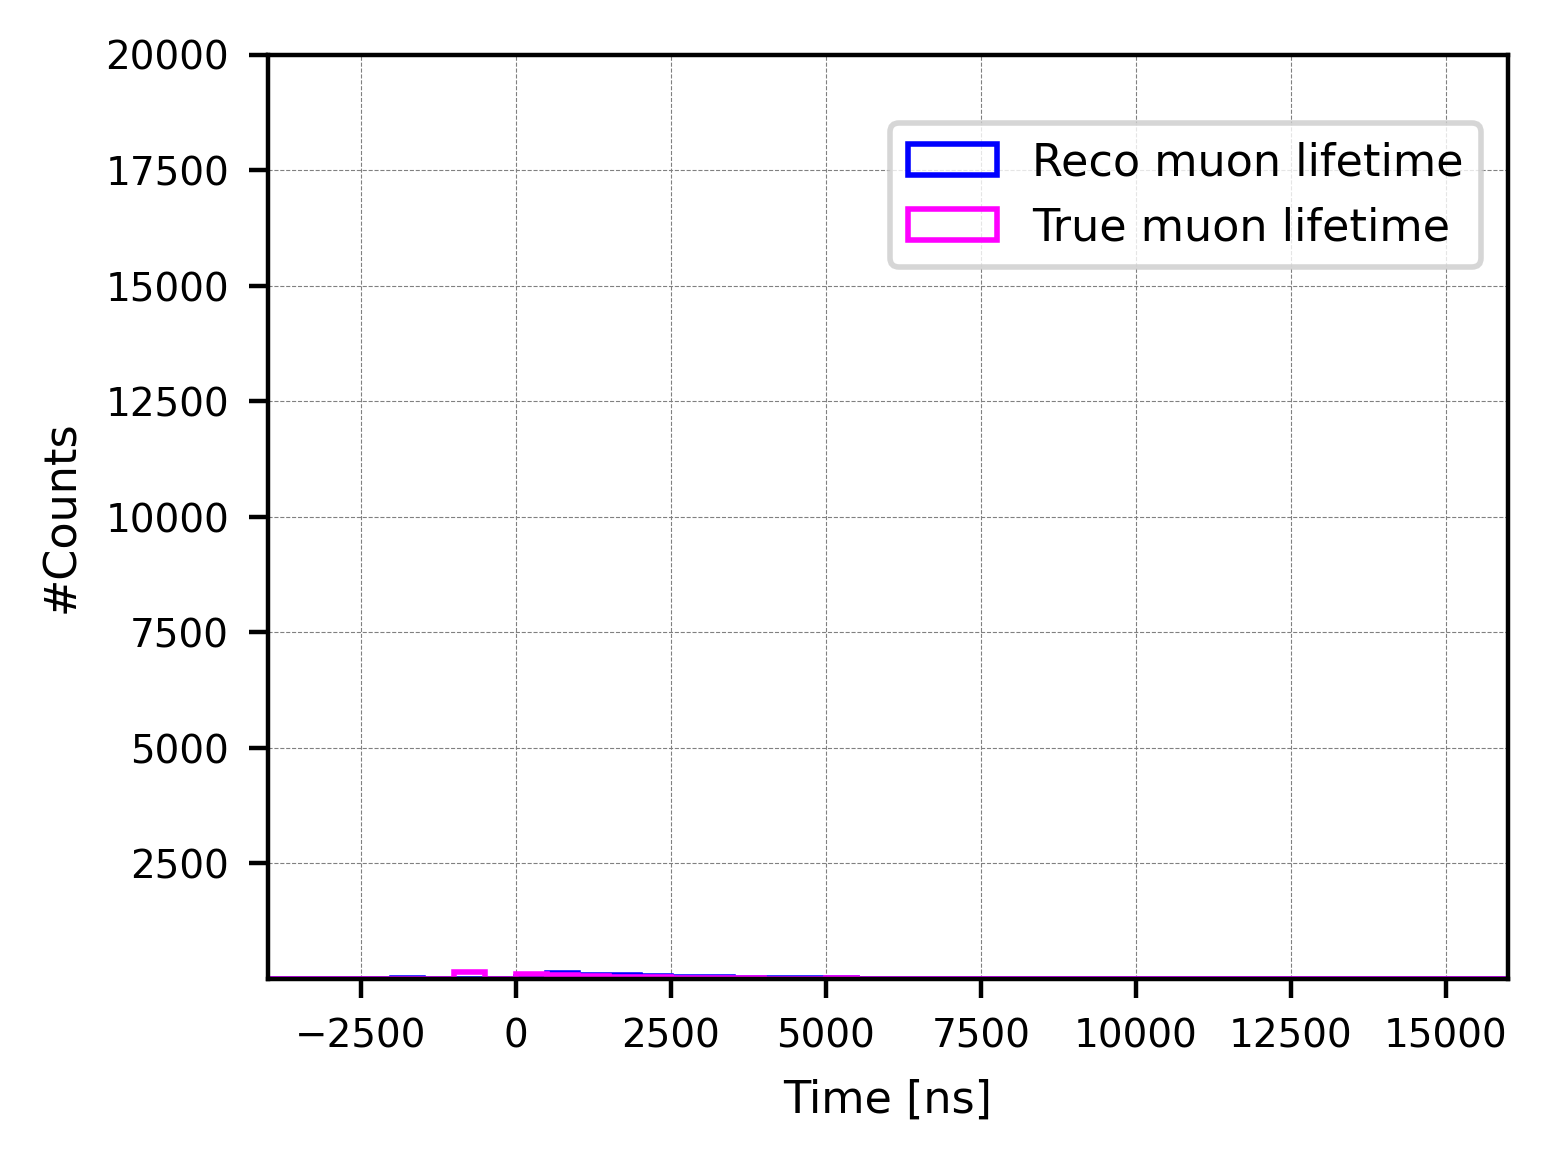

In [7]:
events_reco_update1 = []
events_true_update1 = []

lifetime_reco_update1 = []

for ev in events_reco_initial:
    muTime = ev.muon_time
    miTime = ev.michel_time
    energy = ev.energy

    if 120 <= muTime <= 130:
        events_reco_update1.append(ev)
        t = miTime-muTime
        lifetime_reco_update1.append(t)

        if energy > 0:
            events_true_update1.append(ev)


print("Muon events selection (mu peak constrained to [120, 130]):")
print("Updated Muon events: ", len(events_reco_update1),
       "({:.2f}%)".format(len(events_reco_update1)/len(events_reco_initial)*100))

# Element-wise subtraction: (mi - mu) for each corresponding element
print("Length of time_difference (Updated): ", len(lifetime_reco_update1))

print("\nMichel purity: ", len(events_true_update1), "/ ", len(events_reco_update1), 
      "({:.2f}%)".format(len(events_true_update1)/len(events_reco_update1)*100)) 









#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

muTime_update = [ev.muon_time for ev in events_reco_update1]
miTime_update = [ev.michel_time for ev in events_reco_update1]


# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muTime_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miTime_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()









# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Convert to ns (assuming mu_lifetime is already defined)
timdeDiff_update_ns = [value * 16 for value in lifetime_reco_update1]#reco lifetime---

lifetime_true_update1 = [ev.lifetime for ev in events_reco_update1]
lifetime_update_ns = [value * 1000 for value in lifetime_true_update1]#True lifetime---


print("\n\n\nLifetime distribution (Updated):")
print("# Initial Candidates [-16000, 16000]: ", len(timdeDiff_update_ns))

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(timdeDiff_update_ns, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')

plt.hist(lifetime_update_ns, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=1.0,
         label='True muon lifetime')


plt.xlim(-4000, 16000)
plt.ylim(0.9, 20000)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()






<br />
<br />
<br />
<br />


### Purification / cut 3: remove events with unphysical lifetime (constrain lifetime to [500, inf))

#### (20251022): lifetime cut should be >0 here (we know later that 500 is NOT a good standard)




Lifetime distribution (Updated):
# Updated Candidates [0, 16000]:  591

#Purity:  452 / 591 (76.48%)


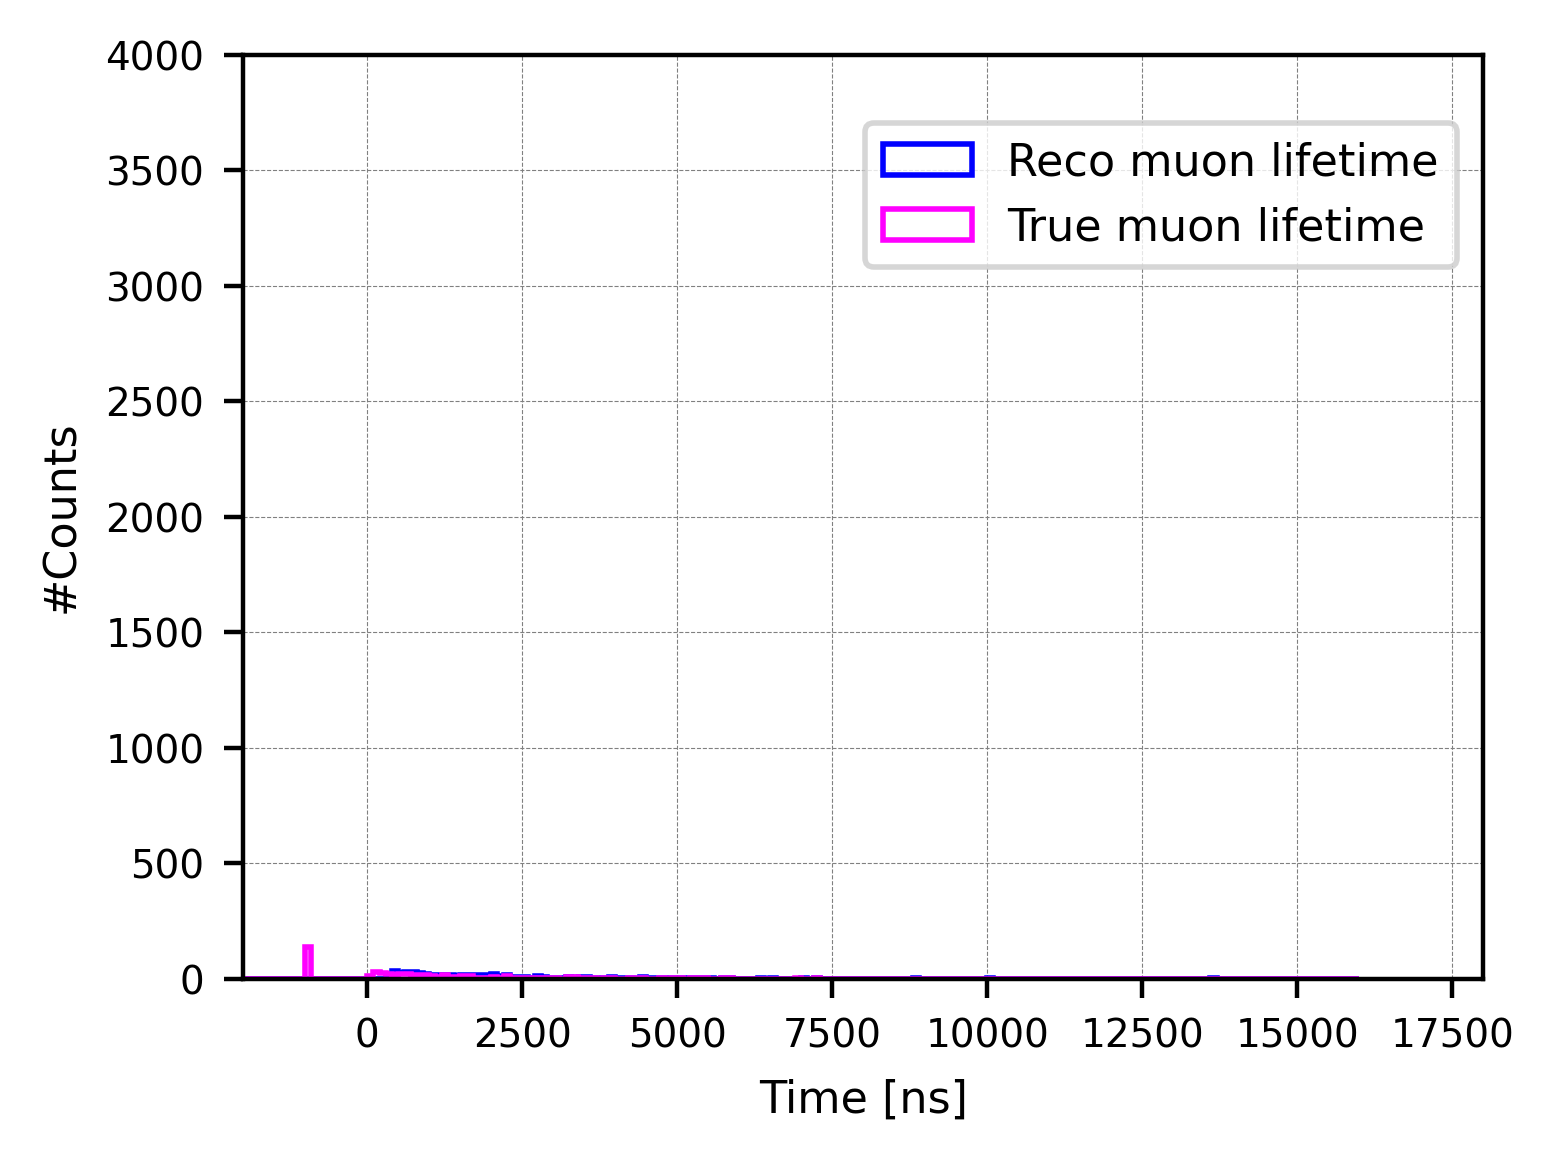


--------------------------------------
[-500, 500]:  285 / 591 (48.22%)


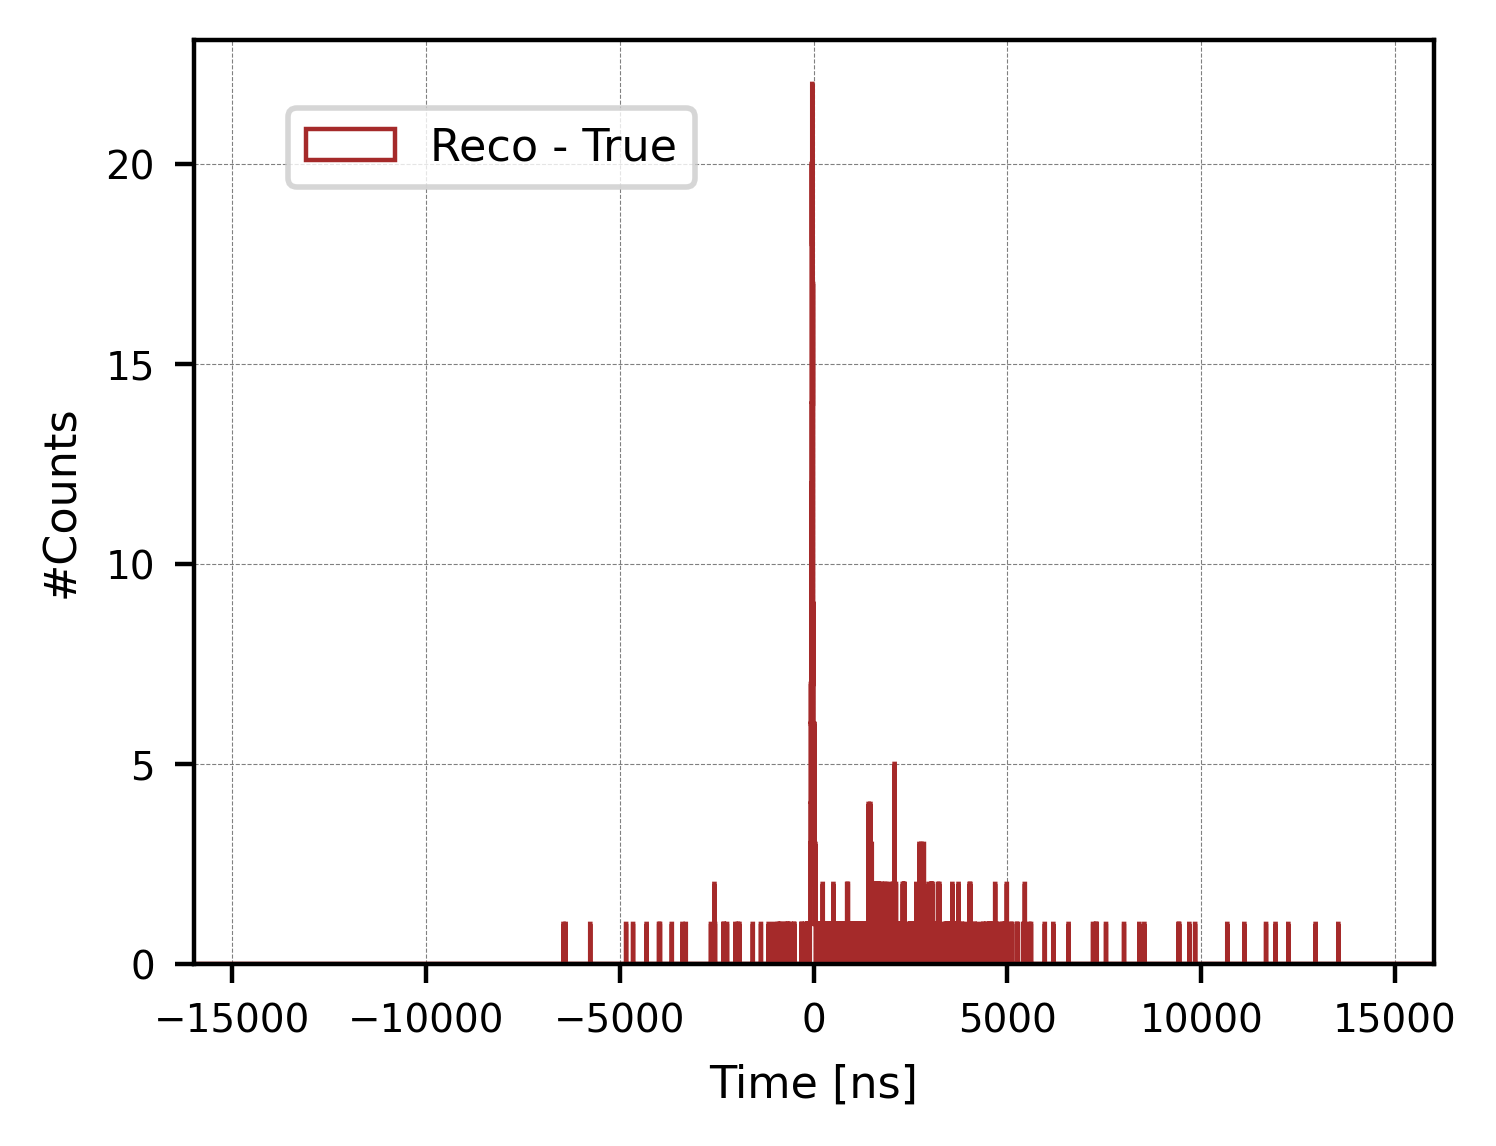



Explore the peak------


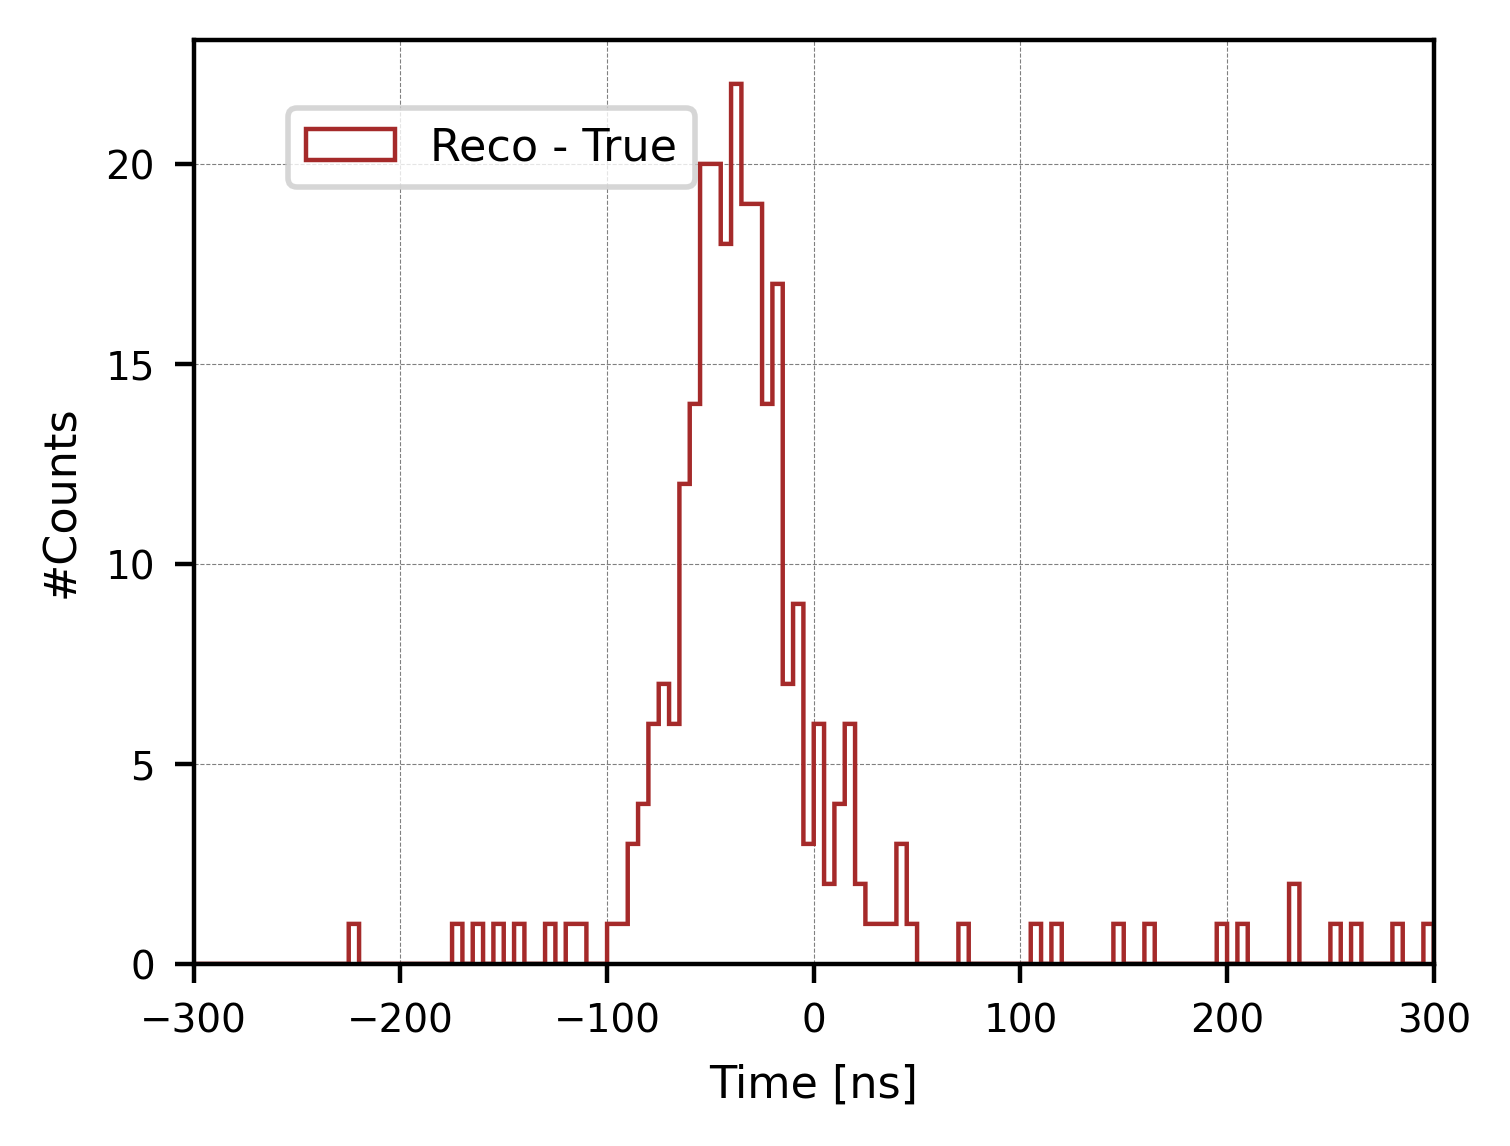

In [8]:
events_reco_update2 = []#Dataset after Purification 2---
events_true_update2 = []
lifetime_reco_update2 = []

for ev in events_reco_update1:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---
    e = ev.energy

    if 0 <= timeDiff: #keep physical events here---
        events_reco_update2.append(ev)
        lifetime_reco_update2.append(timeDiff)

        if e > 0:
            events_true_update2.append(ev)


print("\n\n\nLifetime distribution (Updated):")
print("# Updated Candidates [0, 16000]: ", len(events_reco_update2))

        
print("\n#Purity: ", len(events_true_update2), "/", len(events_reco_update2), 
     "({:.2f}%)".format(len(events_true_update2)/len(events_reco_update2)*100))







# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 100
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(lifetime_reco_update2, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')


lifetime_update_ns2 = [ev.lifetime * 1000 for ev in events_reco_update2]#True lifetime (contain false)---
plt.hist(lifetime_update_ns2, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=1.0,
         label='True muon lifetime')


plt.xlim(-2000, 18000)
plt.ylim(0, 4000)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()







#---------------------------------------------------------------
#Reco True difference-------------------------------------------

diff_reco_true = []
for ev in events_reco_update2:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---
    lifetime = ev.lifetime * 1000 #convert to ns---

    diff_reco_true.append(timeDiff-lifetime)


reco_true_count_500 = sum(-500 <= x <= 500 for x in diff_reco_true)
print("\n--------------------------------------")
print("[-500, 500]: ", reco_true_count_500, "/", len(diff_reco_true), 
     "({:.2f}%)".format(reco_true_count_500/len(diff_reco_true)*100))


#------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 5
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(diff_reco_true, bins=bins, range=(range_min, range_max),
         edgecolor='brown', histtype='step', linewidth=0.8,
         label='Reco - True')


plt.xlim(-16000, 16000)
#plt.ylim(0.1, 3000)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.24, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()


#------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

print("\n\nExplore the peak------")

# Plot histogram-----------------
plt.hist(diff_reco_true, bins=bins, range=(range_min, range_max),
         edgecolor='brown', histtype='step', linewidth=0.8,
         label='Reco - True')

plt.xlim(-300, 300)
#plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Ex=')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.24, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()

<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Explore Dataset After purification 3 [RecoT>0]:

In [9]:
@dataclass
class PdsEventNew: #new class containing reco lifetime, true lifetime & diff
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    third_intensity: Optional[float] = None
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    energy: Optional[float] = None
    lifetime: Optional[float] = None #in unit of us---
    pdg: Optional[int] = None
    eventID: Optional[int] = None
    trackID: Optional[int] = None
    date: Optional[int] = None 
    michel_score: Optional[float] = None         # ✅ NEW
    michel_hits: Optional[int] = None 
    reco_lifetime: Optional[float] = None
    true_lifetime: Optional[float] = None # in unit of ns---
    diff_lifetime: Optional[float] = None
    michel_rise: Optional[float] = None
    michel_drop: Optional[float] = None



#Test print---------------
print("Size of events_reco_update2 (previous class): ", len(events_reco_update2))

#New calculated reco & true lifetime lists:
recoLife_update2 = []
trueLife_update2 = []  
diffLife_update2 = []

michel_rise_slope = []
michel_drop_slope = []

for ev in events_reco_update2:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---

    recoLife_update2.append(timeDiff)
    trueLife_update2.append(ev.lifetime * 1000)
    diffLife_update2.append(timeDiff - ev.lifetime * 1000)

    left_slope = ev.mi_leftHeight / (miTime - ev.mi_leftTurn)
    right_slope = ev.mi_rightHeight / (ev.mi_rightTurn - miTime)

#    left_slope = (miTime - ev.mi_leftTurn)
#    right_slope = (ev.mi_rightTurn - miTime)

    michel_rise_slope.append(left_slope)
    michel_drop_slope.append(right_slope)

print("Size of lifetime_reco_update2               : ", len(recoLife_update2))
print("Size of lifetime_update_ns2                 : ", len(trueLife_update2))



#Final events with new features----------
events_newClass = []
for ev, reco_life, true_life, diff_life, rise, drop in zip(
    events_reco_update2, 
    recoLife_update2, 
    trueLife_update2, 
    diffLife_update2,
    michel_rise_slope,
    michel_drop_slope
    ):
    new_ev = PdsEventNew(
        muon_time=ev.muon_time,
        michel_time=ev.michel_time,
        muon_intensity=ev.muon_intensity,
        michel_intensity=ev.michel_intensity,
        third_intensity=ev.third_intensity,
        posX=ev.posX,
        posY=ev.posY,
        posZ=ev.posZ,
        energy=ev.energy,
        lifetime=ev.lifetime,
        pdg=ev.pdg,
        eventID=ev.eventID,
        trackID=ev.trackID,
        date=ev.date,
        michel_score=ev.michel_score,
        michel_hits=ev.michel_hits, 
        reco_lifetime=reco_life,
        true_lifetime=true_life,
        diff_lifetime=diff_life,
        michel_rise=rise,
        michel_drop=drop
    )
    events_newClass.append(new_ev)

print("\nLength of final dataset in format of new class: ", len(events_newClass))


events_diff500 = []
events_diff0 = []
true_newClass = []
for ev in events_newClass:
    if ev.energy > 0:
        true_newClass.append(ev)

#===========================================================================
    if ev.diff_lifetime > 50 or ev.diff_lifetime < -110:
        events_diff500.append(ev)
    if -110 < ev.diff_lifetime < 50:
        events_diff0.append(ev)
#===========================================================================

print("\nLength of final true in format of new class: ", len(true_newClass))

print("\nEvents with diff [-110, 50] : ", len(events_diff0), "/", len(events_newClass),
       "({:.2f}%)".format(len(events_diff0)/len(events_newClass)*100))
print("\nEvents with diff OTHERS: ", len(events_diff500), "/", len(events_newClass),
       "({:.2f}%)".format(len(events_diff500)/len(events_newClass)*100))


Size of events_reco_update2 (previous class):  591
Size of lifetime_reco_update2               :  591
Size of lifetime_update_ns2                 :  591

Length of final dataset in format of new class:  591

Length of final true in format of new class:  452

Events with diff [-110, 50] :  249 / 591 (42.13%)

Events with diff OTHERS:  342 / 591 (57.87%)


### Purification 4:  Michel Intensity / Muon Intensity:

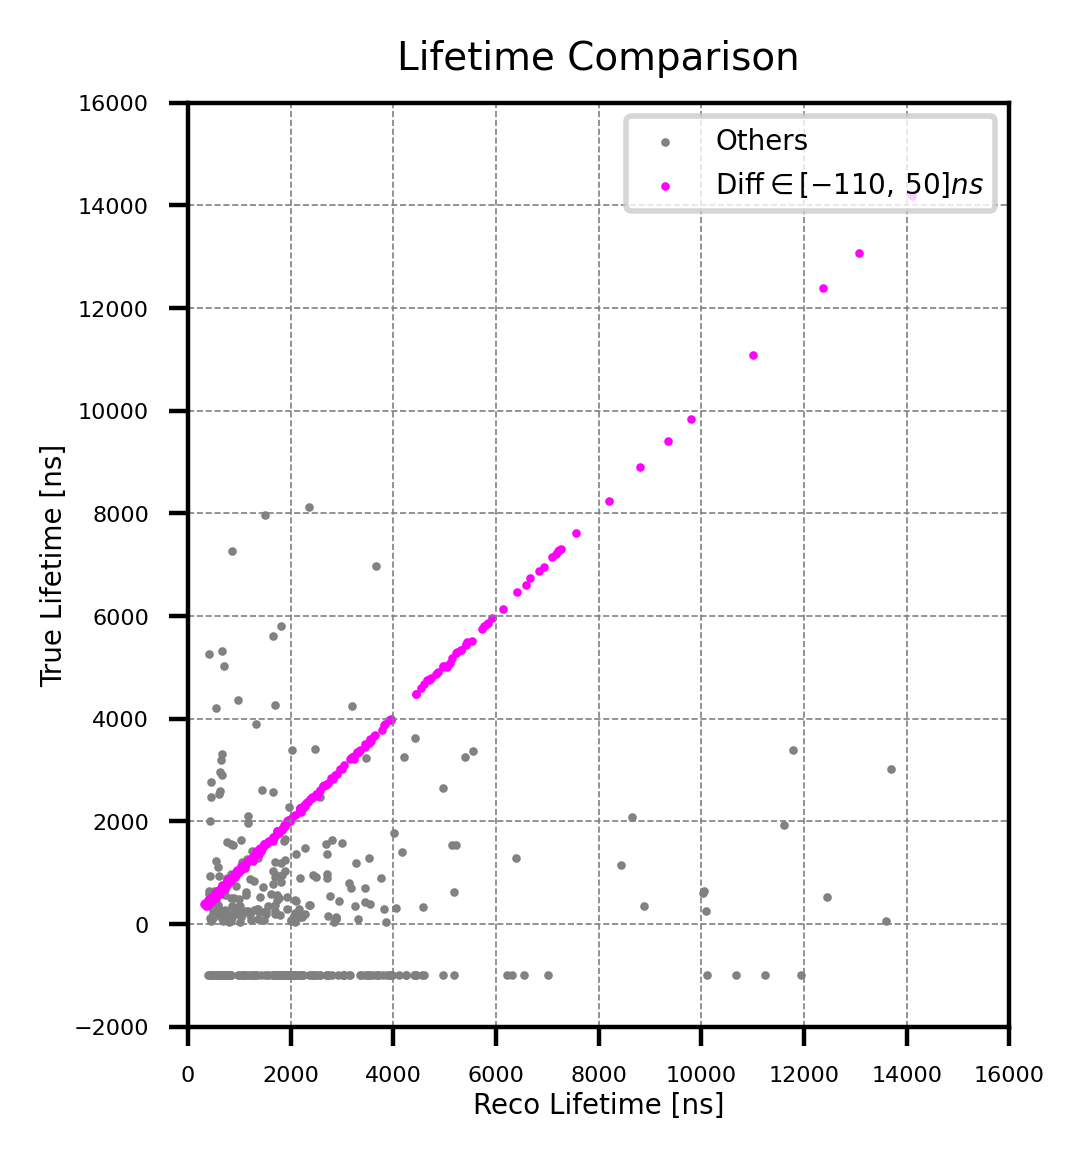

After lifetime cut (cut 3):
Purity (true / reco):  452 / 591 (76.48%)

(Diff [-110, 50]):  249 / 591 (42.13%)
(Diff OTHERS)    :  342 / 591 (57.87%)

(michel Intensity) / (muon intensity) (Cut 4):----------
Efficiency (cut4 / cut3):  275 / 591 (46.53%)
Purity (true / reco):  251 / 275 (91.27%)

(Diff [-110, 50]):  177 / 275 (64.36%)
(Diff Others)    :  98 / 275 (35.64%)


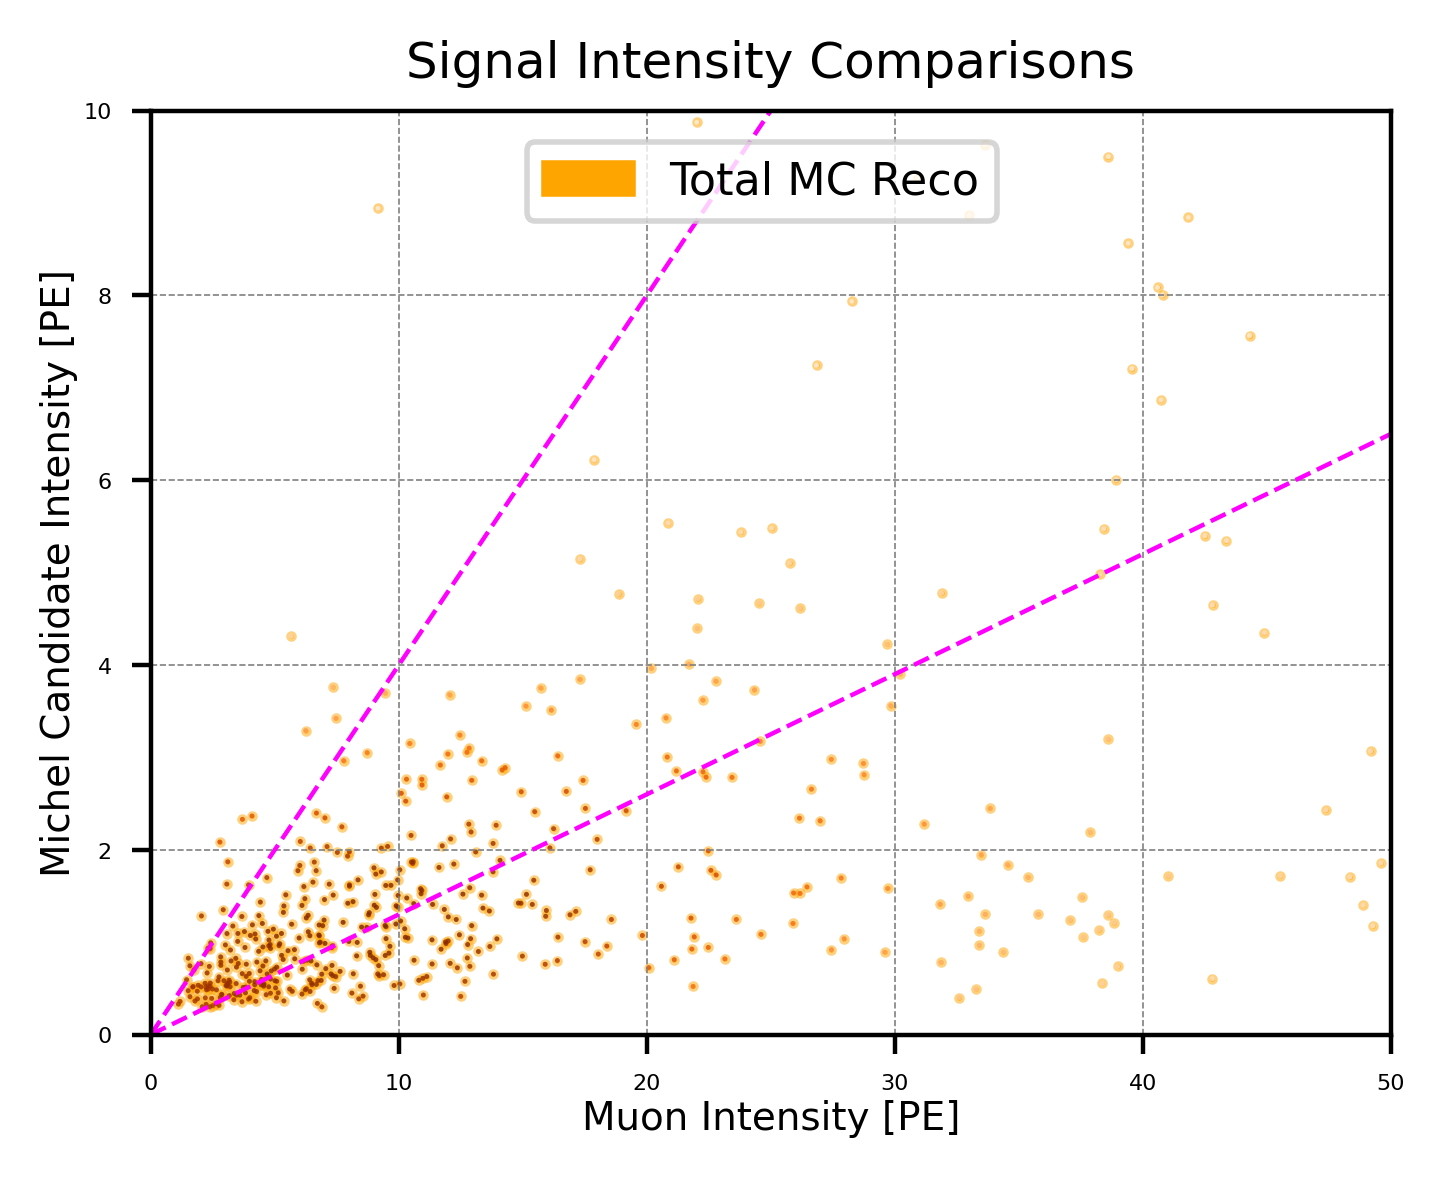


Purify 4----------------------


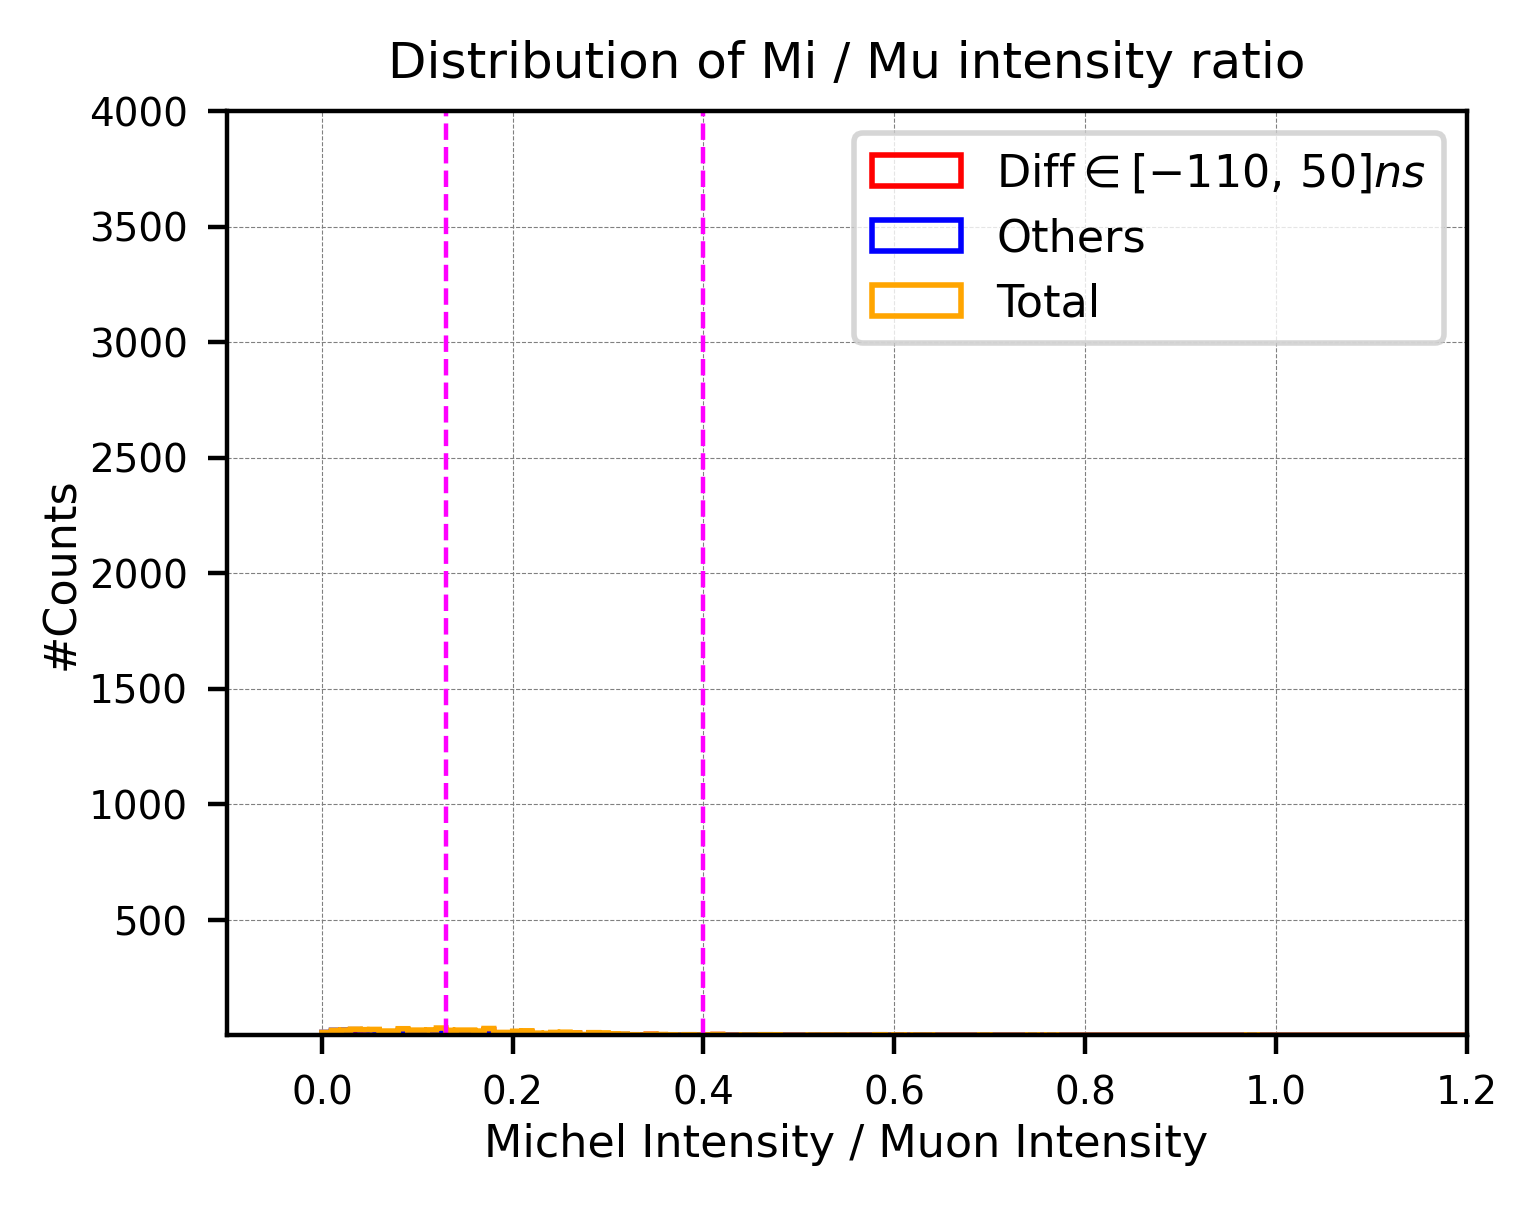

In [10]:
from scipy.stats import gaussian_kde
from matplotlib import colors 
import matplotlib.patches as mpatches

trueLife_diff500 = [ev.true_lifetime for ev in events_diff500]
recoLife_diff500 = [ev.reco_lifetime for ev in events_diff500]
muInt_diff500 = [ev.muon_intensity for ev in events_diff500]
miInt_diff500 = [ev.michel_intensity for ev in events_diff500]
X_diff500 = [ev.posX for ev in events_diff500]

trueLife_diff0 = [ev.true_lifetime for ev in events_diff0]
recoLife_diff0 = [ev.reco_lifetime for ev in events_diff0]
muInt_diff0 = [ev.muon_intensity for ev in events_diff0]
miInt_diff0 = [ev.michel_intensity for ev in events_diff0]
X_diff0 = [ev.posX for ev in events_diff0]

# Total---
muInt_total = [ev.muon_intensity for ev in events_newClass]
miInt_total = [ev.michel_intensity for ev in events_newClass]


# ==========================================================
# TrueLife VS RecoLife
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot----------
plt.scatter(recoLife_diff500, trueLife_diff500, s=0.3, c='grey', alpha=1.0, label="Others")
plt.scatter(recoLife_diff0, trueLife_diff0, s=0.3, c='magenta', alpha=1.0, label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
#-----------------------

plt.axis('scaled')
plt.xlim(0, 16000)
plt.ylim(-2000, 16000)
plt.ylabel('True Lifetime [ns]', labelpad=1, fontsize=5)
plt.xlabel('Reco Lifetime [ns]', labelpad=1, fontsize=5)
plt.title('Lifetime Comparison', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.legend(fontsize=5, loc="upper right")
plt.show()








#Michel Intensity Cut (Cut 4)================================================
print("After lifetime cut (cut 3):")

n_valid = sum(1 for ev in events_newClass if ev.energy is not None and ev.energy > 0)
print("Purity (true / reco): ", n_valid, "/", len(events_newClass),
      "({:.2f}%)".format(n_valid/len(events_newClass)*100))

print("\n(Diff [-110, 50]): ", len(events_diff0), "/", len(events_newClass),
       "({:.2f}%)".format(len(events_diff0)/len(events_newClass)*100))
print("(Diff OTHERS)    : ", len(muInt_diff500), "/", len(events_newClass),
       "({:.2f}%)".format(len(muInt_diff500)/len(events_newClass)*100))



thre1 = 6.5 / 50
thre2 = 40 / 100

# filter the actual events
events_diff0_purify4 = [
    ev for ev in events_diff0
    if ev.muon_intensity != 0 and thre1 < ev.michel_intensity / ev.muon_intensity < thre2
]
events_diff500_purify4 = [
    ev for ev in events_diff500
    if ev.muon_intensity != 0 and thre1 < ev.michel_intensity / ev.muon_intensity < thre2
]
#-------------------------------

print("\n(michel Intensity) / (muon intensity) (Cut 4):----------")
events_total_purify4 = events_diff0_purify4 + events_diff500_purify4

print("Efficiency (cut4 / cut3): ", len(events_total_purify4), "/", len(events_newClass),
      "({:.2f}%)".format(len(events_total_purify4)/len(events_newClass)*100))

n_valid = sum(1 for ev in events_total_purify4 if ev.energy is not None and ev.energy > 0)
print("Purity (true / reco): ", n_valid, "/", len(events_total_purify4),
      "({:.2f}%)".format(n_valid/len(events_total_purify4)*100))

print("\n(Diff [-110, 50]): ", len(events_diff0_purify4), "/", len(events_total_purify4),
       "({:.2f}%)".format(len(events_diff0_purify4)/len(events_total_purify4)*100))
print("(Diff Others)    : ", len(events_diff500_purify4), "/", len(events_total_purify4),
       "({:.2f}%)".format(len(events_diff500_purify4)/len(events_total_purify4)*100))










# ==========================================================
# Mu Intensity VS Michel Intensity
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(muInt_diff500), np.array(miInt_diff500)
x2, y2 = np.array(muInt_diff0), np.array(miInt_diff0)
x3, y3 = np.array(muInt_total), np.array(miInt_total)#total---
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Density for group 2 (blue, 0<Diff<500) ---
xy2 = np.vstack([x2, y2])
z2 = gaussian_kde(xy2)(xy2)
idx2 = z2.argsort()
x2, y2, z2 = x2[idx2], y2[idx2], z2[idx2]
# --- Density for group total ---
xy3 = np.vstack([x3, y3])
z3 = gaussian_kde(xy3)(xy3)
idx3 = z3.argsort()
x3, y3, z3 = x3[idx3], y3[idx3], z3[idx3]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
#plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
#plt.scatter(x2, y2, s=0.8, color="red", alpha=0.5, label="_nolegend_")
plt.scatter(x3, y3, s=0.8, color="orange", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
#plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Others")
#plt.scatter(x2, y2, c=z2, s=0.8, cmap="Reds", alpha=0.8, edgecolors="none", label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.scatter(x3, y3, c=z3, s=0.8, cmap="Oranges", alpha=0.8, edgecolors="none", label="MC Reco Total")
#---------------------------------

plt.plot([0, 500], [0, 65], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0, 1000], [0, 400], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 50)#(-5, 400)
plt.ylim(0, 10)#(-5, 60)
plt.xlabel('Muon Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Michel Candidate Intensity [PE]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
#red_patch = mpatches.Patch(color="blue", label="Others")
#blue_patch = mpatches.Patch(color="red", label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
#plt.legend(handles=[red_patch, blue_patch], loc="upper right", frameon=True, 
#           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

orange_patch = mpatches.Patch(color="orange", label="Total MC Reco")
plt.legend(handles=[orange_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})


plt.show()






#Ratio distribution===================================
print("\nPurify 4----------------------")

ratio_diff500_purify3 = [mi / mu for mi, mu in zip(miInt_diff500, muInt_diff500) if mu != 0]
ratio_diff0_purify3 = [mi / mu for mi, mu in zip(miInt_diff0, muInt_diff0) if mu != 0]
ratio_total_purify3 = [mi / mu for mi, mu in zip(miInt_total, muInt_total) if mu != 0]

plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.01
range_min = 0
range_max = 10
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(ratio_diff0_purify3, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.hist(ratio_diff500_purify3, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")
plt.hist(ratio_total_purify3, bins=bins, range=(range_min, range_max), edgecolor='orange', 
         histtype='step', linewidth=1.0, label="Total")

plt.plot([0.13, 0.13], [0, 4000], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0.4, 0.4], [0, 4000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.1, 1.2)
plt.xlabel('Michel Intensity / Muon Intensity', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 4000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Mi / Mu intensity ratio', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 



#### Cut 5: Michel intensity & Muon intensity: 

After cut 4):
Purity (true / reco):  251 / 275 (91.27%)

(Diff 【-110, 50】:  177 / 275 (64.36%)
(Diff Others     :  98 / 275 (35.64%)

Michel Intensity Cut (Cut 5):--------------
Efficiency (cut5 / cut4):  204 / 275 (74.18%)
Purity (true / reco)    :  189 / 204 (92.65%)

(Diff [-110, 50]:  158 / 204 (77.45%)
(Diff OTHERS    :  46 / 204 (22.55%)


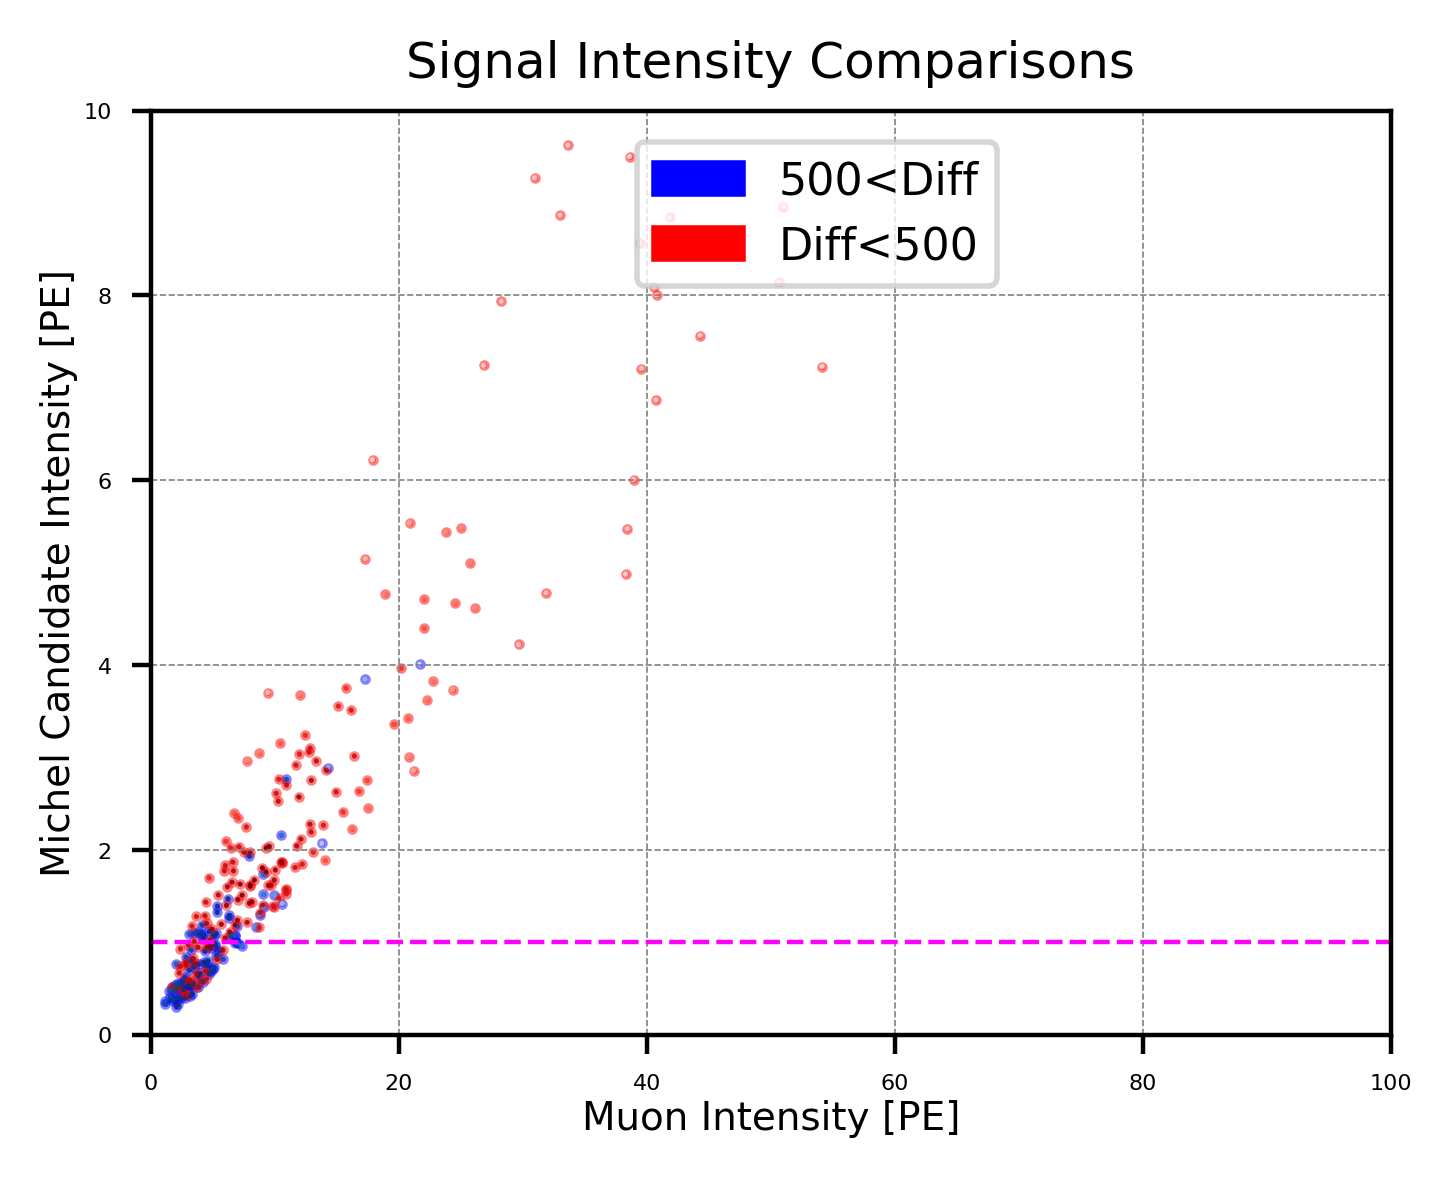


Purify 5----------------------


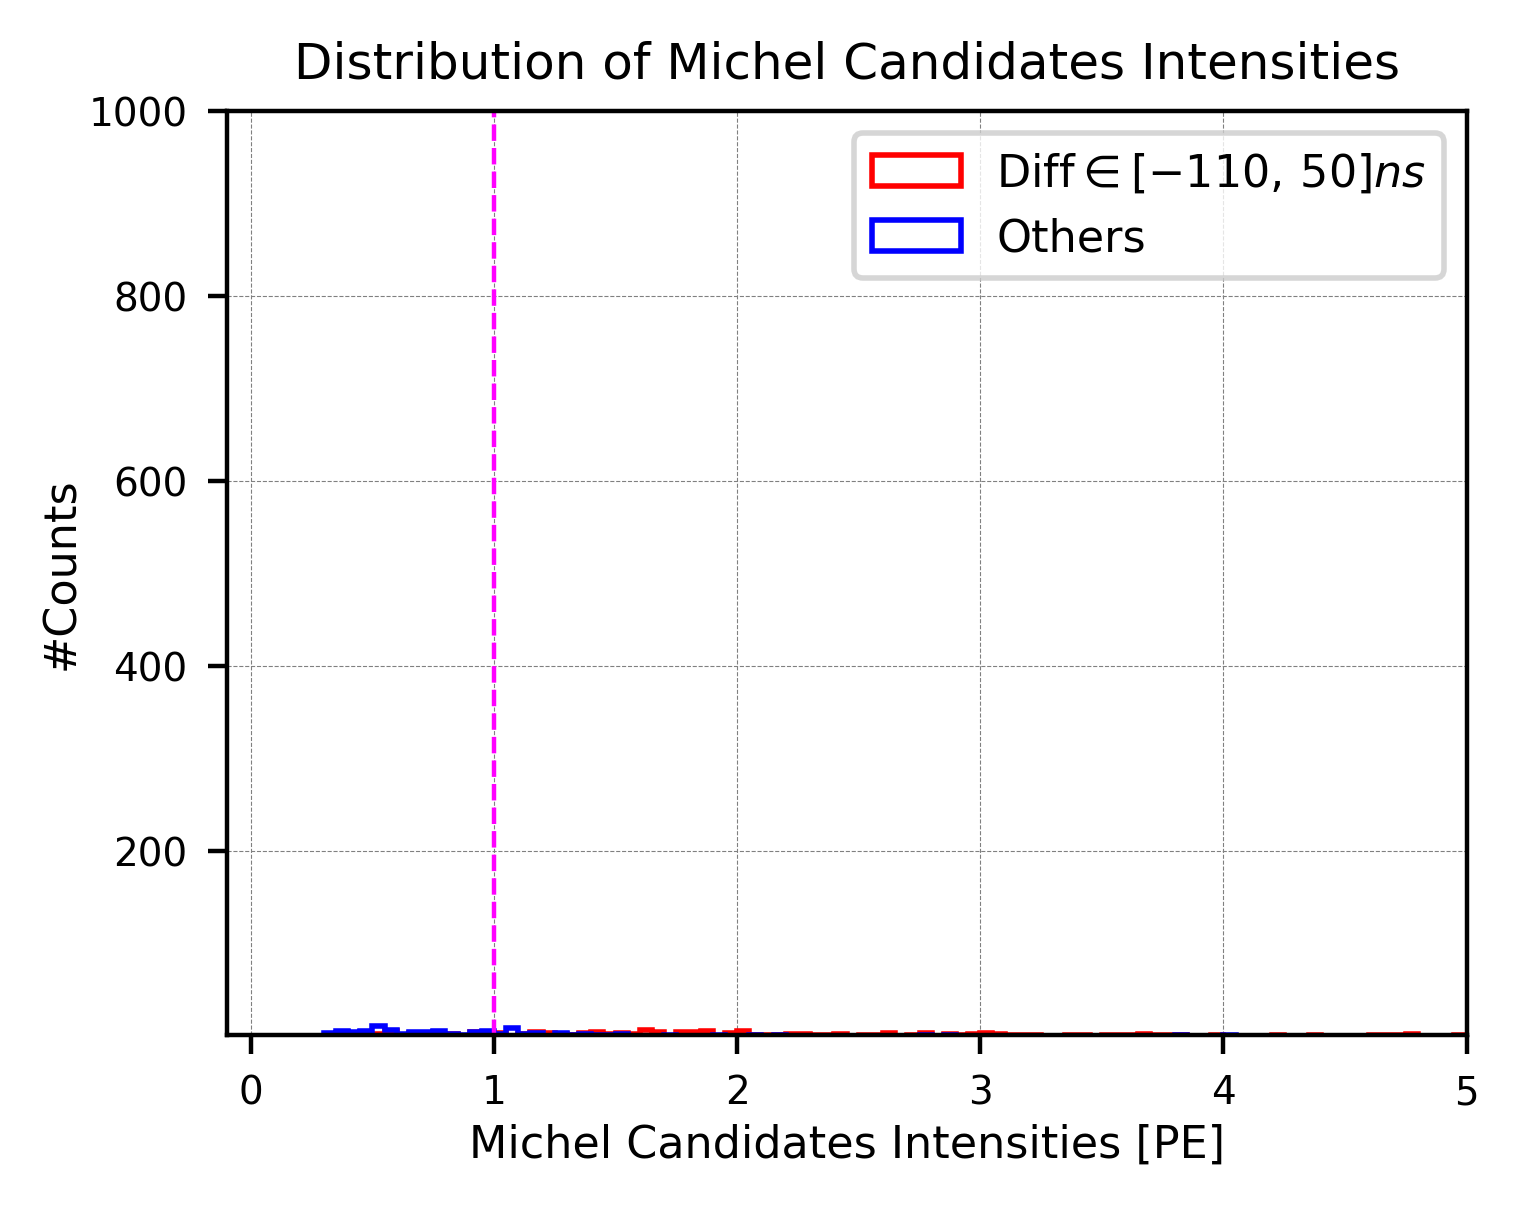

In [11]:
#Michel & Muon Intensities Cut (Cut 5)================================================
print("After cut 4):")

n_valid = sum(1 for ev in events_total_purify4 if ev.energy is not None and ev.energy > 0)
print("Purity (true / reco): ", n_valid, "/", len(events_total_purify4),
      "({:.2f}%)".format(n_valid/len(events_total_purify4)*100))

print("\n(Diff 【-110, 50】: ", len(events_diff0_purify4), "/", len(events_total_purify4),
       "({:.2f}%)".format(len(events_diff0_purify4)/len(events_total_purify4)*100))
print("(Diff Others     : ", len(events_diff500_purify4), "/", len(events_total_purify4),
       "({:.2f}%)".format(len(events_diff500_purify4)/len(events_total_purify4)*100))



thre_muInt = 0.3 # mu Int will automatically higher than mi---
thre_miInt = 0.9

# filter the actual events
events_diff0_purify5 = [
    ev for ev in events_diff0_purify4
    if thre_miInt < ev.michel_intensity and thre_muInt < ev.muon_intensity
]
events_diff500_purify5 = [
    ev for ev in events_diff500_purify4
    if thre_miInt < ev.michel_intensity and thre_muInt < ev.muon_intensity
]
#-------------------------------

print("\nMichel Intensity Cut (Cut 5):--------------")

events_total_purify5 = events_diff0_purify5 + events_diff500_purify5

print("Efficiency (cut5 / cut4): ", len(events_total_purify5), "/", len(events_total_purify4),
      "({:.2f}%)".format(len(events_total_purify5)/len(events_total_purify4)*100))

n_valid = sum(1 for ev in events_total_purify5 if ev.energy is not None and ev.energy > 0)
print("Purity (true / reco)    : ", n_valid, "/", len(events_total_purify5),
      "({:.2f}%)".format(n_valid/len(events_total_purify5)*100))

print("\n(Diff [-110, 50]: ", len(events_diff0_purify5), "/", len(events_total_purify5),
       "({:.2f}%)".format(len(events_diff0_purify5)/len(events_total_purify5)*100))
print("(Diff OTHERS    : ", len(events_diff500_purify5), "/", len(events_total_purify5),
       "({:.2f}%)".format(len(events_diff500_purify5)/len(events_total_purify5)*100))







# ==========================================================
# Mu Intensity VS Michel Intensity
# ==========================================================
muInt_diff500_purify4 = [ev.muon_intensity for ev in events_diff500_purify4]#Events after purification 4---
miInt_diff500_purify4 = [ev.michel_intensity for ev in events_diff500_purify4]

muInt_diff0_purify4 = [ev.muon_intensity for ev in events_diff0_purify4]
miInt_diff0_purify4 = [ev.michel_intensity for ev in events_diff0_purify4]



plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(muInt_diff500_purify4), np.array(miInt_diff500_purify4)
x2, y2 = np.array(muInt_diff0_purify4), np.array(miInt_diff0_purify4)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Density for group 2 (blue, 0<Diff<500) ---
xy2 = np.vstack([x2, y2])
z2 = gaussian_kde(xy2)(xy2)
idx2 = z2.argsort()
x2, y2, z2 = x2[idx2], y2[idx2], z2[idx2]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
plt.scatter(x2, y2, s=0.8, color="red", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Others")
plt.scatter(x2, y2, c=z2, s=0.8, cmap="Reds", alpha=0.8, edgecolors="none", label=r"$\mathrm{Diff} \in [-110,\,50]ns$")

#---------------------------------

plt.plot([0, 100], [1.0, 1.0], color="magenta", linewidth=0.8, linestyle='--')
#plt.plot([0, 1000], [0, 500], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 100)
plt.ylim(0, 10)
plt.xlabel('Muon Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Michel Candidate Intensity [PE]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
red_patch = mpatches.Patch(color="blue", label="500<Diff")
blue_patch = mpatches.Patch(color="red", label="Diff<500")
plt.legend(handles=[red_patch, blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})


plt.show()







#Michel Intensity distribution===================================
print("\nPurify 5----------------------")

#miInt_diff500_purify5 = [ev.michel_intensity for ev in events_diff500_purify5]
#miInt_diff0_purify5 = [ev.michel_intensity for ev in events_diff0_purify5]

plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = 0
range_max = 10
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(miInt_diff0_purify4, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.hist(miInt_diff500_purify4, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")

plt.plot([1.0, 1.0], [0, 1000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.1, 5)
plt.xlabel('Michel Candidates Intensities [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Michel Candidates Intensities', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  





#### Mu & Michel intensity distributions after Cut 5:

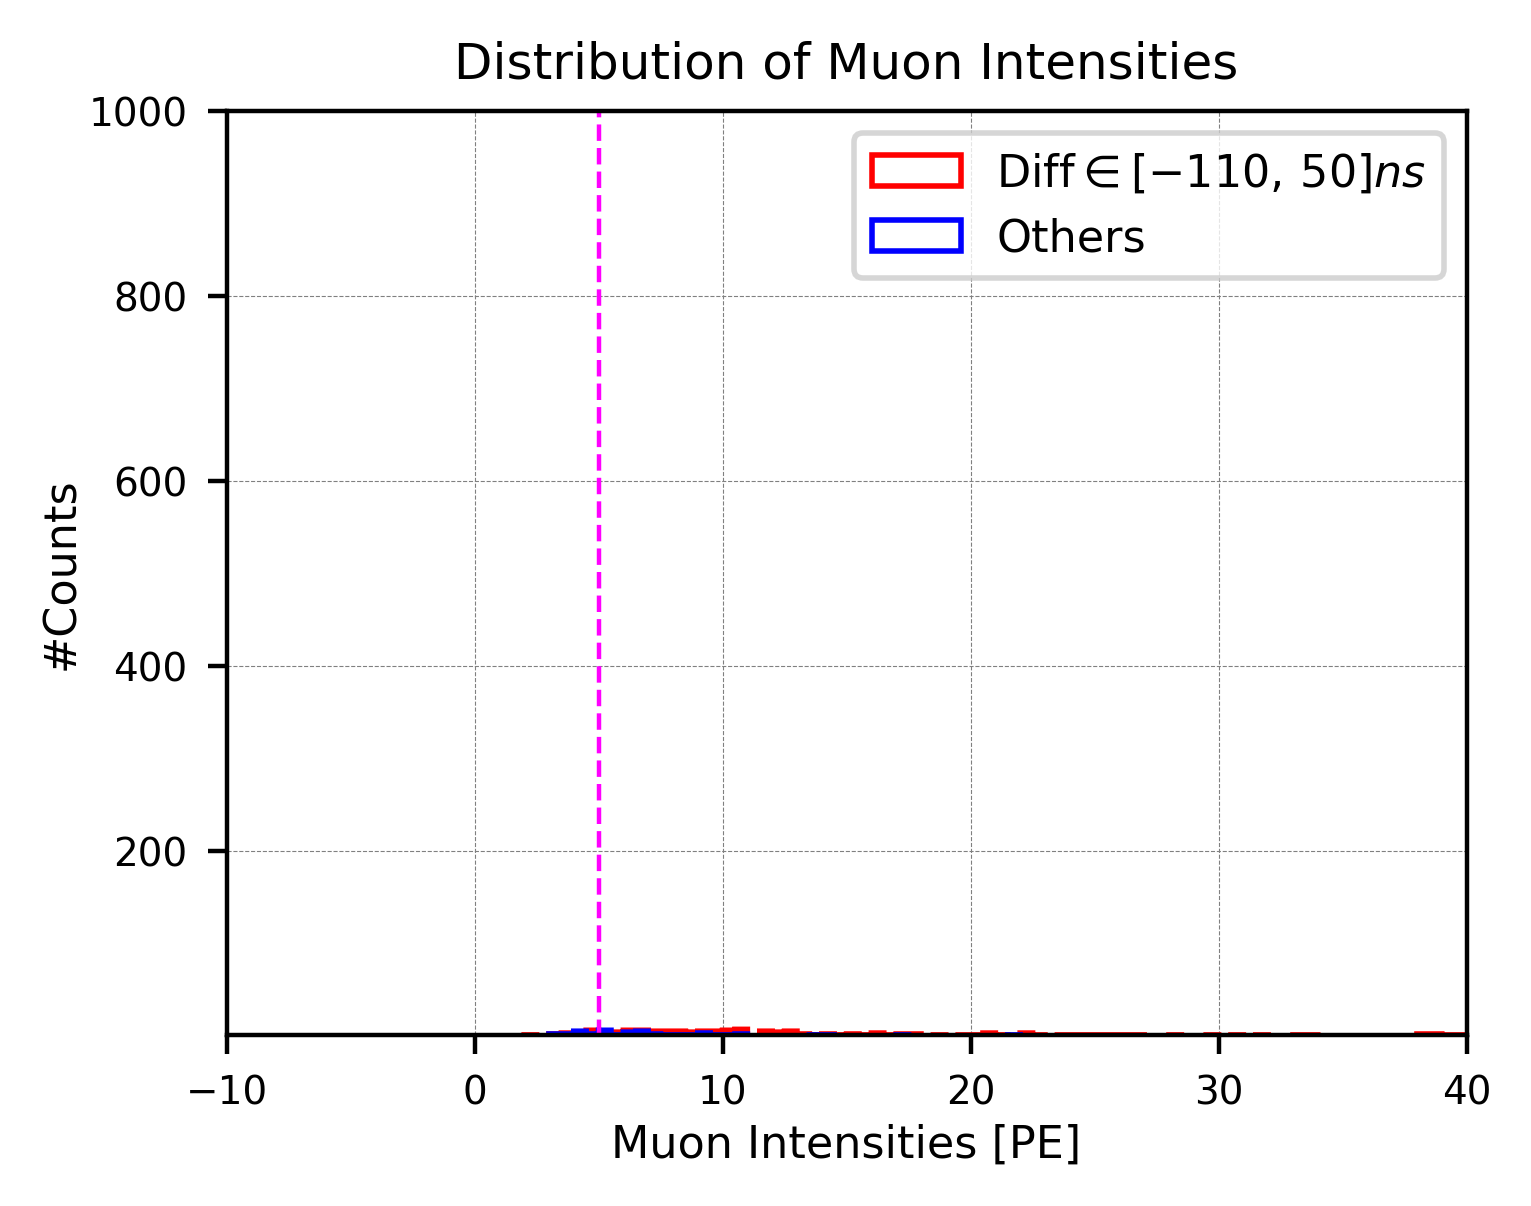

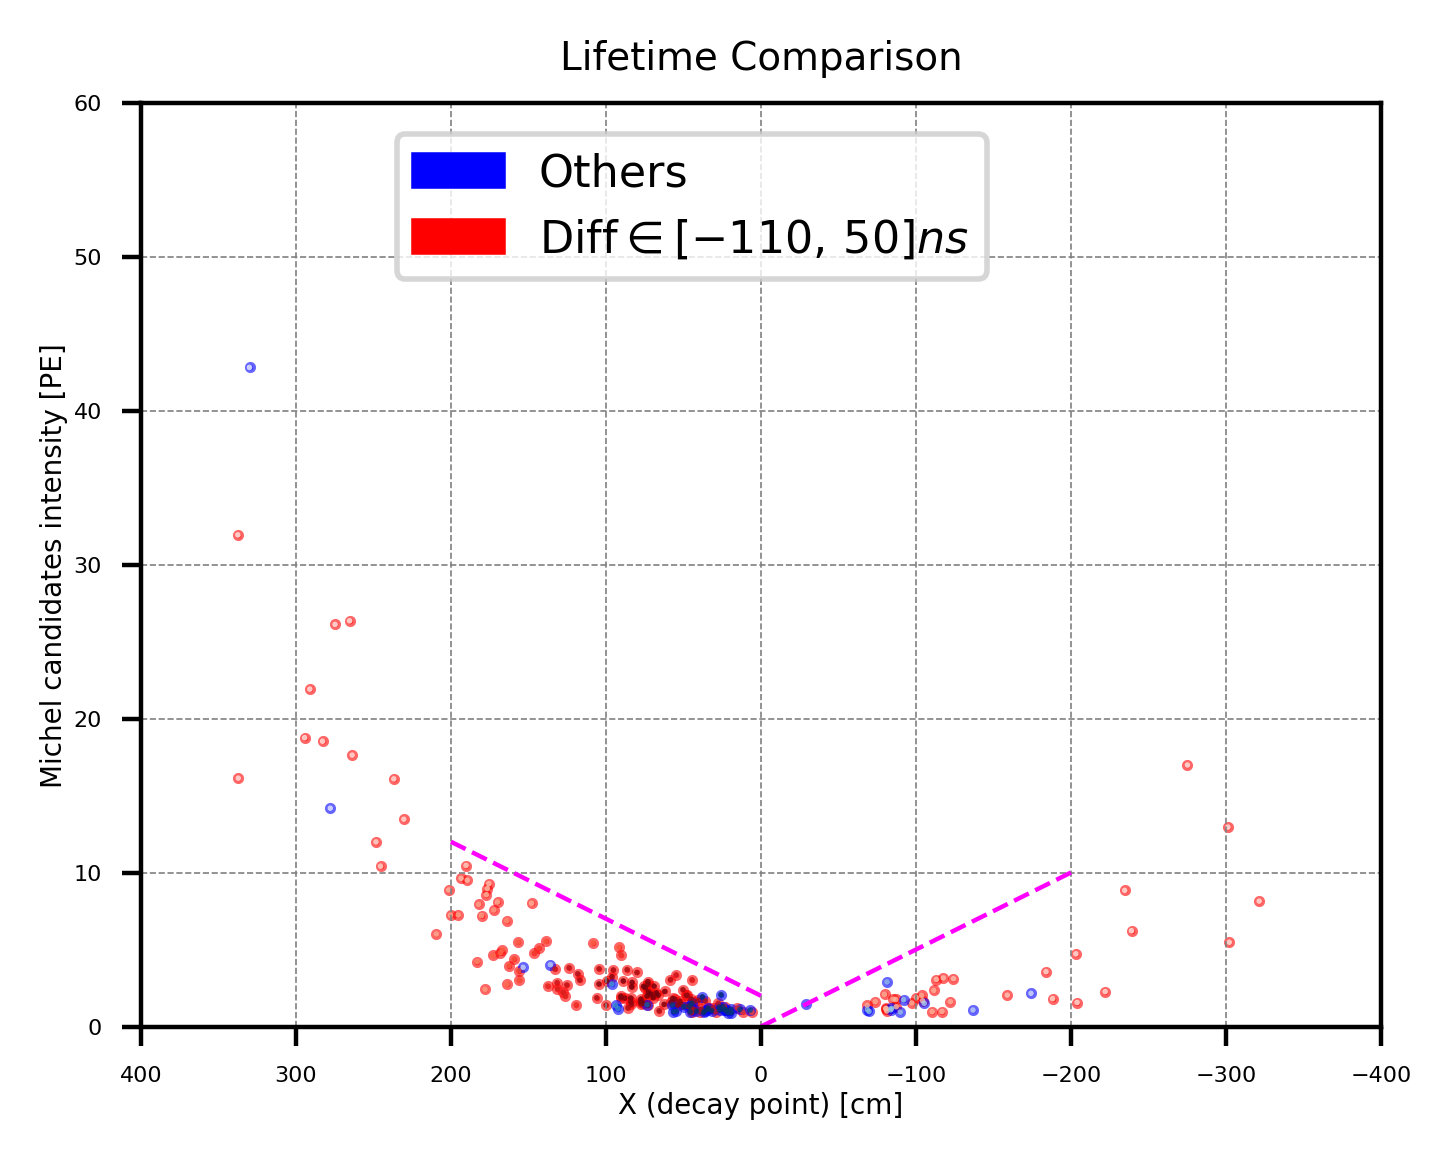

In [12]:
#Muon Intensity distribution===================================

muInt_diff500_purify5 = [ev.muon_intensity for ev in events_diff500_purify5]
muInt_diff0_purify5 = [ev.muon_intensity for ev in events_diff0_purify5]

plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.5
range_min = 0
range_max = 300
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(muInt_diff0_purify5, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.hist(muInt_diff500_purify5, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")

plt.plot([5, 5], [0, 1000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-10, 40)
plt.xlabel('Muon Intensities [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Muon Intensities', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 





#Michel Intensity VS x axis================================
plt.figure(figsize=(4,3), dpi=400)

posX_diff500_purify5 = [ev.posX for ev in events_diff500_purify5]
posX_diff0_purify5 = [ev.posX for ev in events_diff0_purify5]
miInt_diff500_purify5 = [ev.michel_intensity for ev in events_diff500_purify5]
miInt_diff0_purify5 = [ev.michel_intensity for ev in events_diff0_purify5]

# Scatter plot----------
# --- Diff<500 (red group) ---
x0 = np.array(posX_diff0_purify5, dtype=float)
y0 = np.array(miInt_diff0_purify5, dtype=float)
xy0 = np.vstack([x0, y0])
z0 = gaussian_kde(xy0)(xy0)

# --- 500<Diff (blue group) ---
x1 = np.array(posX_diff500_purify5, dtype=float)
y1 = np.array(miInt_diff500_purify5, dtype=float)
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)

# Base layer (solid color so single points are visible)
plt.scatter(x0, y0, s=1, color="red", alpha=0.6, label="_nolegend_")
plt.scatter(x1, y1, s=1, color="blue", alpha=0.6, label="_nolegend_")
# Density layer (adds shading in dense regions)
plt.scatter(x0, y0, c=z0, s=1, cmap="Reds", alpha=0.8, edgecolors="none", label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.scatter(x1, y1, c=z1, s=1, cmap="Blues", alpha=0.8, edgecolors="none", label="Others")
#-----------------------

#slope = 5/100 [PE/cm]
plt.plot([0.0, 200.0], [2, 12], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0.0, -200.0], [0, 10], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(-400, 400)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0, 60)
plt.xlabel('X (decay point) [cm]', labelpad=1, fontsize=5)
plt.ylabel('Michel candidates intensity [PE]', labelpad=1, fontsize=5)
plt.title('Lifetime Comparison', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
red_patch = mpatches.Patch(color="blue", label="Others")
blue_patch = mpatches.Patch(color="red", label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.legend(handles=[red_patch, blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()

#### Cut 5': Michel signal VS Distance cut:

After cut 5:---------
Purity (true / reco)    :  189 / 204 (92.65%)

(Diff [-110, 50]:  158 / 204 (77.45%)
(Diff OTHERS    :  46 / 204 (22.55%)

After Cut 5' (Michel vs Distance):--------------
Efficiency (cut5' / cut5):  203 / 204 (99.51%)
Purity (true / reco)    :  188 / 203 (92.61%)

(Diff [-110, 50]:  158 / 203 (77.83%)
(Diff OTHERS    :  45 / 203 (22.17%)


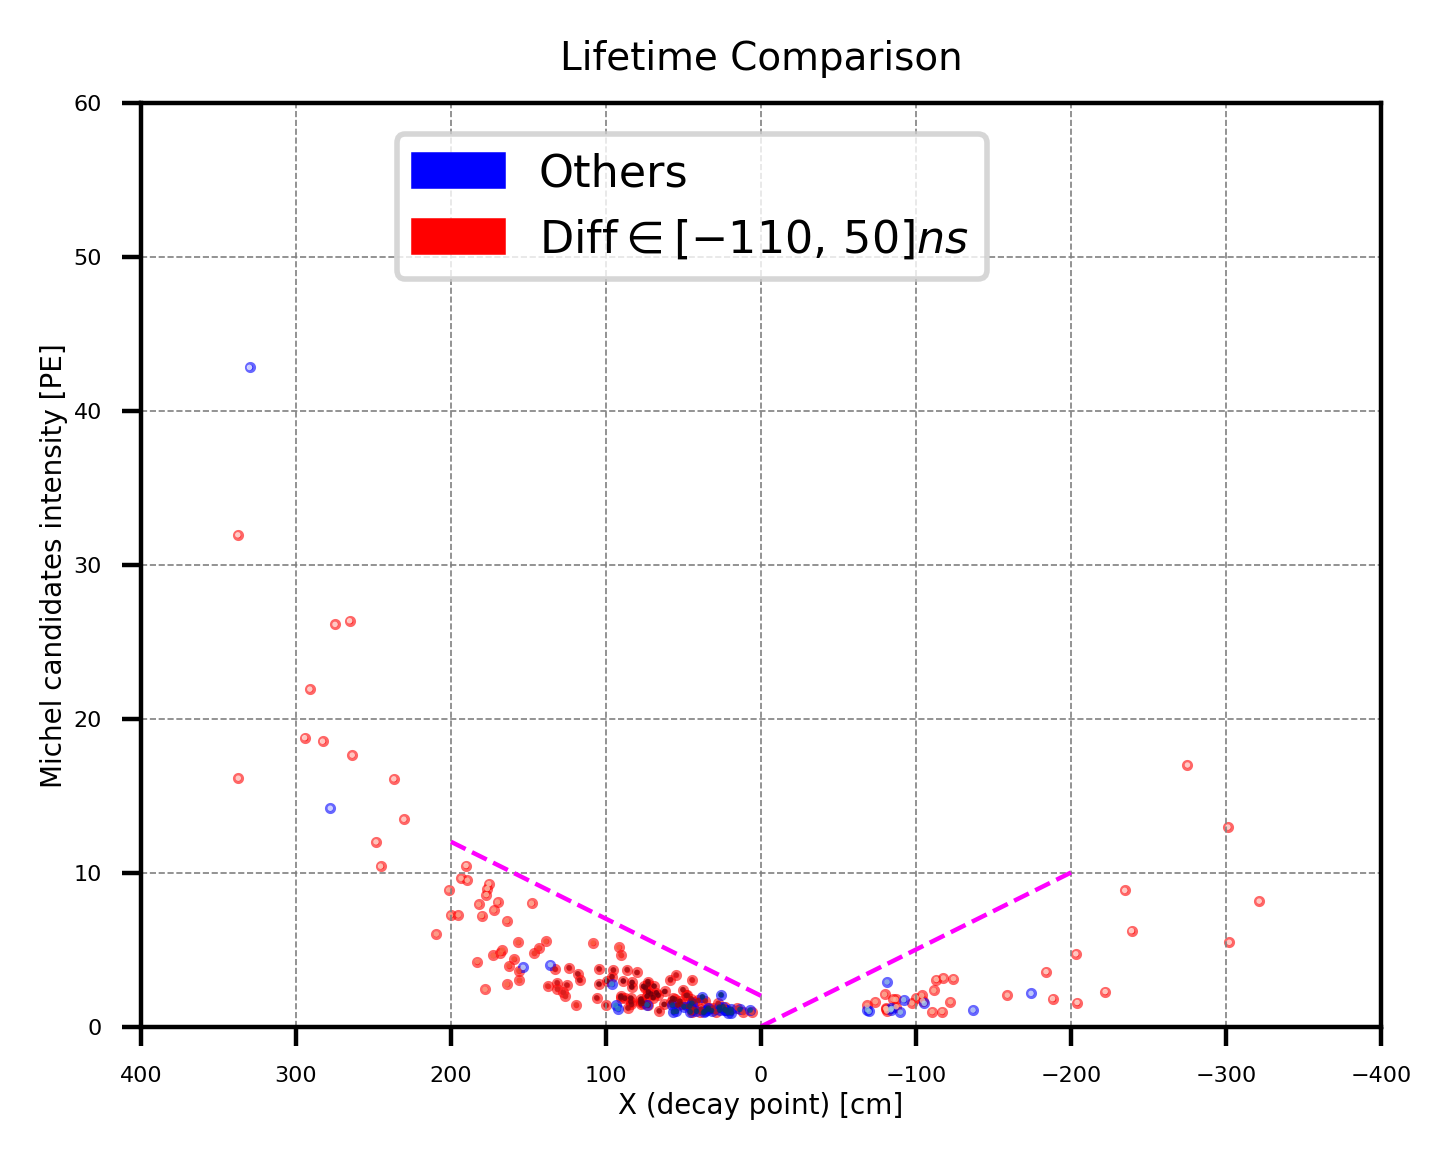

In [14]:
print("After cut 5:---------")

n_valid = sum(1 for ev in events_total_purify5 if ev.energy is not None and ev.energy > 0)
print("Purity (true / reco)    : ", n_valid, "/", len(events_total_purify5),
      "({:.2f}%)".format(n_valid/len(events_total_purify5)*100))

print("\n(Diff [-110, 50]: ", len(events_diff0_purify5), "/", len(events_total_purify5),
       "({:.2f}%)".format(len(events_diff0_purify5)/len(events_total_purify5)*100))
print("(Diff OTHERS    : ", len(events_diff500_purify5), "/", len(events_total_purify5),
       "({:.2f}%)".format(len(events_diff500_purify5)/len(events_total_purify5)*100))


#Michel Peak rise & drop Cut (Cut 5')--------
# --- Define slopes and intercepts for both cuts ---
slope_pos = (7 - 2) / 100.0      # = 0.05
intercept_pos = 2.0

slope_neg = (10 - 0) / (-200 - 0.0)  # = -0.05
intercept_neg = 0.0

def below_line_cut(ev):
    """Return True if event passes both (posX, michel_intensity) cuts."""
    x = ev.posX
    y = ev.michel_intensity

    # Region 1: positive side [0, 100]
    if 0 <= x <= 200:
        return y <= intercept_pos + slope_pos * x

    # Region 2: negative side [-200, 0]
    elif -200 <= x <= 0:
        return y <= intercept_neg + slope_neg * x

    # Outside both ranges: no cut
    else:
        return True

# --- Apply the geometric cut to both event classes ---
events_diff0_purify5P = [ev for ev in events_diff0_purify5 if below_line_cut(ev)]
events_diff500_purify5P = [ev for ev in events_diff500_purify5 if below_line_cut(ev)]
#-------------------------------





print("\nAfter Cut 5' (Michel vs Distance):--------------")

events_total_purify5P = events_diff0_purify5P + events_diff500_purify5P

print("Efficiency (cut5' / cut5): ", len(events_total_purify5P), "/", len(events_total_purify5),
      "({:.2f}%)".format(len(events_total_purify5P)/len(events_total_purify5)*100))

n_valid = sum(1 for ev in events_total_purify5P if ev.energy is not None and ev.energy > 0)
print("Purity (true / reco)    : ", n_valid, "/", len(events_total_purify5P),
      "({:.2f}%)".format(n_valid/len(events_total_purify5P)*100))

print("\n(Diff [-110, 50]: ", len(events_diff0_purify5P), "/", len(events_total_purify5P),
       "({:.2f}%)".format(len(events_diff0_purify5P)/len(events_total_purify5P)*100))
print("(Diff OTHERS    : ", len(events_diff500_purify5P), "/", len(events_total_purify5P),
       "({:.2f}%)".format(len(events_diff500_purify5P)/len(events_total_purify5P)*100))






#Michel Intensity VS x axis================================
plt.figure(figsize=(4,3), dpi=400)

posX_diff500_purify5P = [ev.posX for ev in events_diff500_purify5P]
posX_diff0_purify5P = [ev.posX for ev in events_diff0_purify5P]
miInt_diff500_purify5P = [ev.michel_intensity for ev in events_diff500_purify5P]
miInt_diff0_purify5P = [ev.michel_intensity for ev in events_diff0_purify5P]

# Scatter plot----------
# --- Diff<500 (red group) ---
x0 = np.array(posX_diff0_purify5P, dtype=float)
y0 = np.array(miInt_diff0_purify5P, dtype=float)
xy0 = np.vstack([x0, y0])
z0 = gaussian_kde(xy0)(xy0)

# --- 500<Diff (blue group) ---
x1 = np.array(posX_diff500_purify5P, dtype=float)
y1 = np.array(miInt_diff500_purify5P, dtype=float)
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)

# Base layer (solid color so single points are visible)
plt.scatter(x0, y0, s=1, color="red", alpha=0.6, label="_nolegend_")
plt.scatter(x1, y1, s=1, color="blue", alpha=0.6, label="_nolegend_")
# Density layer (adds shading in dense regions)
plt.scatter(x0, y0, c=z0, s=1, cmap="Reds", alpha=0.8, edgecolors="none", label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.scatter(x1, y1, c=z1, s=1, cmap="Blues", alpha=0.8, edgecolors="none", label="Others")
#-----------------------

#slope = 5/100 [PE/cm]
plt.plot([0.0, 200.0], [2, 12], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0.0, -200.0], [0, 10], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(-400, 400)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0, 60)
plt.xlabel('X (decay point) [cm]', labelpad=1, fontsize=5)
plt.ylabel('Michel candidates intensity [PE]', labelpad=1, fontsize=5)
plt.title('Lifetime Comparison', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
red_patch = mpatches.Patch(color="blue", label="Others")
blue_patch = mpatches.Patch(color="red", label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.legend(handles=[red_patch, blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()





#### Cut 6: Michel peak rise and drop slope: 

After cut 5':---------
Purity (true / reco)    :  188 / 203 (92.61%)

(Diff [-110, 50]:  158 / 203 (77.83%)
(Diff Others    :  45 / 203 (22.17%)

Michel Peak Rise Drop Slope (Cut 6):--------------
Efficiency (cut5 / cut4):  158 / 203 (77.83%)
Purity (true / reco)    :  148 / 158 (93.67%)

(Diff [-110, 50]:  135 / 158 (85.44%)
(Diff OTHERS    :  23 / 158 (14.56%)


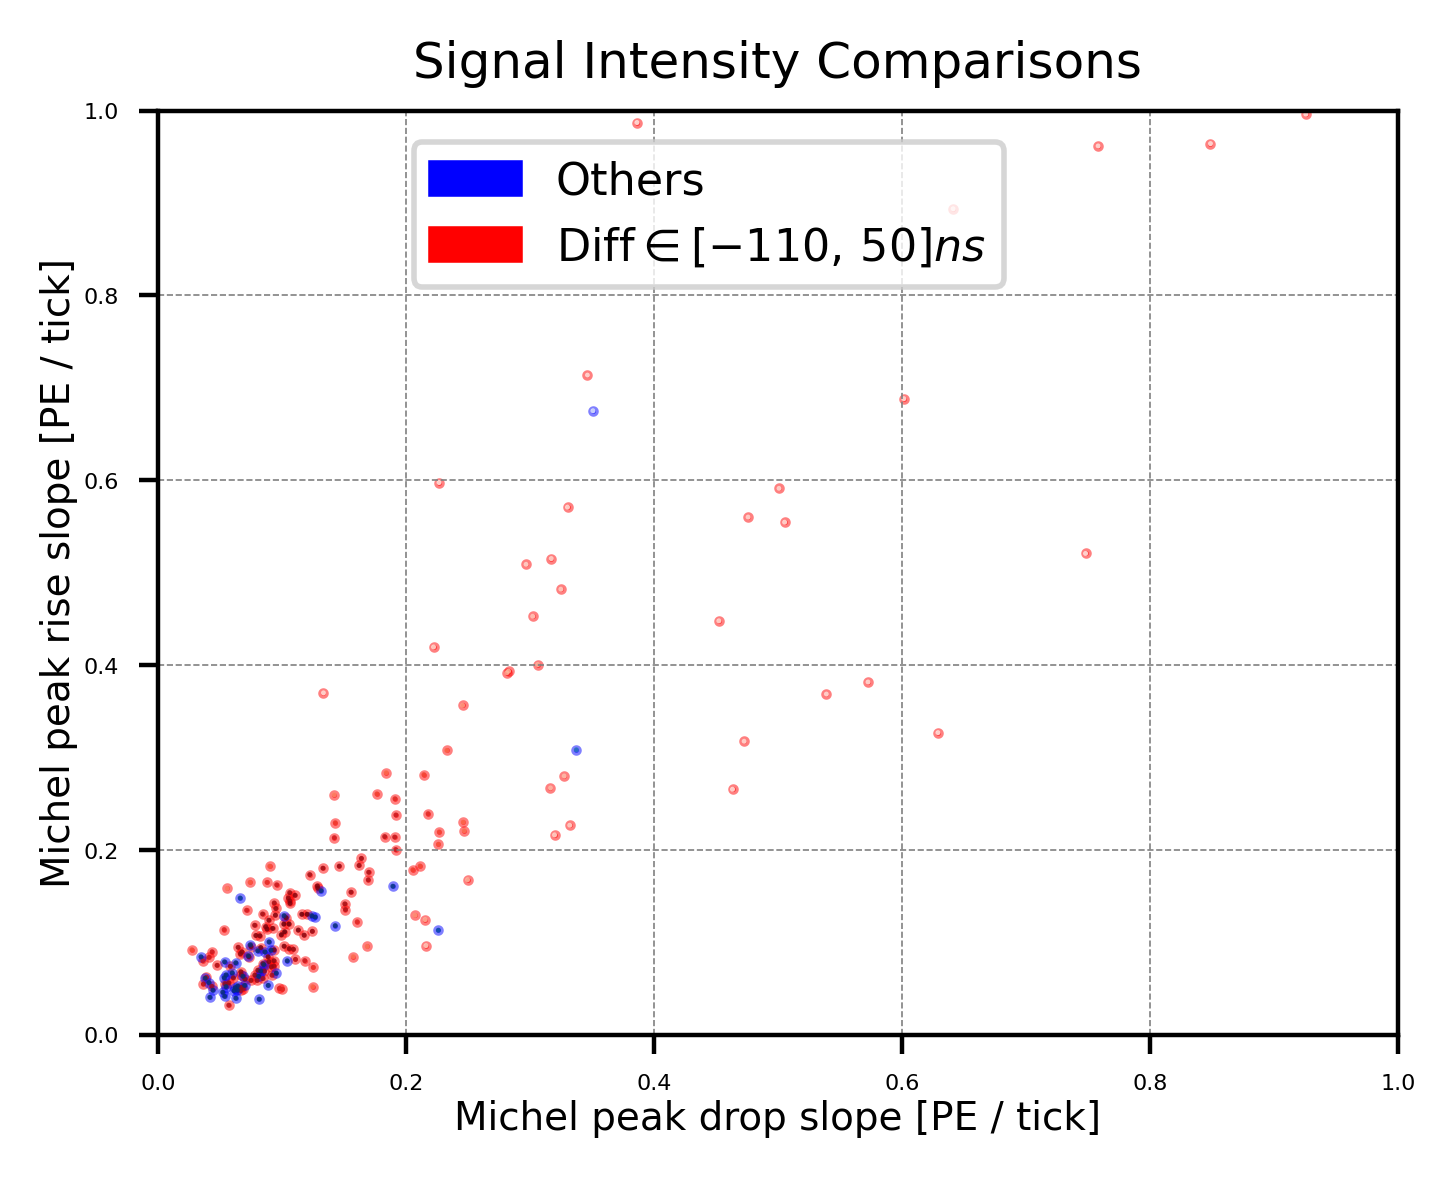

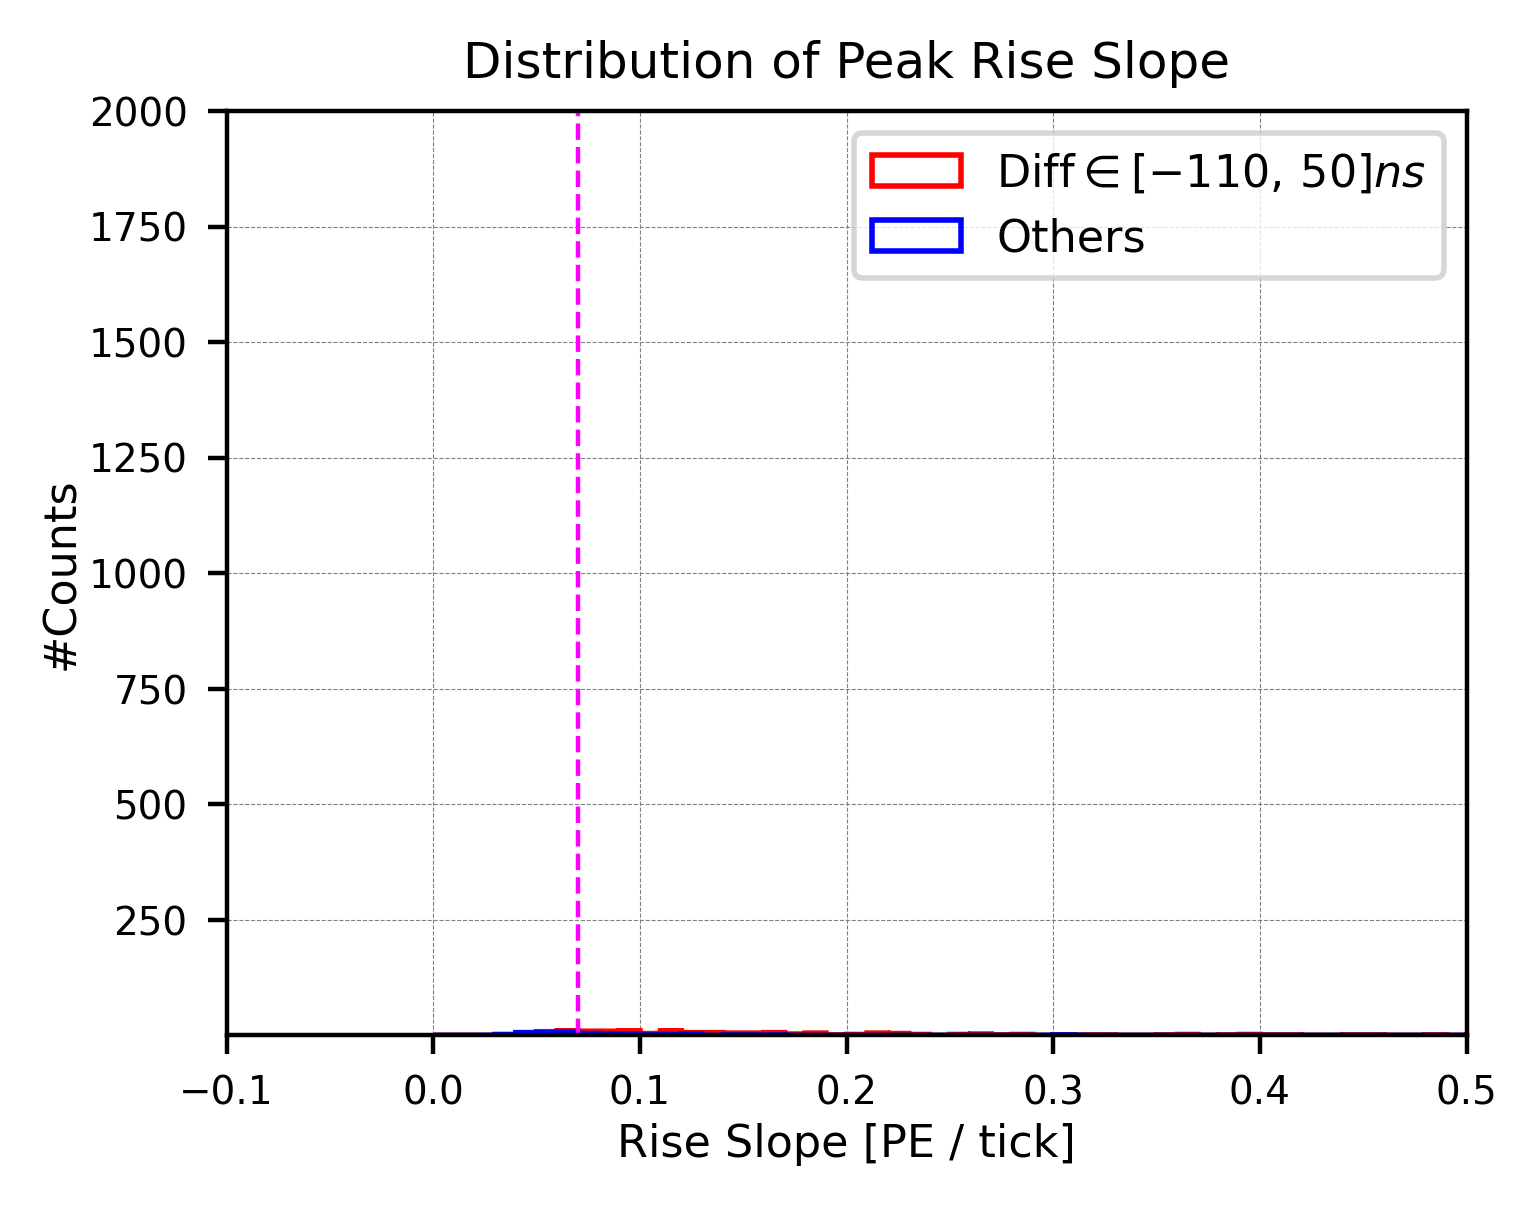

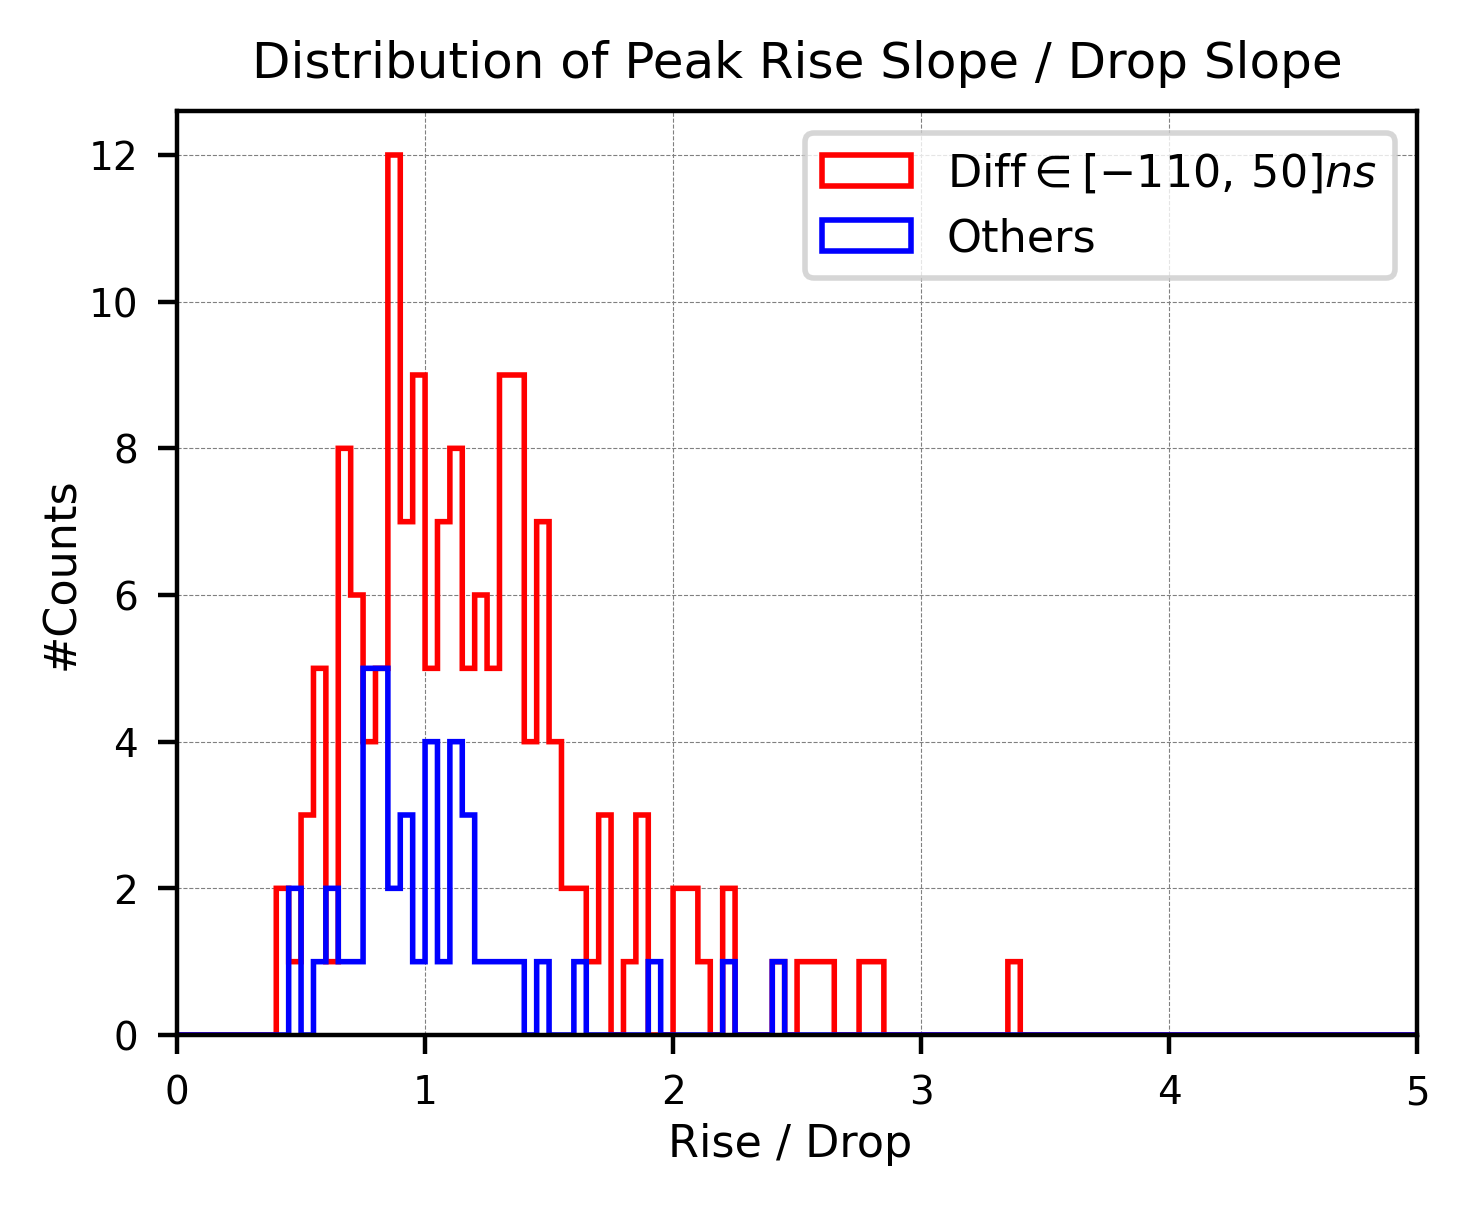

In [16]:
#Michel Peak rise & drop Cut (Cut 6)--------
print("After cut 5':---------")

n_valid = sum(1 for ev in events_total_purify5P if ev.energy is not None and ev.energy > 0)
print("Purity (true / reco)    : ", n_valid, "/", len(events_total_purify5P),
      "({:.2f}%)".format(n_valid/len(events_total_purify5P)*100))

print("\n(Diff [-110, 50]: ", len(events_diff0_purify5P), "/", len(events_total_purify5P),
       "({:.2f}%)".format(len(events_diff0_purify5P)/len(events_total_purify5P)*100))
print("(Diff Others    : ", len(events_diff500_purify5P), "/", len(events_total_purify5P),
       "({:.2f}%)".format(len(events_diff500_purify5P)/len(events_total_purify5P)*100))


rise_diff0_purity5P = [ev.michel_rise for ev in events_diff0_purify5P]
drop_diff0_purity5P = [ev.michel_drop for ev in events_diff0_purify5P]

ratios_diff0_purity5P = [
    r / d if d not in (0, None) else None
    for r, d in zip(rise_diff0_purity5P, drop_diff0_purity5P)
]

rise_diff500_purity5P = [ev.michel_rise for ev in events_diff500_purify5P]
drop_diff500_purity5P = [ev.michel_drop for ev in events_diff500_purify5P]

ratios_diff500_purity5P = [
    r / d if d not in (0, None) else None
    for r, d in zip(rise_diff500_purity5P, drop_diff500_purity5P)
]



thre_rise = 0.07 # mu Int will automatically higher than mi---


# filter the actual events
events_diff0_purify6 = [
    ev for ev in events_diff0_purify5P
    if thre_rise < ev.michel_rise
]
events_diff500_purify6 = [
    ev for ev in events_diff500_purify5P
    if thre_rise < ev.michel_rise 
]
#-------------------------------



print("\nMichel Peak Rise Drop Slope (Cut 6):--------------")

events_total_purify6 = events_diff0_purify6 + events_diff500_purify6

print("Efficiency (cut5 / cut4): ", len(events_total_purify6), "/", len(events_total_purify5P),
      "({:.2f}%)".format(len(events_total_purify6)/len(events_total_purify5P)*100))

n_valid = sum(1 for ev in events_total_purify6 if ev.energy is not None and ev.energy > 0)
print("Purity (true / reco)    : ", n_valid, "/", len(events_total_purify6),
      "({:.2f}%)".format(n_valid/len(events_total_purify6)*100))

print("\n(Diff [-110, 50]: ", len(events_diff0_purify6), "/", len(events_total_purify6),
       "({:.2f}%)".format(len(events_diff0_purify6)/len(events_total_purify6)*100))
print("(Diff OTHERS    : ", len(events_diff500_purify6), "/", len(events_total_purify6),
       "({:.2f}%)".format(len(events_diff500_purify6)/len(events_total_purify6)*100))








# ==========================================================
# Michel Rise VS Michel Drop
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(drop_diff500_purity5P), np.array(rise_diff500_purity5P)
x2, y2 = np.array(drop_diff0_purity5P), np.array(rise_diff0_purity5P)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Density for group 2 (blue, 0<Diff<500) ---
xy2 = np.vstack([x2, y2])
z2 = gaussian_kde(xy2)(xy2)
idx2 = z2.argsort()
x2, y2, z2 = x2[idx2], y2[idx2], z2[idx2]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x2, y2, s=0.8, color="red", alpha=0.5, label="_nolegend_")
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x2, y2, c=z2, s=0.8, cmap="Reds", alpha=0.8, edgecolors="none", label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Others")


#---------------------------------

#plt.plot([0, 500], [0, 40], color="magenta", linewidth=0.8, linestyle='--')
#plt.plot([0, 1000], [0, 500], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('Michel peak drop slope [PE / tick]', labelpad=1, fontsize=7)
plt.ylabel('Michel peak rise slope [PE / tick]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
red_patch = mpatches.Patch(color="blue", label="Others")
blue_patch = mpatches.Patch(color="red", label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.legend(handles=[red_patch, blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()





#Michel Rise Distributions===================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.01
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(rise_diff0_purity5P, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.hist(rise_diff500_purity5P, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")

plt.plot([0.07, 0.07], [0, 2000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.1, 0.5)
plt.xlabel('Rise Slope [PE / tick]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 2000)
#plt.xscale('log')
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Peak Rise Slope', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  





#Michel Rise & Drop Distributions===================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

#plt.hist(drop_diff0_purity1, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
#         histtype='step', linewidth=1.0, label="Drop for Diff0")
#plt.hist(drop_diff500_purity1, bins=bins, range=(range_min, range_max), edgecolor='green', 
#         histtype='step', linewidth=1.0, label="Drop for Diff500")
plt.hist(ratios_diff0_purity5P, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.hist(ratios_diff500_purity5P, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")


plt.xlim(0, 5)
plt.xlabel('Rise / Drop ', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.9, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Peak Rise Slope / Drop Slope', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 







#Apply Cut======================================




### Cut 7: 2nd 3rd peak intensity diff cut

After cut 6:---------
Purity (true / reco)    :  148 / 158 (93.67%)

(Diff [-110, 50]:  135 / 158 (85.44%)
(Diff OTHERS    :  23 / 158 (14.56%)

Third / Second peak intensity (Cut 7):--------------
Efficiency (cut7 / cut6):  131 / 158 (82.91%)
Purity (true / reco)    :  123 / 131 (93.89%)

(Diff [-110, 50]:  118 / 131 (90.08%)
(Diff OTHERS    :  13 / 131 (9.92%)


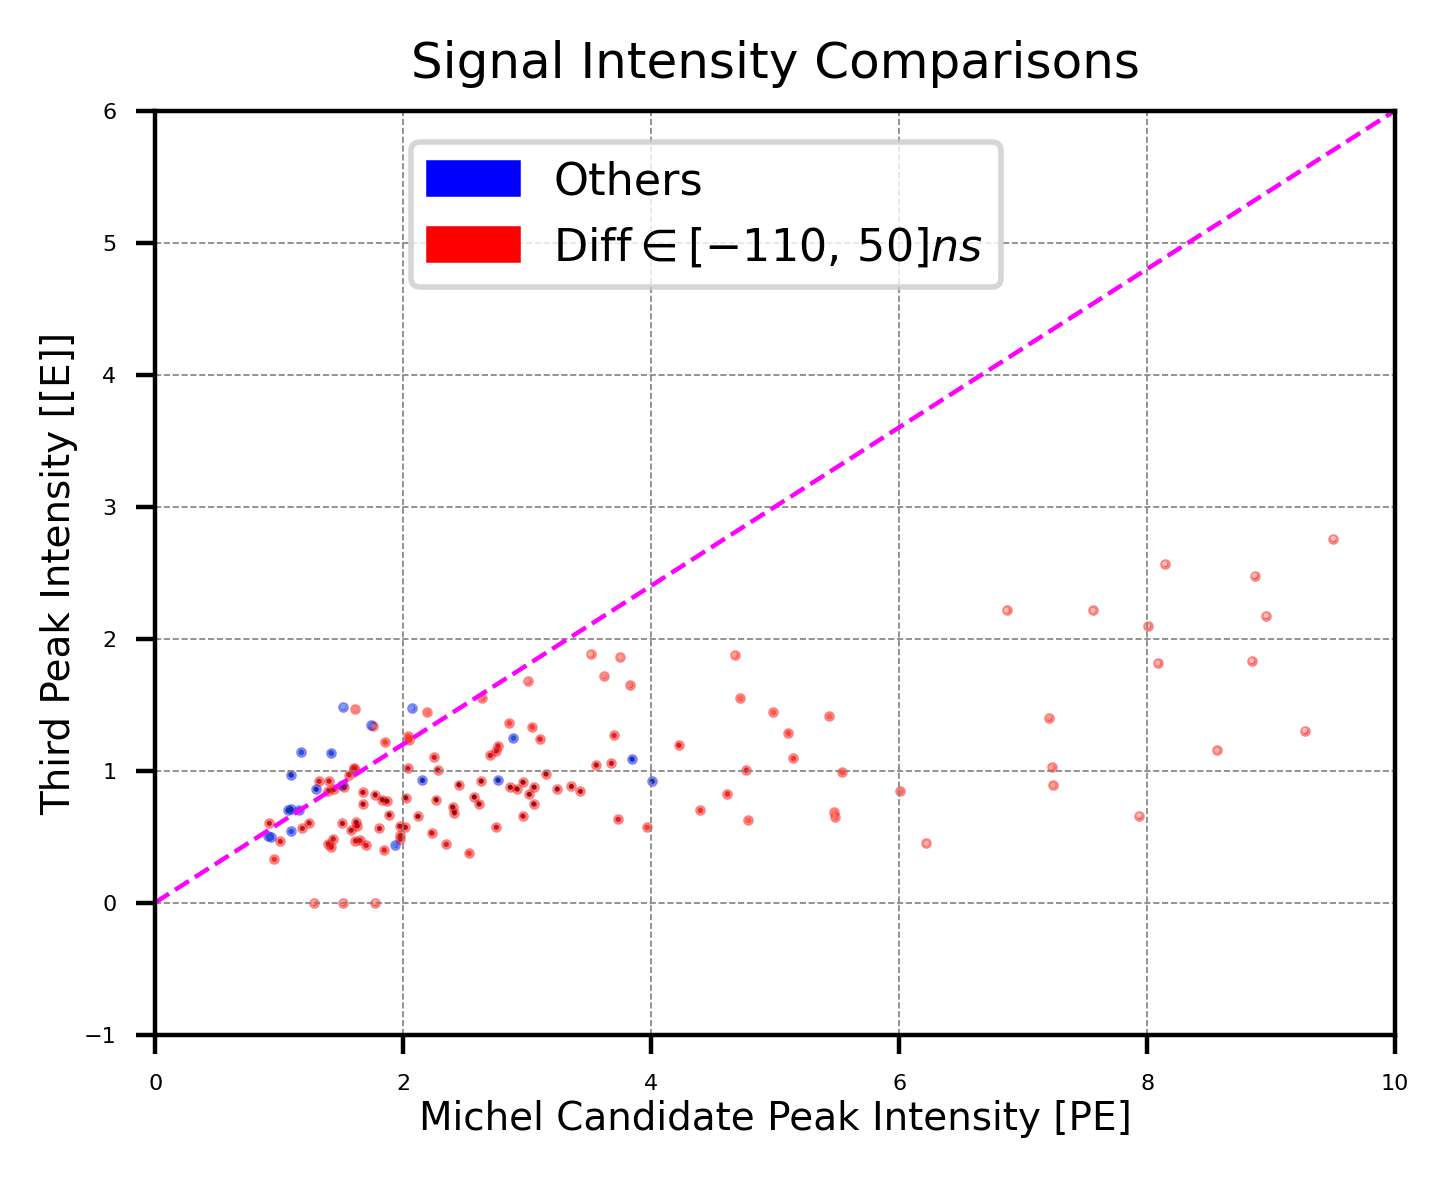

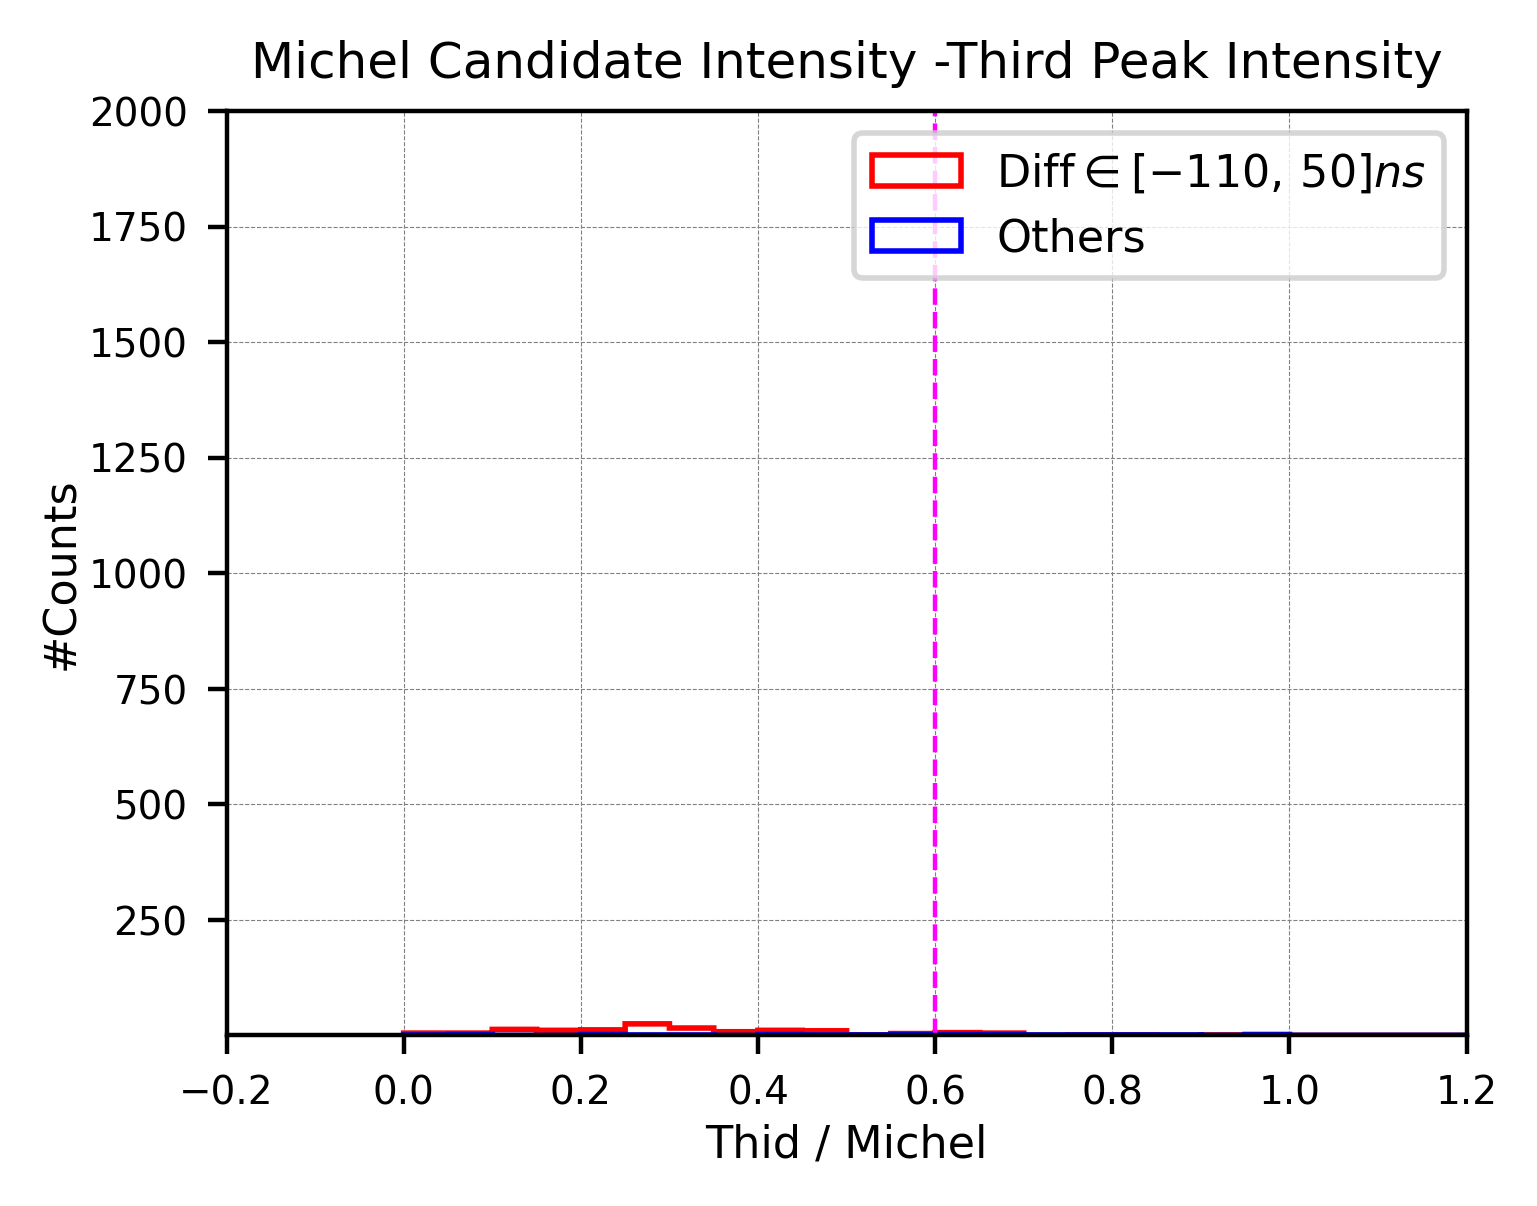

In [18]:
#Michel Peak rise & drop Cut (Cut 6)--------
print("After cut 6:---------")

n_valid = sum(1 for ev in events_total_purify6 if ev.energy is not None and ev.energy > 0)
print("Purity (true / reco)    : ", n_valid, "/", len(events_total_purify6),
      "({:.2f}%)".format(n_valid/len(events_total_purify6)*100))

print("\n(Diff [-110, 50]: ", len(events_diff0_purify6), "/", len(events_total_purify6),
       "({:.2f}%)".format(len(events_diff0_purify6)/len(events_total_purify6)*100))
print("(Diff OTHERS    : ", len(events_diff500_purify6), "/", len(events_total_purify6),
       "({:.2f}%)".format(len(events_diff500_purify6)/len(events_total_purify6)*100))



miInt_diff0_purity6 = [ev.michel_intensity for ev in events_diff0_purify6]
thInt_diff0_purity6 = [ev.third_intensity for ev in events_diff0_purify6]

miInt_diff500_purity6 = [ev.michel_intensity for ev in events_diff500_purify6]
thInt_diff500_purity6 = [ev.third_intensity for ev in events_diff500_purify6]



# Element-by-element ratio (thInt / miInt)
ratio_diff0_purity6 = [th / mi for th, mi in zip(thInt_diff0_purity6, miInt_diff0_purity6)]
ratio_diff500_purity6 = [th / mi for th, mi in zip(thInt_diff500_purity6, miInt_diff500_purity6)]


thre1 = 0.0
thre2 = 0.6

# filter the actual events
events_diff0_purify7 = [
    ev for ev in events_diff0_purify6
    if ev.michel_intensity != 0 and thre1 < ev.third_intensity / ev.michel_intensity < thre2
]
events_diff500_purify7 = [
    ev for ev in events_diff500_purify6
    if ev.michel_intensity != 0 and thre1 < ev.third_intensity / ev.michel_intensity < thre2
]
#-------------------------------


print("\nThird / Second peak intensity (Cut 7):--------------")

events_total_purify7 = events_diff0_purify7 + events_diff500_purify7

print("Efficiency (cut7 / cut6): ", len(events_total_purify7), "/", len(events_total_purify6),
      "({:.2f}%)".format(len(events_total_purify7)/len(events_total_purify6)*100))

n_valid = sum(1 for ev in events_total_purify7 if ev.energy is not None and ev.energy > 0)
print("Purity (true / reco)    : ", n_valid, "/", len(events_total_purify7),
      "({:.2f}%)".format(n_valid/len(events_total_purify7)*100))

print("\n(Diff [-110, 50]: ", len(events_diff0_purify7), "/", len(events_total_purify7),
       "({:.2f}%)".format(len(events_diff0_purify7)/len(events_total_purify7)*100))
print("(Diff OTHERS    : ", len(events_diff500_purify7), "/", len(events_total_purify7),
       "({:.2f}%)".format(len(events_diff500_purify7)/len(events_total_purify7)*100))








# ==========================================================
# Michel Int VS Third Int
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(miInt_diff500_purity6), np.array(thInt_diff500_purity6) #(x, y)
x2, y2 = np.array(miInt_diff0_purity6), np.array(thInt_diff0_purity6)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Density for group 2 (blue, 0<Diff<500) ---
xy2 = np.vstack([x2, y2])
z2 = gaussian_kde(xy2)(xy2)
idx2 = z2.argsort()
x2, y2, z2 = x2[idx2], y2[idx2], z2[idx2]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x2, y2, s=0.8, color="red", alpha=0.5, label="_nolegend_")
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x2, y2, c=z2, s=0.8, cmap="Reds", alpha=0.8, edgecolors="none", label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Others")
#---------------------------------

#plt.plot([0, 500], [0, 40], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0, 100], [0, 60], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 10)
plt.ylim(-1, 6)
plt.xlabel('Michel Candidate Peak Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Third Peak Intensity [[E]]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
red_patch = mpatches.Patch(color="blue", label="Others")
blue_patch = mpatches.Patch(color="red", label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.legend(handles=[red_patch, blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()






#Third / Michel Distributions===================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(ratio_diff0_purity6, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.hist(ratio_diff500_purity6, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")

plt.plot([0.6, 0.6], [0, 2000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.2, 1.2)
plt.xlabel('Thid / Michel', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 2000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Michel Candidate Intensity -Third Peak Intensity', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 

### Cut 8: Third second peak intensity ratio cut


After Cut 7:--------------
Purity (true / reco)    :  123 / 131 (93.89%)

(Diff [-110, 50]:  118 / 131 (90.08%)
(Diff OTHERS    :  13 / 131 (9.92%)

Michel 3rd Peaks intensity Diff (Cut 8):--------------
Efficiency (cut8 / cut7):  121 / 131 (92.37%)
Purity (true / reco)    :  114 / 121 (94.21%)

(Diff [-110, 50]:  112 / 121 (92.56%)
(Diff OTHERS    :  9 / 121 (7.44%)


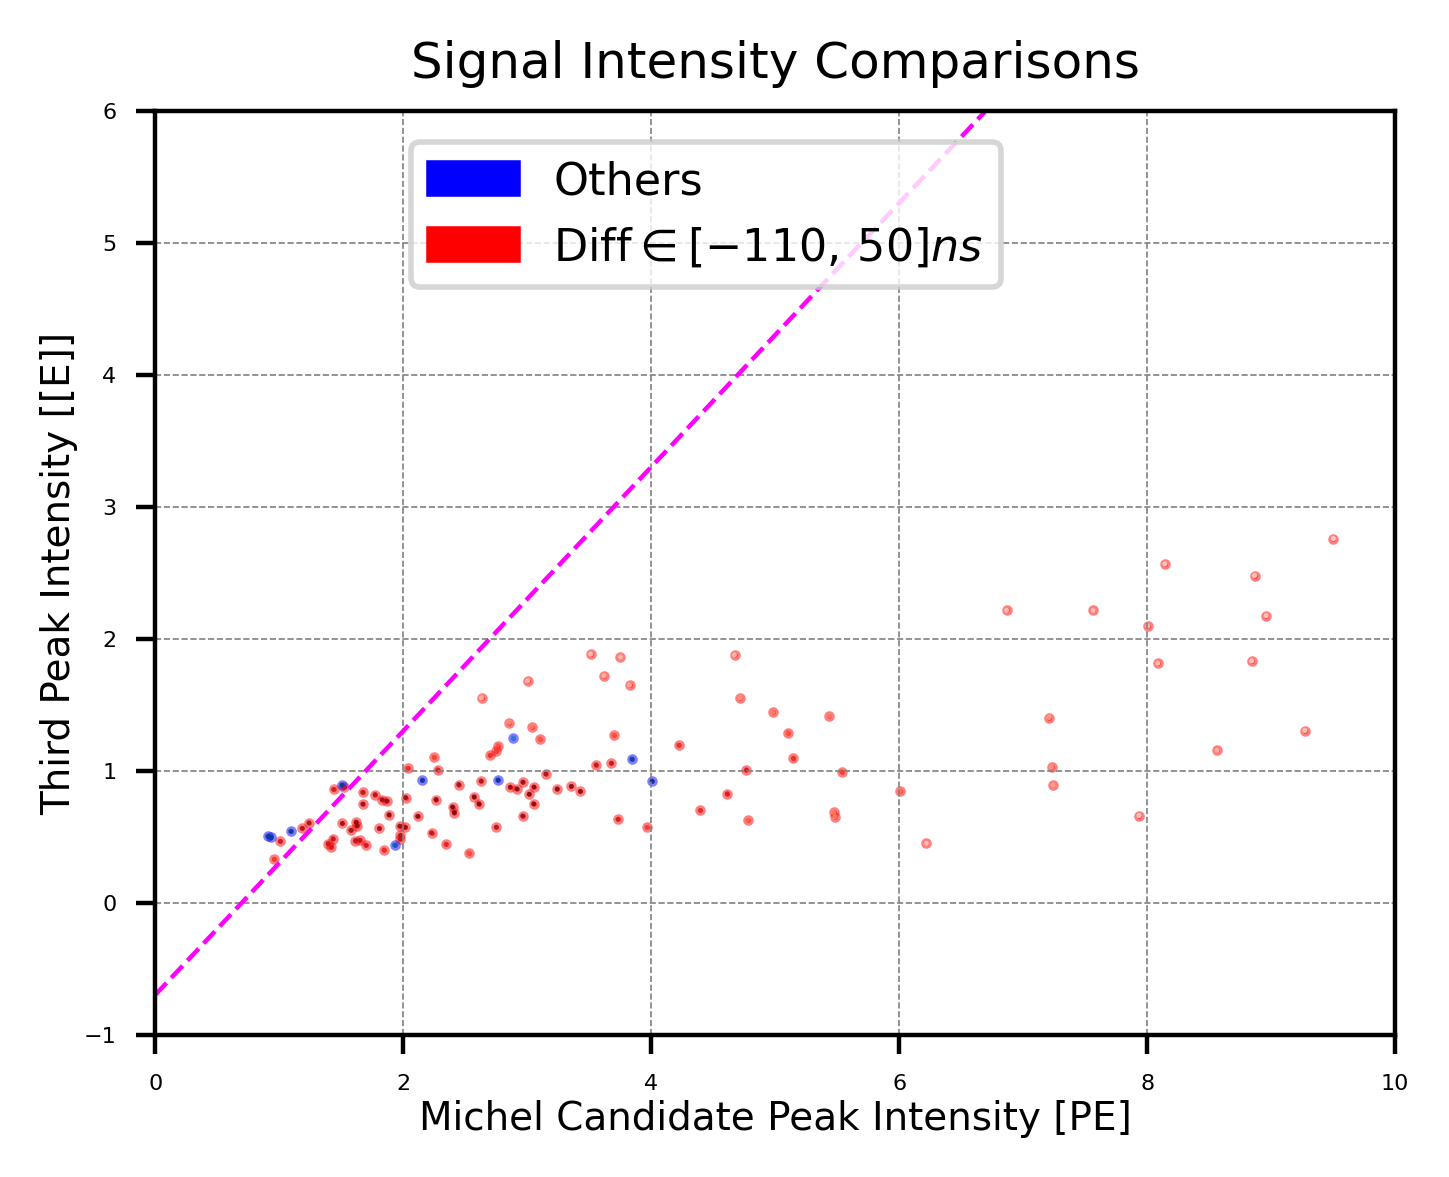

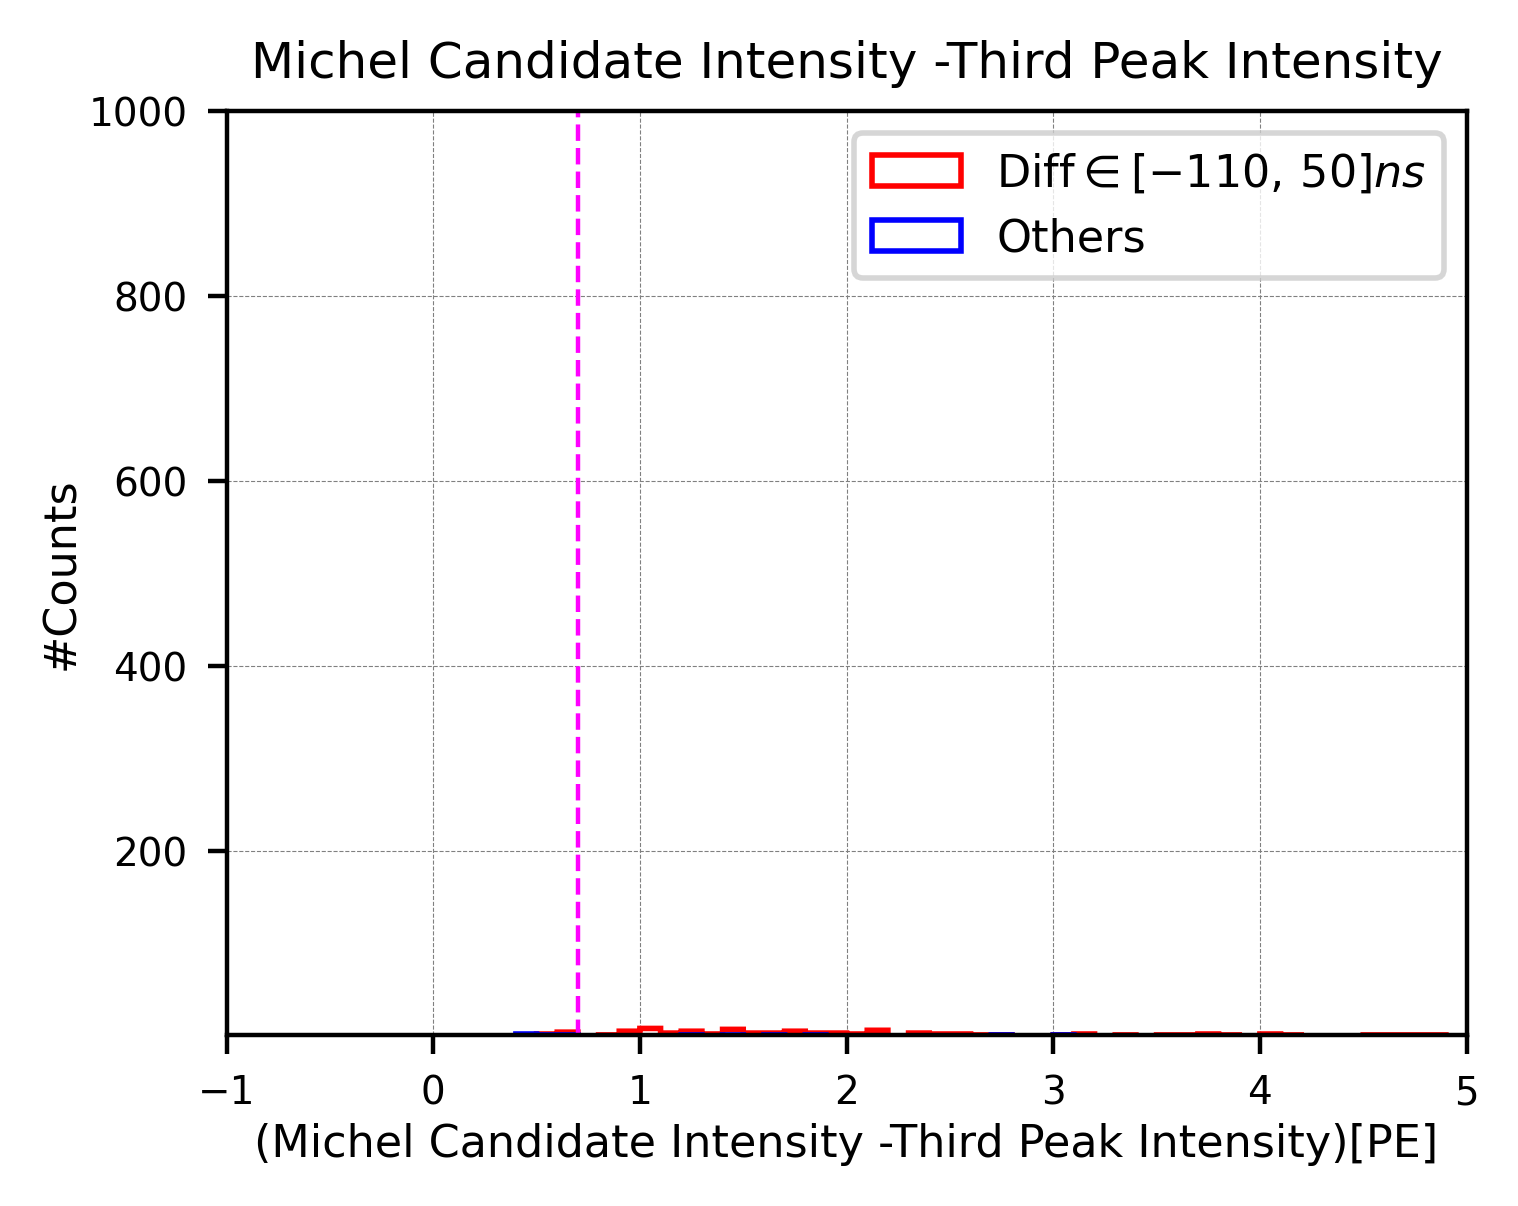

In [19]:
print("\nAfter Cut 7:--------------")

n_valid = sum(1 for ev in events_total_purify7 if ev.energy is not None and ev.energy > 0)
print("Purity (true / reco)    : ", n_valid, "/", len(events_total_purify7),
      "({:.2f}%)".format(n_valid/len(events_total_purify7)*100))

print("\n(Diff [-110, 50]: ", len(events_diff0_purify7), "/", len(events_total_purify7),
       "({:.2f}%)".format(len(events_diff0_purify7)/len(events_total_purify7)*100))
print("(Diff OTHERS    : ", len(events_diff500_purify7), "/", len(events_total_purify7),
       "({:.2f}%)".format(len(events_diff500_purify7)/len(events_total_purify7)*100))


miInt_diff0_purity7 = [ev.michel_intensity for ev in events_diff0_purify7]
thInt_diff0_purity7 = [ev.third_intensity for ev in events_diff0_purify7]

miInt_diff500_purity7 = [ev.michel_intensity for ev in events_diff500_purify7]
thInt_diff500_purity7 = [ev.third_intensity for ev in events_diff500_purify7]

# Element-by-element difference (thInt - miInt)
subtract_diff0_purity7 = [mi - th for th, mi in zip(thInt_diff0_purity7, miInt_diff0_purity7)]
subtract_diff500_purity7 = [mi - th for th, mi in zip(thInt_diff500_purity7, miInt_diff500_purity7)]


thre_diff = 0.7

# filter the actual events
events_diff0_purify8 = [
    ev for ev in events_diff0_purify7
    if thre_diff <  (ev.michel_intensity - ev.third_intensity)
]
events_diff500_purify8 = [
    ev for ev in events_diff500_purify7
    if thre_diff <  (ev.michel_intensity - ev.third_intensity)
]
#-------------------------------


print("\nMichel 3rd Peaks intensity Diff (Cut 8):--------------")

events_total_purify8 = events_diff0_purify8 + events_diff500_purify8

print("Efficiency (cut8 / cut7): ", len(events_total_purify8), "/", len(events_total_purify7),
      "({:.2f}%)".format(len(events_total_purify8)/len(events_total_purify7)*100))

n_valid = sum(1 for ev in events_total_purify8 if ev.energy is not None and ev.energy > 0)
print("Purity (true / reco)    : ", n_valid, "/", len(events_total_purify8),
      "({:.2f}%)".format(n_valid/len(events_total_purify8)*100))

print("\n(Diff [-110, 50]: ", len(events_diff0_purify8), "/", len(events_total_purify8),
       "({:.2f}%)".format(len(events_diff0_purify8)/len(events_total_purify8)*100))
print("(Diff OTHERS    : ", len(events_diff500_purify8), "/", len(events_total_purify8),
       "({:.2f}%)".format(len(events_diff500_purify8)/len(events_total_purify8)*100))










# ==========================================================
# Michel Int VS Third Int
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(miInt_diff500_purity7), np.array(thInt_diff500_purity7) #(x, y)
x2, y2 = np.array(miInt_diff0_purity7), np.array(thInt_diff0_purity7)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Density for group 2 (blue, 0<Diff<500) ---
xy2 = np.vstack([x2, y2])
z2 = gaussian_kde(xy2)(xy2)
idx2 = z2.argsort()
x2, y2, z2 = x2[idx2], y2[idx2], z2[idx2]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x2, y2, s=0.8, color="red", alpha=0.5, label="_nolegend_")
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x2, y2, c=z2, s=0.8, cmap="Reds", alpha=0.8, edgecolors="none", label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Others")
#---------------------------------

plt.plot([0, 10], [-0.7, 9.3], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 10)
plt.ylim(-1, 6)
plt.xlabel('Michel Candidate Peak Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Third Peak Intensity [[E]]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
red_patch = mpatches.Patch(color="blue", label="Others")
blue_patch = mpatches.Patch(color="red", label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.legend(handles=[red_patch, blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()









#(Michel Candidate Intensity -Third Peak Intensity) Distributions====================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(subtract_diff0_purity7, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.hist(subtract_diff500_purity7, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")

plt.plot([0.7, 0.7], [0, 1000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-1, 5)
plt.xlabel('(Michel Candidate Intensity -Third Peak Intensity)[PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Michel Candidate Intensity -Third Peak Intensity', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  

### Cut 9: Space Cut along drift direction


After Cut 8:--------------
Purity (true / reco)    :  114 / 121 (94.21%)

(Diff [-110, 50]:  112 / 121 (92.56%)
(Diff OTHERS    :  9 / 121 (7.44%)

Drift Direction Cut (Cut 9):--------------
Efficiency (cut9 / cut8):  119 / 121 (98.35%)
Purity (true / reco)    :  113 / 119 (94.96%)

(Diff [-110, 50]:  111 / 119 (93.28%)
(Diff OTHERS    :  8 / 119 (6.72%)

Decay points distribution: 


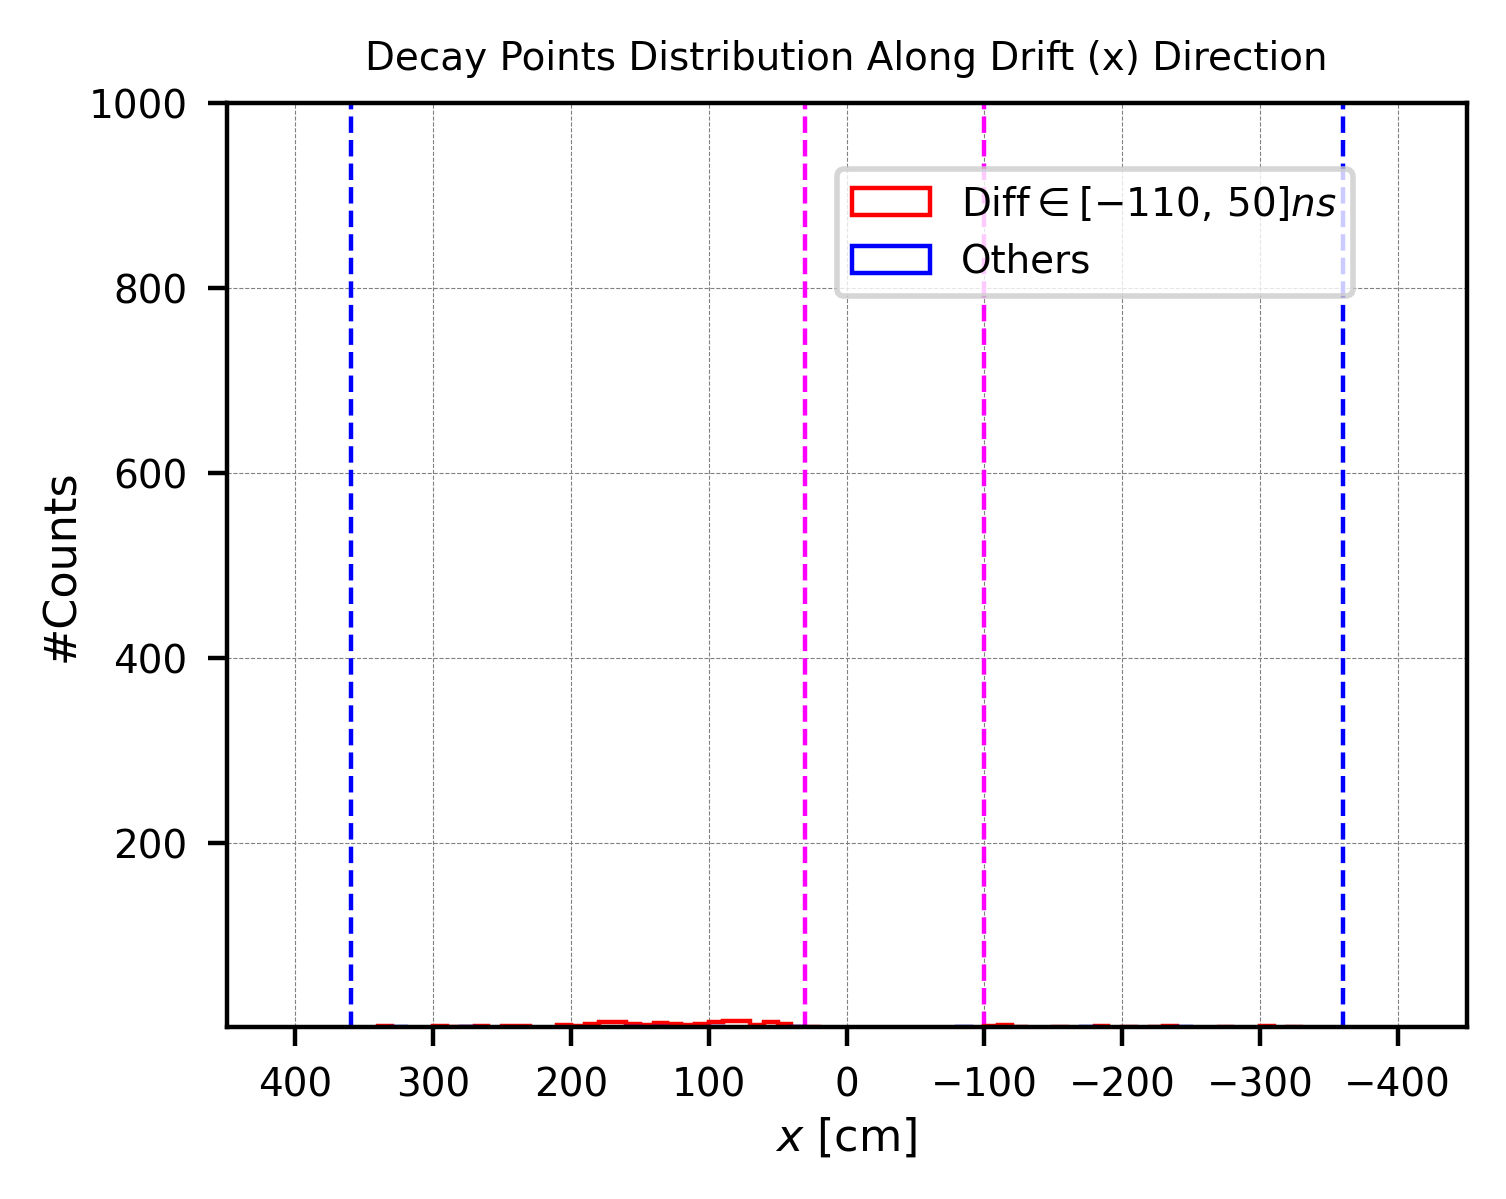

In [20]:
print("\nAfter Cut 8:--------------")

n_valid = sum(1 for ev in events_total_purify8 if ev.energy is not None and ev.energy > 0)
print("Purity (true / reco)    : ", n_valid, "/", len(events_total_purify8),
      "({:.2f}%)".format(n_valid/len(events_total_purify8)*100))

print("\n(Diff [-110, 50]: ", len(events_diff0_purify8), "/", len(events_total_purify8),
       "({:.2f}%)".format(len(events_diff0_purify8)/len(events_total_purify8)*100))
print("(Diff OTHERS    : ", len(events_diff500_purify8), "/", len(events_total_purify8),
       "({:.2f}%)".format(len(events_diff500_purify8)/len(events_total_purify8)*100))





posX_cut = 30
negX_cut = -100

# filter the actual events
events_diff0_purify9 = [
    ev for ev in events_diff0_purify8
    if posX_cut < ev.posX  or  ev.posX < negX_cut
]
events_diff500_purify9 = [
    ev for ev in events_diff500_purify8
    if posX_cut < ev.posX  or  ev.posX < negX_cut
]
#-------------------------------


print("\nDrift Direction Cut (Cut 9):--------------")

events_total_purify9 = events_diff0_purify9 + events_diff500_purify9

print("Efficiency (cut9 / cut8): ", len(events_total_purify9), "/", len(events_total_purify8),
      "({:.2f}%)".format(len(events_total_purify9)/len(events_total_purify8)*100))

n_valid = sum(1 for ev in events_total_purify9 if ev.energy is not None and ev.energy > 0)
print("Purity (true / reco)    : ", n_valid, "/", len(events_total_purify9),
      "({:.2f}%)".format(n_valid/len(events_total_purify9)*100))

print("\n(Diff [-110, 50]: ", len(events_diff0_purify9), "/", len(events_total_purify9),
       "({:.2f}%)".format(len(events_diff0_purify9)/len(events_total_purify9)*100))
print("(Diff OTHERS    : ", len(events_diff500_purify9), "/", len(events_total_purify9),
       "({:.2f}%)".format(len(events_diff500_purify9)/len(events_total_purify9)*100))









posX_diff500_purify8 = [ev.posX for ev in events_diff500_purify8]

posX_diff0_purify8 = [ev.posX for ev in events_diff0_purify8]



#Decay points distribution:==========================================
print("\nDecay points distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Cut line------
plt.plot([30, 30], [0, 3000], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([-100, -100], [0, 3000], color="magenta", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posX_diff0_purify8, bins=bins, range=(range_min, range_max), edgecolor='red', 
          histtype='step', linewidth=0.8, label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.hist(posX_diff500_purify8, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Others")
#--------------------------------

plt.xlim(-450, 450)
plt.xlabel(r'$x$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.9, 1000)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift (x) Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  




<br />

### Explore Validaty of -110<Diff<50 [ns] standard: 

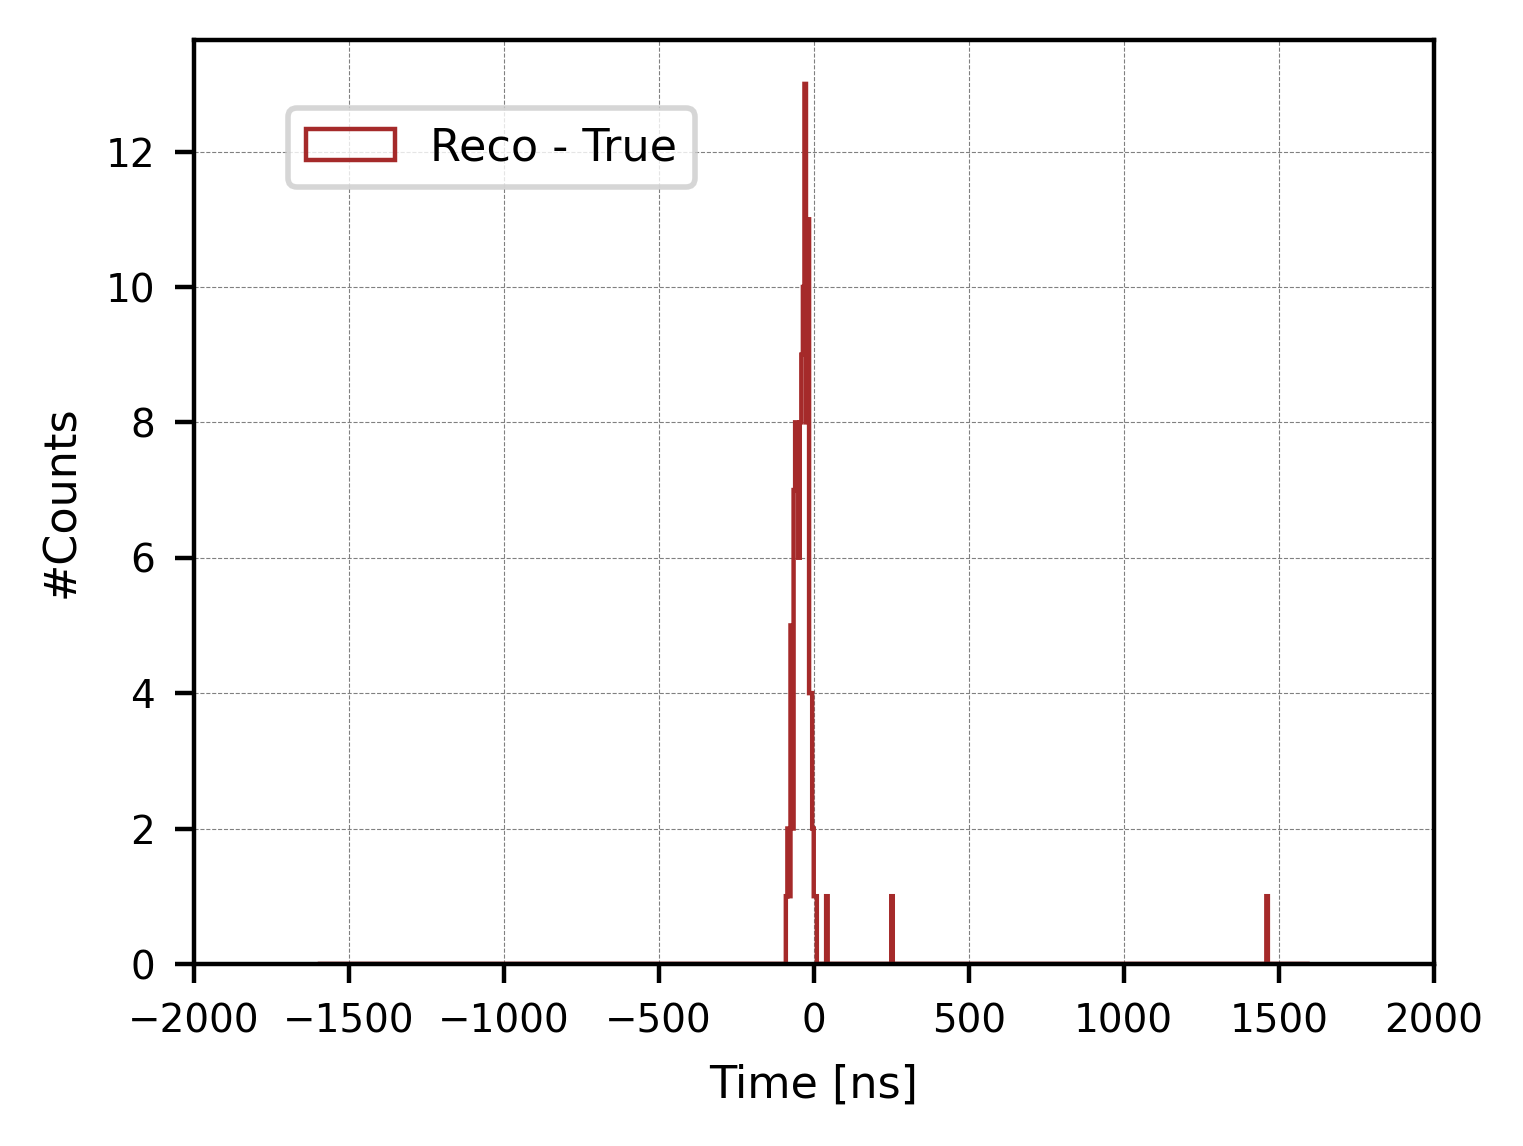

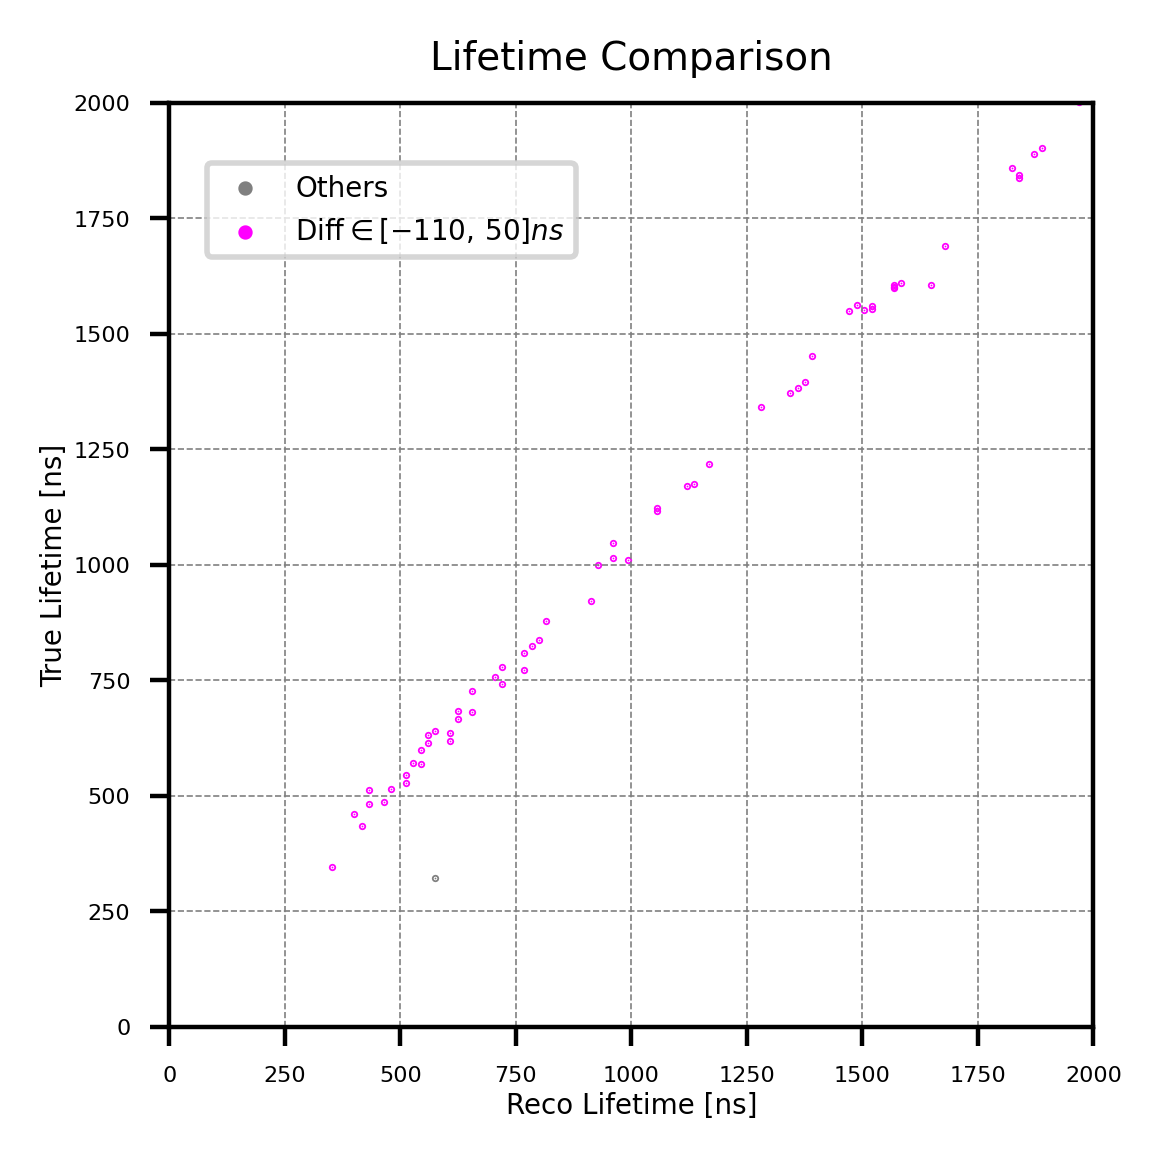

In [21]:
#The final dataset: events_diff500_purify9

diffTime_diff500_purify9 = [ev.diff_lifetime for ev in events_diff500_purify9]
trueTime_diff500_purify9 = [ev.true_lifetime for ev in events_diff500_purify9]
recoTime_diff500_purify9 = [ev.reco_lifetime for ev in events_diff500_purify9]

#Group of diff<500
diffTime_diff0_purify9 = [ev.diff_lifetime for ev in events_diff0_purify9]
trueTime_diff0_purify9 = [ev.true_lifetime for ev in events_diff0_purify9]
recoTime_diff0_purify9 = [ev.reco_lifetime for ev in events_diff0_purify9]

events_total_purify9 = events_diff0_purify9 + events_diff500_purify9
diffTime_total_purify9 = diffTime_diff500_purify9 + diffTime_diff0_purify9

#------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 5
range_min = -1600
range_max = 1600
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(diffTime_total_purify9, bins=bins, range=(range_min, range_max),
         edgecolor='brown', histtype='step', linewidth=0.8,
         label='Reco - True')


plt.xlim(-2000, 2000)
#plt.ylim(0.1, 3000)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.24, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()







# ==========================================================
# TrueLife VS RecoLife
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot----------
plt.scatter(recoTime_diff500_purify9, trueTime_diff500_purify9, s=0.1, c='grey', alpha=1.0, label="Others")
plt.scatter(recoTime_diff0_purify9, trueTime_diff0_purify9, s=0.1, c='magenta', alpha=1.0, label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
#-----------------------

plt.axis('scaled')
plt.xlim(0, 2000)
plt.ylim(0, 2000)
plt.ylabel('True Lifetime [ns]', labelpad=1, fontsize=5)
plt.xlabel('Reco Lifetime [ns]', labelpad=1, fontsize=5)
plt.title('Lifetime Comparison', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.24, 0.95), fontsize=6, markerscale=5, ncol=1, prop={'size':5})
plt.show()





<br />

#### Single Event Inspection:

In [22]:
# "Signal"
for ev in events_diff0_purify9:
    if ev.diff_lifetime < -96:
        print(ev)

print("\n--------------------")
for i, ev in enumerate(events_diff0_purify9[:100]):
    print(f"Event {i}: {ev}")



# "Background"
print("\n\n=======================================")
for i, ev in enumerate(events_diff500_purify9[:100]):
    print(f"Event {i}: {ev}")




--------------------
Event 0: PdsEventNew(muon_time=128, michel_time=264, muon_intensity=38.9291, michel_intensity=6.00586, third_intensity=0.844339, posX=209.427, posY=110.73, posZ=368.988, energy=34.6878, lifetime=2.20628, pdg=-11, eventID=1043, trackID=6, date=20251053, michel_score=0.447757, michel_hits=20, reco_lifetime=2176, true_lifetime=2206.28, diff_lifetime=-30.2800000000002, michel_rise=0.4003906666666667, michel_drop=0.30625904761904765)
Event 1: PdsEventNew(muon_time=128, michel_time=158, muon_intensity=33.0054, michel_intensity=8.86676, third_intensity=2.47755, posX=201.412, posY=335.079, posZ=219.781, energy=44.4143, lifetime=0.514873, pdg=11, eventID=1085, trackID=1, date=20251053, michel_score=0.621095, michel_hits=4, reco_lifetime=480, true_lifetime=514.873, diff_lifetime=-34.87300000000005, michel_rise=0.5911173333333333, michel_drop=0.500915)
Event 2: PdsEventNew(muon_time=128, michel_time=169, muon_intensity=31.8826, michel_intensity=4.77867, third_intensity=0.622

<br />
<br />

#### Features of final dataset (after purification 9):


Decay points distribution: 


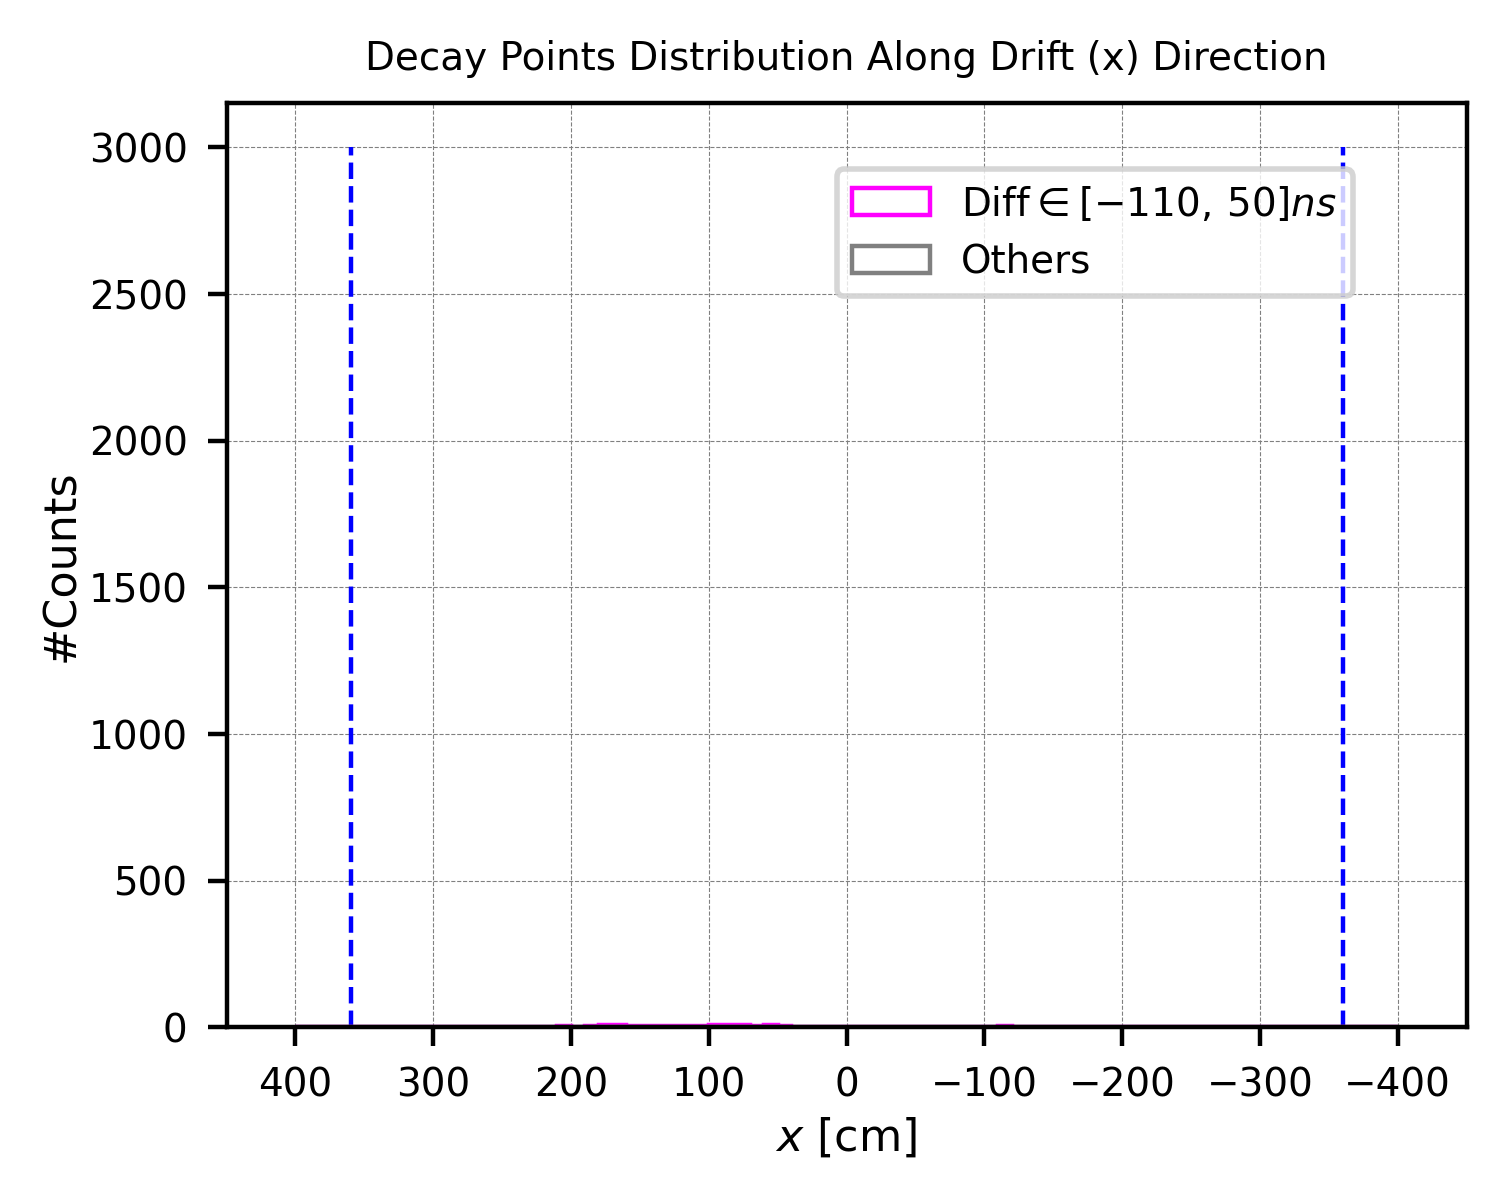

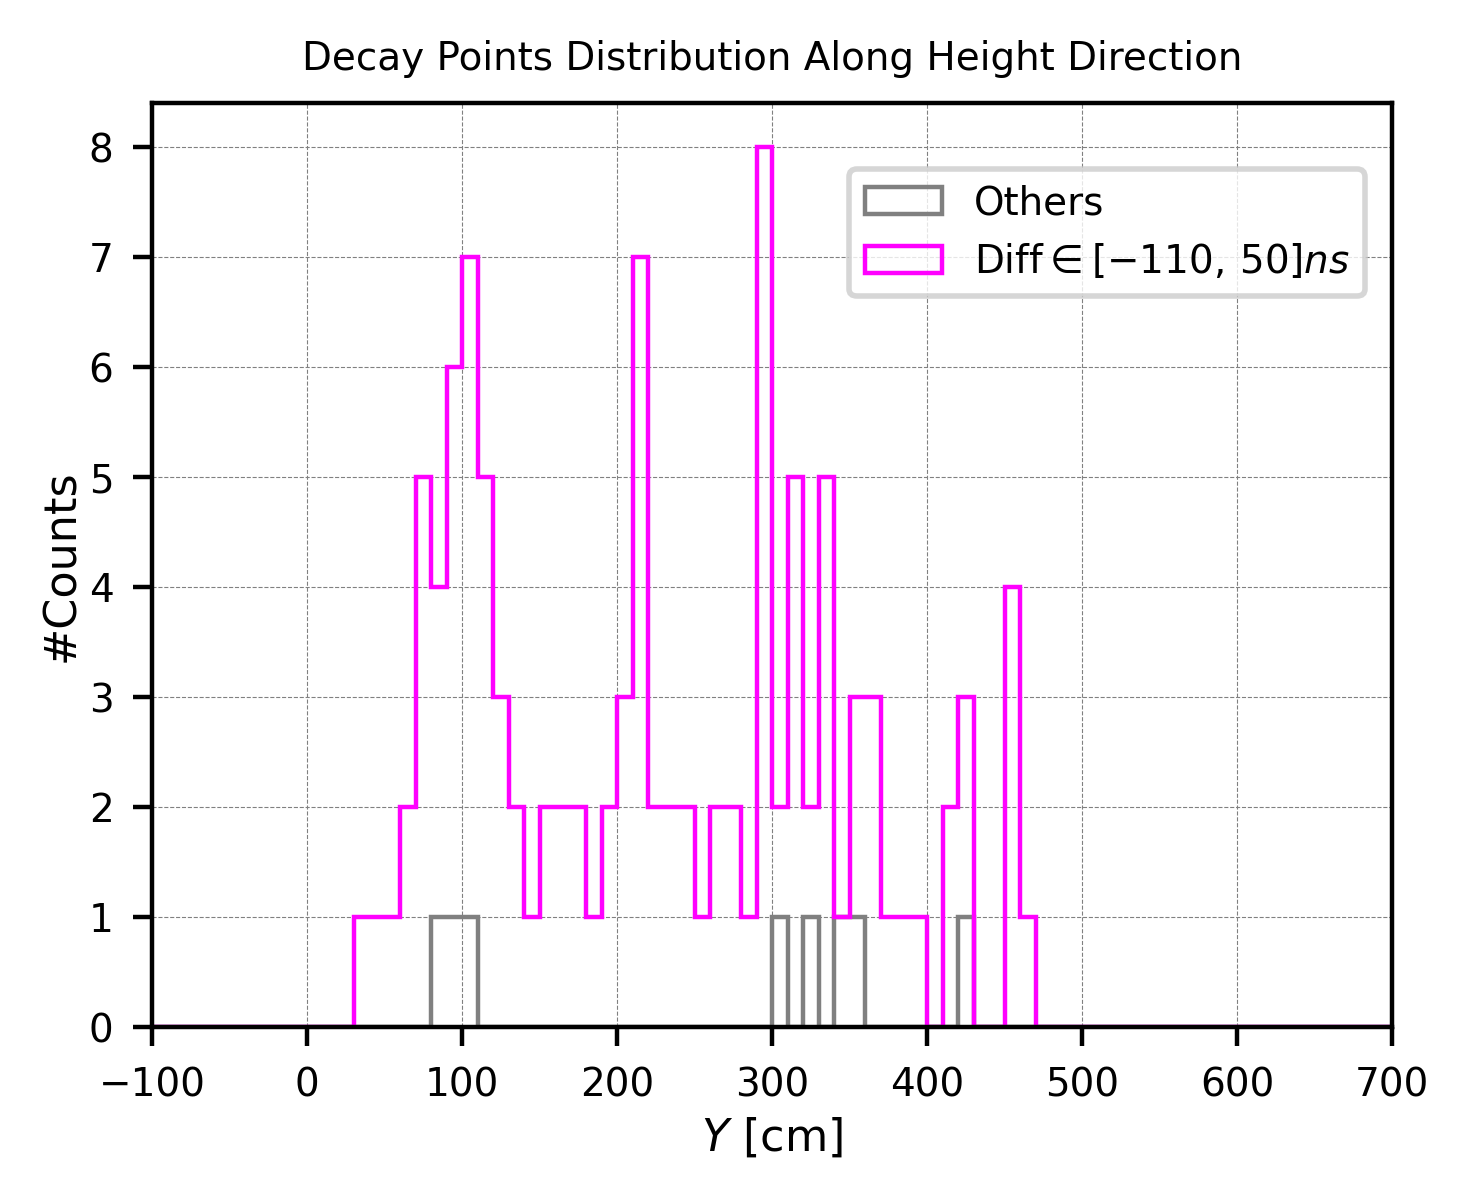

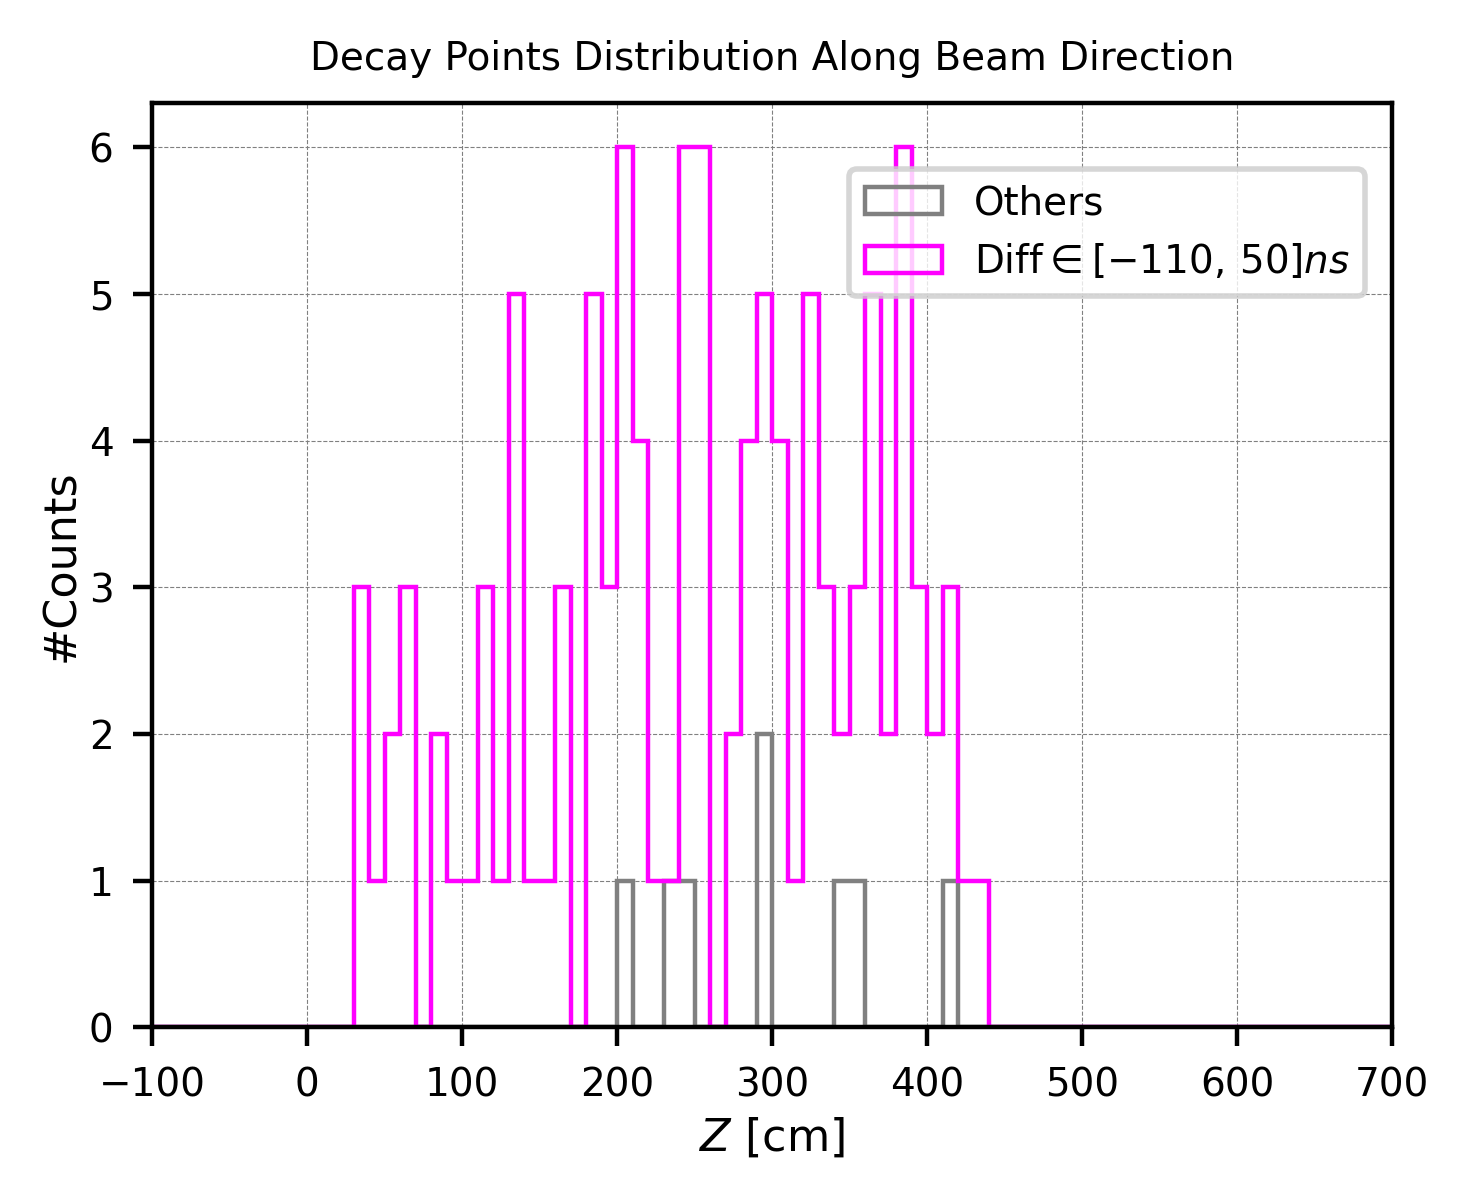

In [23]:

posX_diff500_purify9 = [ev.posX for ev in events_diff500_purify9]
posY_diff500_purify9 = [ev.posY for ev in events_diff500_purify9]
posZ_diff500_purify9 = [ev.posZ for ev in events_diff500_purify9]

posX_diff0_purify9 = [ev.posX for ev in events_diff0_purify9]
posY_diff0_purify9 = [ev.posY for ev in events_diff0_purify9]
posZ_diff0_purify9 = [ev.posZ for ev in events_diff0_purify9]



#Decay points distribution:==========================================
print("\nDecay points distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posX_diff0_purify9, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
          histtype='step', linewidth=0.8, label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.hist(posX_diff500_purify9, bins=bins, range=(range_min, range_max), edgecolor='grey', 
          histtype='step', linewidth=0.8, label="Others")
#--------------------------------

plt.xlim(-450, 450)
plt.xlabel(r'$x$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.9, 500)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift (x) Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  




# Plotting the histogram (Y distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -1000
range_max = 1000
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posY_diff500_purify9, bins=bins, range=(range_min, range_max), edgecolor='grey', 
          histtype='step', linewidth=0.8, label="Others")
plt.hist(posY_diff0_purify9, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
          histtype='step', linewidth=0.8, label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
#--------------------------------

plt.xlim(-100, 700)
plt.xlabel(r'$Y$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 300)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Height Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  




# Plotting the histogram (Z distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -1000
range_max = 1000
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posZ_diff500_purify9, bins=bins, range=(range_min, range_max), edgecolor='grey', 
          histtype='step', linewidth=0.8, label="Others")
plt.hist(posZ_diff0_purify9, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
          histtype='step', linewidth=0.8, label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
#--------------------------------

plt.xlim(-100, 700)
plt.xlabel(r'$Z$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 300)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Beam Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 











# Set the limits of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

# Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465


# ==========================================================
# Y–X plane plotting (Front View)
# ==========================================================
# plt.figure(figsize=(4,3), dpi=400)

# # Auxiliary line for field cage
# aux2 = [0, 610, 610, 0, 0]
# aux1 = [356, 356, -356, -356, 356]
# plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# # Scatter plot----------
# # plt.scatter(posX_true500, posY_true500, s=1, c='red', alpha=1.0, label="500<True")
# # plt.scatter(posX_true0, posY_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# # plt.scatter(posX_false, posY_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

# plt.scatter(posX_diff500, posY_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
# plt.scatter(posX_diff0, posY_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
# #-----------------------

# plt.axis('scaled')
# plt.xlim(xmin, xmax)
# plt.ylim(-50, 660)
# plt.gca().invert_xaxis()  # Flip x-axis
# plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
# plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
# plt.title('Front View', fontsize=7)
# plt.tick_params(labelsize=4)
# plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
# plt.legend(fontsize=5, loc="upper right")
# plt.show()


# ==========================================================
# Z–X plane plotting (Top View)
# ==========================================================
# plt.figure(figsize=(4,3), dpi=400)

# # Auxiliary line
# aux1 = [0, 465, 465, 0, 0]
# aux2 = [356, 356, -356, -356, 356]
# plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# # Scatter plot----------
# # plt.scatter(posZ_true500, posX_true500, s=1, c='red', alpha=1.0, label="500<True")
# # plt.scatter(posZ_true0, posX_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# # plt.scatter(posZ_false, posX_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

# plt.scatter(posZ_diff500, posX_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
# plt.scatter(posZ_diff0, posX_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
# #-----------------------

# plt.axis('scaled')
# plt.ylim(xmin, xmax)
# plt.xlim(-50, 515)
# plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
# plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
# plt.title('Top View', fontsize=7)
# plt.tick_params(labelsize=4)
# plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
# plt.legend(fontsize=5, loc="upper right")
# plt.show()




# ==========================================================
# Y–Z plane plotting (Side View)
# ==========================================================
# plt.figure(figsize=(4,3), dpi=400)

# # Auxiliary line
# aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY]
# aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
# plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# # Scatter plot----------
# # plt.scatter(posZ_true500, posY_true500, s=1, c='red', alpha=1.0, label="500<True")
# # plt.scatter(posZ_true0, posY_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# # plt.scatter(posZ_false, posY_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

# plt.scatter(posZ_diff500, posY_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
# plt.scatter(posZ_diff0, posY_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
# #-----------------------

# plt.axis('scaled')
# plt.xlim(-50, 515)
# plt.ylim(-50, 660)
# plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
# plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
# plt.title('Side View', fontsize=7)
# plt.tick_params(labelsize=4)
# plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
# plt.legend(fontsize=5, loc="upper right")
# plt.show()



Energy Distribution: 


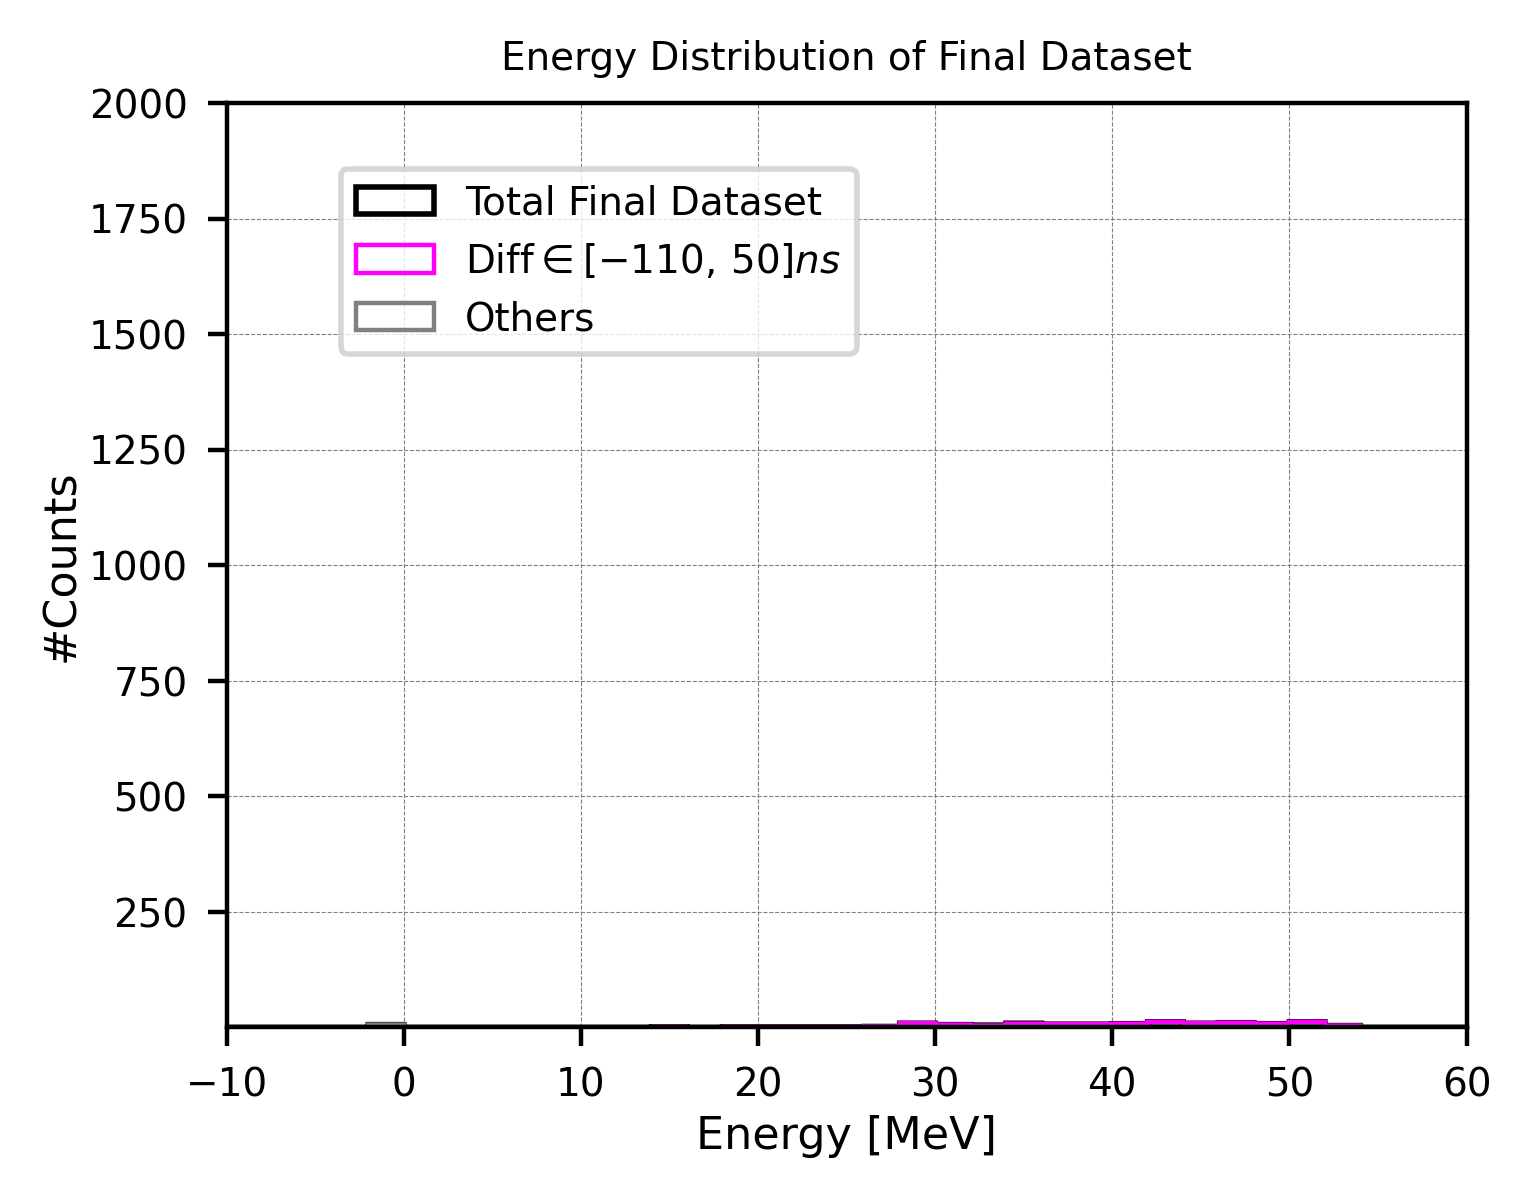

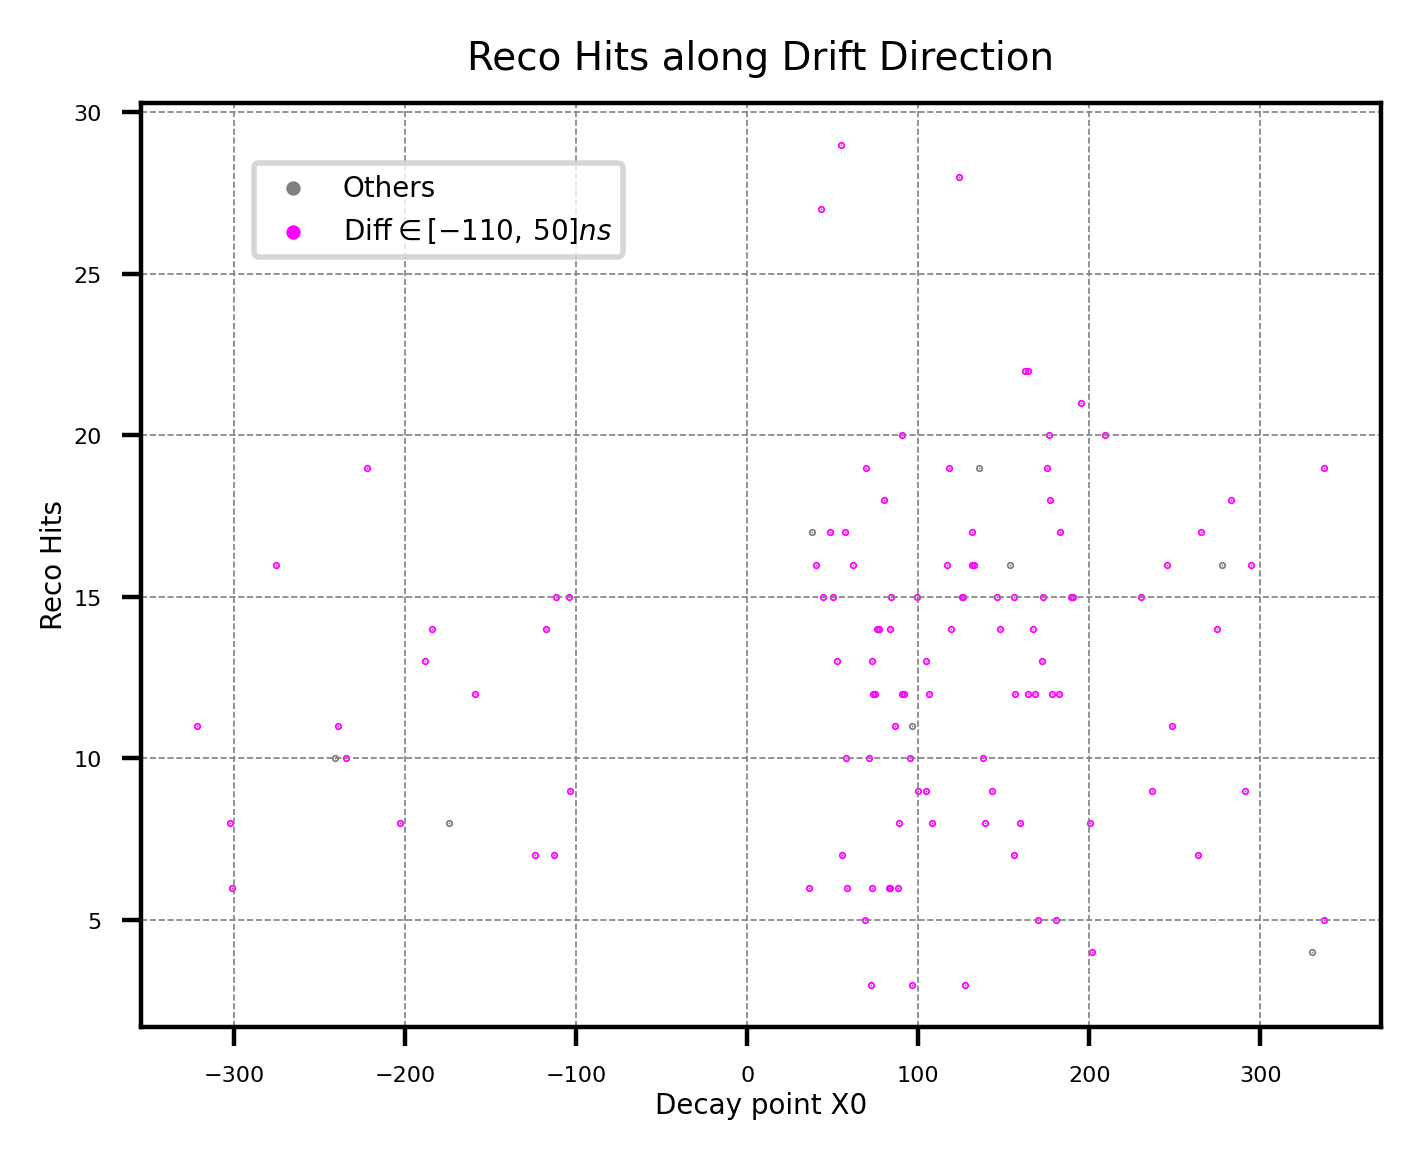


Michel Score Distribution: 


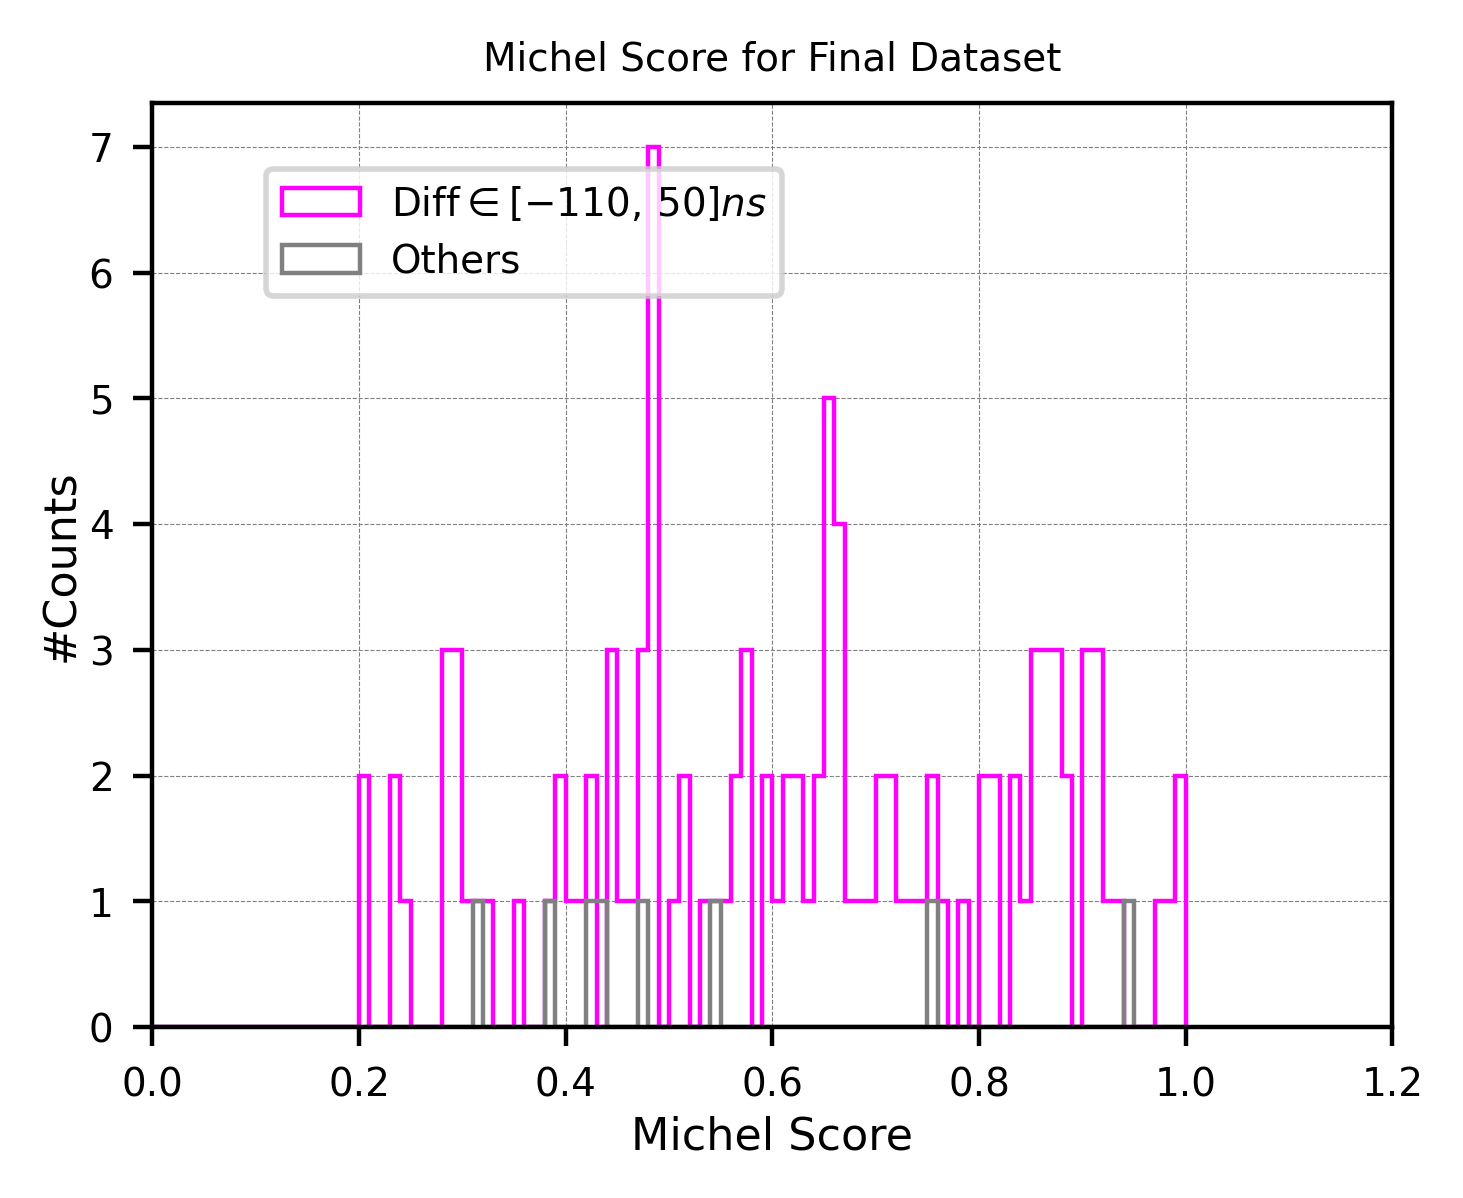


Michel Hits Distribution: 


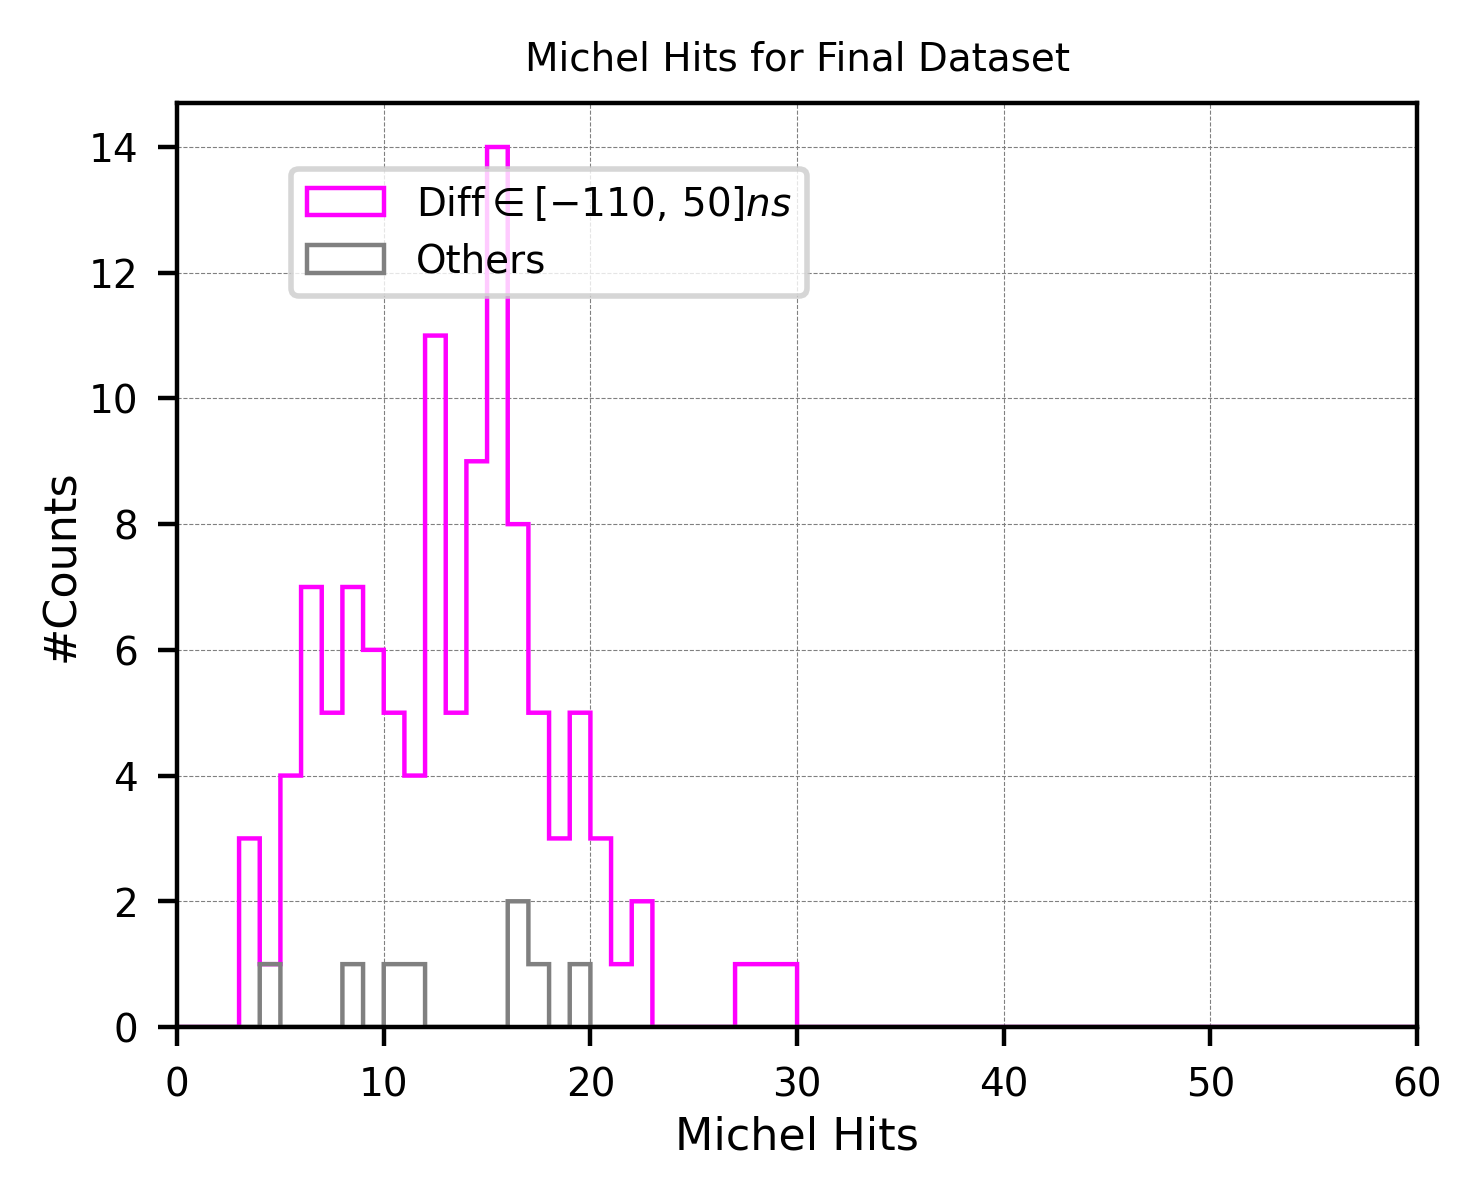

In [24]:
energy_diff500_purify9 = [ev.energy for ev in events_diff500_purify9]
energy_diff0_purify9 = [ev.energy for ev in events_diff0_purify9]
energy_total_purify9 = [ev.energy for ev in events_total_purify9]

hits_diff500_purify9 = [ev.michel_hits for ev in events_diff500_purify9]
hits_diff0_purify9 = [ev.michel_hits for ev in events_diff0_purify9]

score_diff500_purify9 = [ev.michel_score for ev in events_diff500_purify9]
score_diff0_purify9 = [ev.michel_score for ev in events_diff0_purify9]




#Decay points distribution:==========================================
print("\nEnergy Distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)


#Define the range and bin width
bin_width = 2
range_min =-1000
range_max = 1000
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(energy_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='black', 
          histtype='step', linewidth=1.0, label="Total Final Dataset")
plt.hist(energy_diff0_purify9, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
          histtype='step', linewidth=0.8, label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.hist(energy_diff500_purify9, bins=bins, range=(range_min, range_max), edgecolor='grey', 
          histtype='step', linewidth=0.8, label="Others")

#--------------------------------


plt.xlim(-10, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 2000)
#plt.yscale('log')
plt.title('Energy Distribution of Final Dataset', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 










# ==========================================================
# reco hits VS posX
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot----------
plt.scatter(posX_diff500_purify9, hits_diff500_purify9, s=0.1, c='grey', alpha=1.0, label="Others")
plt.scatter(posX_diff0_purify9, hits_diff0_purify9, s=0.1, c='magenta', alpha=1.0, label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
#-----------------------

#plt.axis('scaled')
#plt.xlim(0, 2000)
#plt.ylim(0, 2000)
plt.ylabel('Reco Hits', labelpad=1, fontsize=5)
plt.xlabel('Decay point X0', labelpad=1, fontsize=5)
plt.title('Reco Hits along Drift Direction', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.24, 0.95), fontsize=6, markerscale=5, ncol=1, prop={'size':5})
plt.show()








#Michel Score distribution:==========================================
print("\nMichel Score Distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)


#Define the range and bin width
bin_width = 0.01
range_min =-1
range_max = 1
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(score_diff0_purify9, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
          histtype='step', linewidth=0.8, label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.hist(score_diff500_purify9, bins=bins, range=(range_min, range_max), edgecolor='grey', 
          histtype='step', linewidth=0.8, label="Others")

#--------------------------------

plt.xlim(0, 1.2)
plt.xlabel('Michel Score', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 200)
#plt.yscale('log')
plt.title('Michel Score for Final Dataset', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 







#Michel Hits distribution:==========================================
print("\nMichel Hits Distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)


#Define the range and bin width
bin_width = 1
range_min =0
range_max = 600
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(hits_diff0_purify9, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
          histtype='step', linewidth=0.8, label=r"$\mathrm{Diff} \in [-110,\,50]ns$")
plt.hist(hits_diff500_purify9, bins=bins, range=(range_min, range_max), edgecolor='grey', 
          histtype='step', linewidth=0.8, label="Others")

#--------------------------------

plt.xlim(0, 60)
plt.xlabel('Michel Hits', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 200)
#plt.yscale('log')
plt.title('Michel Hits for Final Dataset', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 





<br />
<br />
<br />

#### Lifetime Distribution of Final Dataset (purification 9):

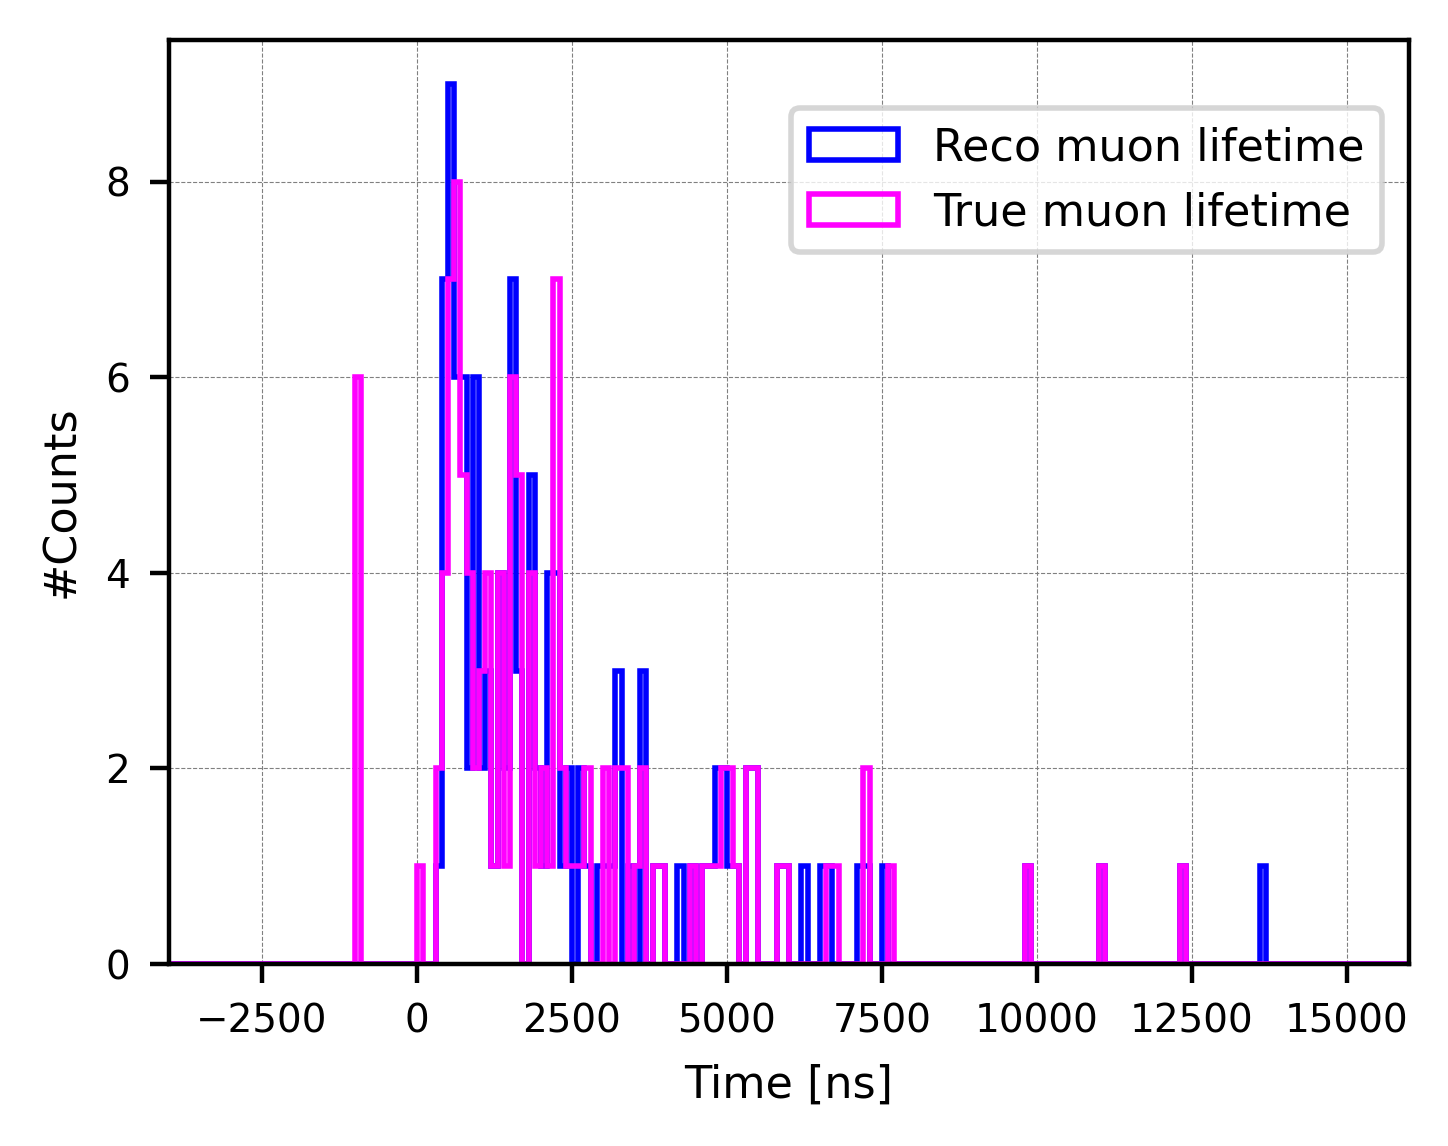



For each event, +40ns for reco time


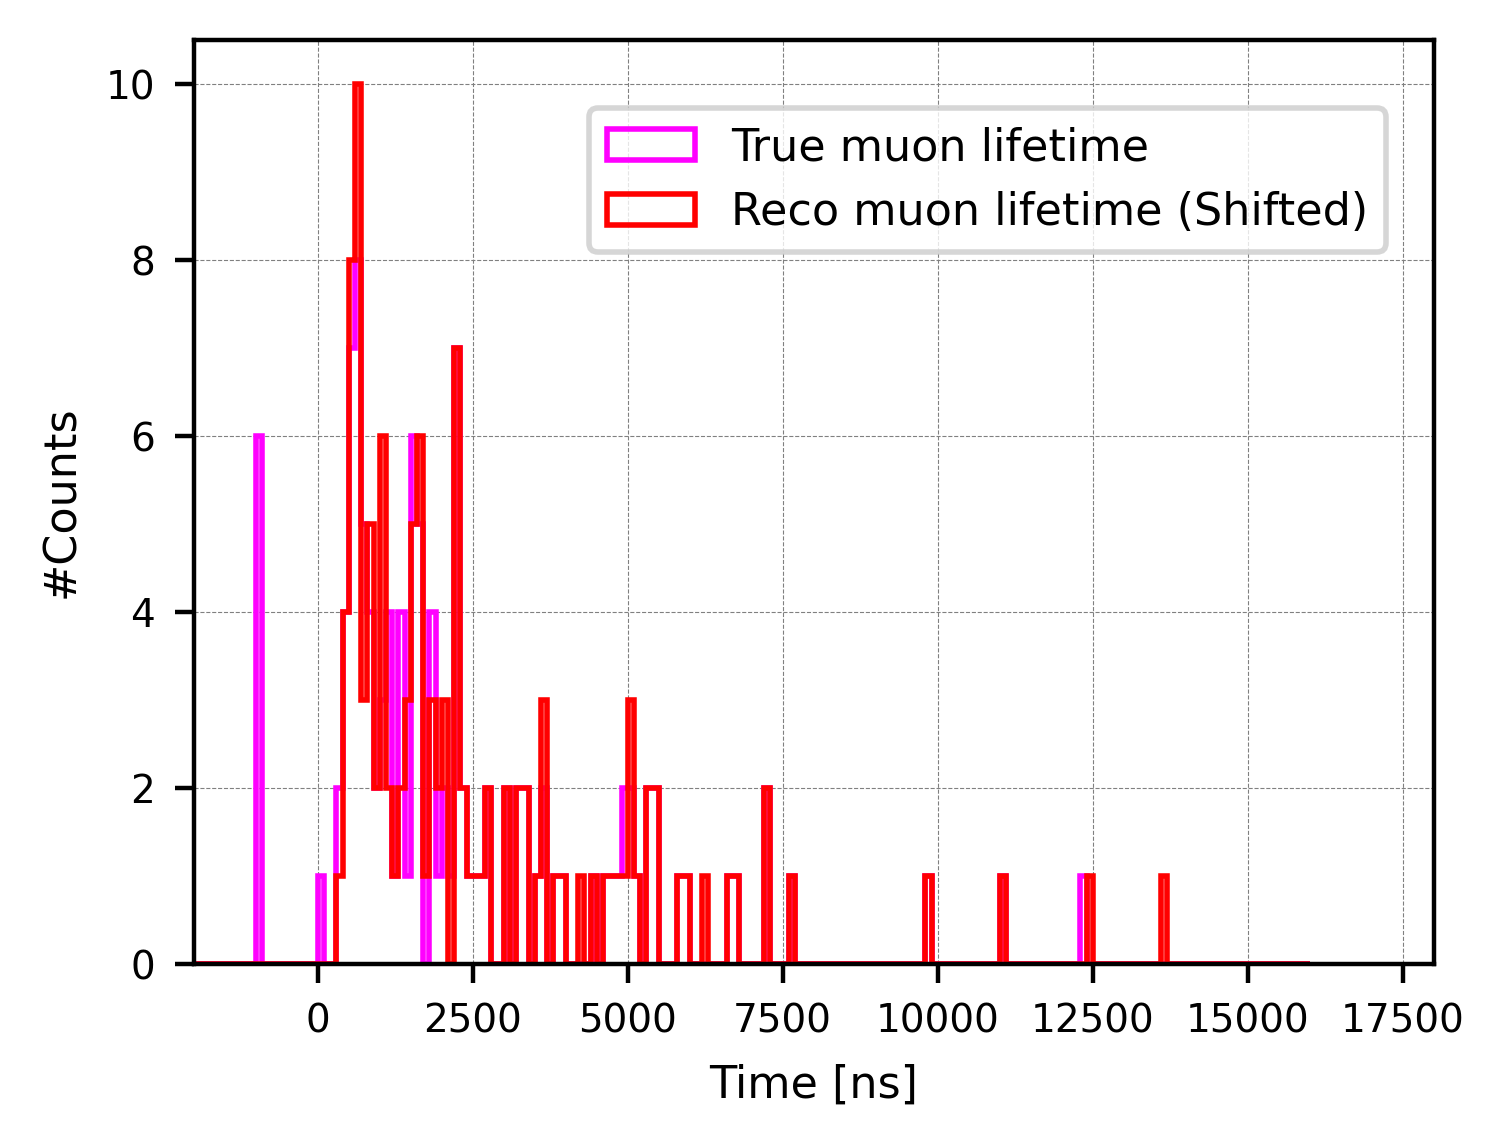

In [25]:

recoT_total_purify9 = [ev.reco_lifetime for ev in events_total_purify9]
trueT_total_purify9 = [ev.true_lifetime for ev in events_total_purify9]



# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 100
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(recoT_total_purify9, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')

plt.hist(trueT_total_purify9, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=1.0,
         label='True muon lifetime')

plt.xlim(-4000, 16000)
#plt.ylim(0, 500)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()




#Shift +40ns=========================================
print("\n\n===================================")
print("For each event, +40ns for reco time")
recoT_total_purify9_shift40 = [x + 40 for x in recoT_total_purify9]


bin_width = 100
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.figure(figsize=(4, 3), dpi=400)
#plt.hist(recoT_total_purify9, bins=bins, range=(range_min, range_max),
#         edgecolor='blue', histtype='step', linewidth=1.0,
#         label='Reco muon lifetime')

plt.hist(trueT_total_purify9, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=1.0,
         label='True muon lifetime')

plt.hist(recoT_total_purify9_shift40, bins=bins, range=(range_min, range_max),
         edgecolor='red', histtype='step', linewidth=1.0,
         label='Reco muon lifetime (Shifted)')

plt.xlim(-2000, 18000)
#plt.ylim(0.9, 1000)
#plt.yscale("log")
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.64, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()



